# **Libraries**

In [1]:
%run ../../../setup_workspace.py # ../ means level up 
from scipy.signal import find_peaks
import matplotlib.ticker as ticker


# **Functions**

In [24]:
def K(q, I, z):
    return np.trapezoid(I[:, None] * np.cos(q[:, None] * z[None, :]), q, axis=0)

def IDF(z, K):
    d1 = np.gradient(K, z)
    return np.gradient(d1, z)

def power(x, k, b):
    return b * x ** k

def porod(x, A):
    return A * x ** -4

def smeared_porod(x, A, sigma):
    return A * x ** -4 * np.exp(- x ** 2 * sigma ** 2)

def smeared_porod_backwards(x, sigma):
    return x ** -4 * np.exp(x ** 2 * sigma ** 2)

def Lorenz(x, y, p = 2):
    return x, y * x ** p

def find_porod_A(x, y):
    const = np.mean(y[-10:])
    best_A = 0.5
    y_sub = y - best_A * const

    best_p, best_cov = curve_fit(porod, x, y_sub, bounds=(0, np.inf))
    best_cov_val = np.diag(best_cov)[0]
    
    for A in np.arange(0.5, 1.2, 0.01):
        y_sub = y - A * const
        try:
            p, cov = curve_fit(porod, x, y_sub, bounds=(0, np.inf))
            current_cov = np.diag(cov)[0]
            
            if current_cov < best_cov_val:
                best_cov_val = current_cov
                best_A = A
                best_p = p
        except:
            continue
    
    return best_A * const, best_p

def linear(x, k, b):
    return k * x + b

In [3]:
def analyze_saxs_data(file_path, limits=None, factor=2, porod_const=1., sigma=0.0):
    """
    Analyze SAXS data including Porod fitting, Lorenz correction, and correlation function analysis.
    
    Parameters:
    -----------
    file_path : str
        Path to the SAXS data file
    limits : list, optional
        List of q limits for different regions [low_q, porod_start, porod_end, high_q]
        Default: [0.1, 0.95, 1.6, 2.2]
    factor : float, optional
        Factor for Lorenz correction (default: 2)
    porod_const : float, optional
        Porod constant multiplier (default: 1.2)
    sigma : float, optional
        Smoothing parameter for smeared Porod (default: 0.0)
    
    Returns:
    --------
    dict : Dictionary containing all results and figure handles
    """
    
    # Default limits if not provided
    if limits is None:
        limits = [0.1, 0.95, 1.6, 2.2]
    
    # Create figure and axes
    fig, axes = plt.subplots(2, 2, figsize=(10, 10))
    ax1 = axes[0][0]
    ax2 = axes[0][1]
    ax3 = axes[1][0]
    ax4 = axes[1][1]
    
    # Load data
    df = pd.read_csv(file_path, skiprows=2, names=['q', 'I', 'err'], sep='\t')
    q, I = np.array(df['q']), np.array(df['I'])
    
    # Add vertical lines at limits
    for lim in limits:
        ax1.axvline(x=lim, color='black', linestyle='--')
    
    # Plot original data
    ax1.loglog(q, I, color='black', alpha=0.3, label='Original data')
    
    # Porod fitting
    mask_for_porod = (q > limits[-2]) & (q < limits[-1])
    const, P = find_porod_A(q[mask_for_porod], I[mask_for_porod])
    I_sub = I - const
    
    ax1.loglog(q, I_sub, color='r', alpha=0.3, label='Subtracted data')
    
    # Generate Porod fit
    x_porod = np.linspace(limits[1], 40, 2000)
    Ampl = I_sub[q < limits[1]][-1] * q[q < limits[1]][-1] ** 4
    y_porod = porod_const * smeared_porod(x_porod, Ampl, sigma)
    ax1.plot(x_porod[x_porod < 3], y_porod[x_porod < 3], color='black', label='Porod fit')
    
    # Combine main data with Porod fit
    mask_main = (q > limits[0]) & (q < limits[1])
    res_q = np.concatenate([q[mask_main], x_porod])
    res_I = np.concatenate([I_sub[mask_main], y_porod])
    
    ax1.plot(res_q[res_q < 3], res_I[res_q < 3] / 2, color='black', alpha=0.7)
    ax1.set_xlabel('q (nm$^{-1}$)')
    ax1.set_ylabel('I (a.u.)')
    ax1.legend()
    
    # Lorenz correction
    X_lorenz, Y_lorenz = Lorenz(res_q, res_I, factor)
    ax2.plot(X_lorenz, Y_lorenz / max(Y_lorenz), color='black')
    ax2.set_xlim(-0.1, 3)
    ax2.set_xlabel('q (nm$^{-1}$)')
    ax2.set_ylabel('I (a.u.)')
    
    # Correlation function
    dz = 2 * np.pi / max(X_lorenz)
    z = np.linspace(dz, 50, int(50 / dz))
    Corr = K(X_lorenz, Y_lorenz, z)
    Corr /= max(Corr)
    
    # IDF calculation
    idf = K(X_lorenz, Y_lorenz * X_lorenz ** 2, z)
    idf /= 2 * max(-idf)
    
    # Plot correlation and IDF
    ax3.plot(z, Corr, color='black', label='Correlation')
    ax3.plot(z, -idf, color='r', alpha=0.4, label='IDF')
    ax3.set_xlim(-1, 50)
    ax3.set_ylim(-0.5, 1)
    ax3.axvline(x=0, color='grey')
    ax3.plot(z, z * 0, color='black', alpha=0.3)
    ax3.set_xlabel('q (nm$^{-1}$)')
    ax3.set_ylabel('K(z) & IDF(z)')
    ax3.legend()
    
    # Detailed correlation analysis
    ax4.plot(z, Corr, color='black')
    ax4.plot(z, z * 0, color='black', alpha=0.3)
    ax4.set_xlim(-1, 30)
    ax4.set_ylim(-0.5, 1.1)
    
    # Find minima and maxima in specified range
    mask_corr = (z > 4) & (z < 25)
    point_1 = min(Corr[mask_corr])  # minimum in the range
    point_2 = max(Corr[mask_corr])  # maximum in the range
    
    # Mark minimum point
    ax4.scatter(z[Corr == point_1], point_1, zorder=100, color='b', label='Min point')
    ax4.plot(z, point_1 + np.zeros(len(z)), color='grey', alpha=0.5)
    
    # Linear fit for small z
    mask_linear = (z < 2) & (z > 1)
    def linear(x, a, b):
        return a * x + b
    
    popt, cov = curve_fit(linear, z[mask_linear], Corr[mask_linear])
    ax4.plot(z, linear(z, *popt), color='b', alpha=0.4, zorder=1, linestyle='--', label='Linear fit')
    
    # Calculate amorphous domain size
    d_amorph = (point_1 - popt[1]) / popt[0]
    ax4.scatter(d_amorph, point_1, color='r', label='d_amorph', zorder=100)
    
    # Mark maximum point
    ax4.scatter(z[Corr == point_2], point_2, zorder=100, color='r', label='Max point')
    lp = z[Corr == point_2][0]
    
    ax4.set_xlabel('z (nm)')
    ax4.set_ylabel('K(z)')
    ax4.legend()
    
    # Calculate results
    d_cr = lp - d_amorph
    ratio = d_cr / lp
    
    # Print results
    print(f'D_amorphous = {d_amorph:.3f}')
    print(f'D_crystalline = {d_cr:.3f}')
    print(f'Long period = {lp:.3f}')
    print(f'Crystalline fraction = {ratio:.3f}')
    
    # Return results
    results = {
        'fig': fig,
        'axes': axes,
        'd_amorphous': d_amorph,
        'd_crystalline': d_cr,
        'long_period': lp,
        'crystalline_fraction': ratio,
        'q': q,
        'I': I,
        'I_subtracted': I_sub,
        'correlation': Corr,
        'idf': idf,
        'z': z,
        'porod_constants': (const, P, Ampl)
    }
    
    return results

In [22]:
def analyze_saxs_data_q_I(q,I , limits=None, factor=2, porod_const=1.2, sigma=0.0, lin1=1, lin2=2, plot=True):

    
    # Default limits if not provided
    if limits is None:
        limits = [0.1, 0.95, 1.6, 2.2]

    if plot==True:
    # Create figure and axes
        fig, axes = plt.subplots(2, 2, figsize=(10, 10))
        ax1 = axes[0][0]
        ax2 = axes[0][1]
        ax3 = axes[1][0]
        ax4 = axes[1][1]
    
    # Load data
    
    # Add vertical lines at limits
    if plot==True:
        
        for lim in limits:
            ax1.axvline(x=lim, color='black', linestyle='--')
        
    # Plot original data
        ax1.loglog(q, I, color='black', alpha=0.3, label='Original data')
    
    # Porod fitting
    mask_for_porod = (q > limits[-2]) & (q < limits[-1])
    const, P = find_porod_A(q[mask_for_porod], I[mask_for_porod])
    I_sub = I - const
    if plot==True:
    
        ax1.loglog(q, I_sub, color='r', alpha=0.3, label='Subtracted data')
    
    # Generate Porod fit
    x_porod = np.linspace(limits[1], 40, 2000)
    Ampl = I_sub[q < limits[1]][-1] * q[q < limits[1]][-1] ** 4
    y_porod = porod_const * smeared_porod(x_porod, Ampl, sigma)
    if plot==True:
    
        ax1.plot(x_porod[x_porod < 3], y_porod[x_porod < 3], color='blue', label='Porod fit')
    
    # Combine main data with Porod fit
    mask_main = (q > limits[0]) & (q < limits[1])
    res_q = np.concatenate([q[mask_main], x_porod])
    res_I = np.concatenate([I_sub[mask_main], y_porod])
    if plot==True:
    
        ax1.plot(res_q[res_q < 3], res_I[res_q < 3] / 10, color='black', alpha=0.5)
        ax1.set_xlabel('q (nm$^{-1}$)')
        ax1.set_ylabel('I (a.u.)')
        ax1.legend()
    
    # Lorenz correction
    X_lorenz, Y_lorenz = Lorenz(res_q, res_I, factor)
    if plot==True:
    
        ax2.plot(X_lorenz, Y_lorenz / max(Y_lorenz), color='black')
        ax2.set_xlim(-0.1, 3)
        ax2.set_xlabel('q (nm$^{-1}$)')
        ax2.set_ylabel('I (a.u.)')
    
    # Correlation function
    dz = 2 * np.pi / max(X_lorenz)
    z = np.linspace(dz, 50, int(50 / dz))
    Corr = K(X_lorenz, Y_lorenz, z)
    Corr /= max(Corr)
    
    # IDF calculation
    idf = K(X_lorenz, Y_lorenz * X_lorenz ** 2, z)
    idf /= 2 * max(-idf)
    
    # Plot correlation and IDF
    if plot==True:
    
        ax3.plot(z, Corr, color='black', label='Correlation')
        ax3.plot(z, -idf, color='r', alpha=0.4, label='IDF')
        ax3.set_xlim(-1, 50)
        ax3.set_ylim(-0.5, 1)
        ax3.axvline(x=0, color='grey')
        ax3.plot(z, z * 0, color='black', alpha=0.3)
        ax3.set_xlabel('q (nm$^{-1}$)')
        ax3.set_ylabel('K(z) & IDF(z)')
        ax3.legend()
        
    # Detailed correlation analysis
        ax4.plot(z, Corr, color='black')
        ax4.plot(z, z * 0, color='black', alpha=0.3)
        ax4.set_xlim(-1, 30)
        ax4.set_ylim(-0.5, 1.1)
        
    # Find minima and maxima in specified range
    mask_corr = (z > 4) & (z < 25)
    point_1 = min(Corr[mask_corr])  # minimum in the range
    point_2 = max(Corr[(z>10)&(z<25)])  # maximum in the range

    if plot==True:
    
        ax4.set_ylim(1.5 * point_1, 1.1)
    
    
    # Mark minimum point
        ax4.scatter(z[Corr == point_1], point_1, zorder=100, color='b', label='Min point')
        ax4.plot(z, point_1 + np.zeros(len(z)), color='grey', alpha=0.5)
    
    # Linear fit for small z
    mask_linear = (z < lin2) & (z > lin1)
    def linear(x, a, b):
        return a * x + b
    
    popt, cov = curve_fit(linear, z[mask_linear], Corr[mask_linear])
    if plot==True:
    
        ax4.plot(z, linear(z, *popt), color='b', alpha=0.8, zorder=300, linestyle='--', label='Linear fit')
    
    # Calculate amorphous domain size
    d_amorph = (point_1 - popt[1]) / popt[0]
    if plot==True:
    
        ax4.scatter(d_amorph, point_1, color='r', label='d_amorph', zorder=100)
    
    # Mark maximum point
        ax4.scatter(z[Corr == point_2], point_2, zorder=100, color='r', label='Max point')
    lp = z[Corr == point_2][0]
    if plot==True:
    
        ax4.set_xlabel('z (nm)')
        ax4.set_ylabel('K(z)')
        ax4.legend()
    
    # Calculate results
    d_cr = lp - d_amorph
    ratio = d_cr / lp
    
    # Print results
    print(f'D_amorphous = {d_amorph:.3f}')
    print(f'D_crystalline = {d_cr:.3f}')
    print(f'Long period = {lp:.3f}')
    print(f'Crystalline fraction = {ratio:.3f}')
    
    # Return results
    if plot==True:
    
        results = {
            'fig': fig,
            'axes': axes,
            'd_amorphous': d_amorph,
            'd_crystalline': d_cr,
            'long_period': lp,
            'crystalline_fraction': ratio,
            'q': q,
            'I': I,
            'I_subtracted': I_sub,
            'correlation': Corr,
            'idf': idf,
            'z': z,
            'porod_constants': (const, P, Ampl)
        }
    else:
           results = {
            'd_amorphous': d_amorph,
            'd_crystalline': d_cr,
            'long_period': lp,
            'crystalline_fraction': ratio,
            'q': q,
            'I': I,
            'I_subtracted': I_sub,
            'correlation': Corr,
            'idf': idf,
            'z': z,
            'porod_constants': (const, P, Ampl)
        }
    return results

# **C390**

## Static

### plot

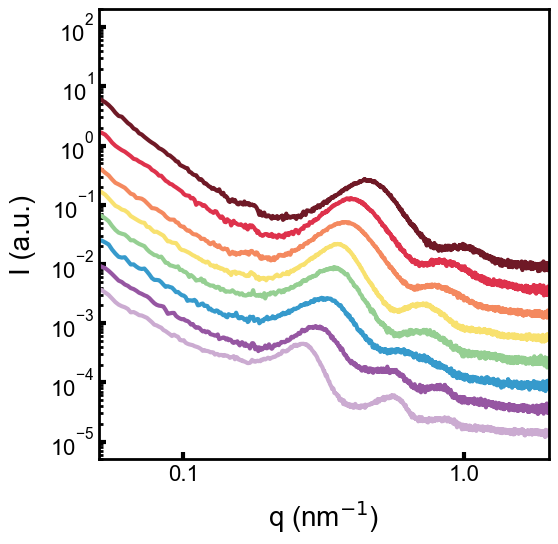

In [5]:
# ===================== СТИЛЬ ДЛЯ ПУБЛИКАЦИИ =====================
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 2
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['ytick.major.width'] = 2
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['ytick.major.size'] = 6
# =================================================================

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.set_position([0.15, 0.15, 0.75, 0.75])

scale = 2.5
linewidth = 3

path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00294_00_00001_av.dat"
df = pd.read_csv(path, skiprows=2, names=['q', 'I', 'err'], sep='\t')
q, I = np.array(df['q']), np.array(df['I'])
ax.plot(q, I * scale ** 3, label='after quenching', linewidth=linewidth, color='#6f1926')

path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00290_00_00001_av.dat"
df = pd.read_csv(path, skiprows=2, names=['q', 'I', 'err'], sep='\t')
q, I = np.array(df['q']), np.array(df['I'])
ax.plot(q, I * scale ** 2, label='1000 K/s', linewidth=linewidth, color='#de324c')

path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00299_00_00001_av.dat"
df = pd.read_csv(path, skiprows=2, names=['q', 'I', 'err'], sep='\t')
q, I = np.array(df['q']), np.array(df['I'])
ax.plot(q, I * scale ** 1, label='100 K/s', linewidth=linewidth, color='#f4895f')

path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00302_00_00001_av.dat"
df = pd.read_csv(path, skiprows=2, names=['q', 'I', 'err'], sep='\t')
q, I = np.array(df['q']), np.array(df['I'])
ax.plot(q, I * scale ** 0, label='10 K/s', linewidth=linewidth, color='#f8e16f')

path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00305_00_00001_av.dat"
df = pd.read_csv(path, skiprows=2, names=['q', 'I', 'err'], sep='\t')
q, I = np.array(df['q']), np.array(df['I'])
ax.plot(q, I * scale ** -1, label='5 K/s', linewidth=linewidth, color='#95cf92')

path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00301_00_00001_av.dat"
df = pd.read_csv(path, skiprows=2, names=['q', 'I', 'err'], sep='\t')
q, I = np.array(df['q']), np.array(df['I'])
ax.plot(q, I * scale ** -2, label='1 K/s', linewidth=linewidth, color='#369acc')

path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00291_00_00001_av.dat"
df = pd.read_csv(path, skiprows=2, names=['q', 'I', 'err'], sep='\t')
q, I = np.array(df['q']), np.array(df['I'])
ax.plot(q, I * scale ** -3, label='0.333 K/s', linewidth=linewidth, color='#9656a2')

path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00296_00_00001_av.dat"
df = pd.read_csv(path, skiprows=2, names=['q', 'I', 'err'], sep='\t')
q, I = np.array(df['q']), np.array(df['I'])
ax.plot(q, I * scale ** -4, label='0.017 K/s', linewidth=linewidth, color='#cbabd1')

ax.set_xlim(0.05, 2)
ax.set_ylim(5e-6, 2e2)
ax.set_xscale('log')
ax.set_yscale('log')

ax.xaxis.set_major_locator(ticker.FixedLocator([0.1, 1]))
ax.xaxis.set_minor_locator(ticker.NullLocator())
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.xaxis.get_major_formatter().set_scientific(False)

ax.set_xlabel('q (nm$^{-1}$)', fontname='Arial', fontsize=20, labelpad=10)
ax.set_ylabel('I (a.u.)', fontname='Arial', fontsize=20, labelpad=10)

ax.tick_params(axis="both", which='major', direction="in", width=3, length=5, labelsize=16)
ax.tick_params(axis="both", which='minor', direction="in", width=2, length=3)


ax.set_position([0.15, 0.15, 0.75, 0.75])
plt.savefig(r'E:\C390\Figures\Fig1_a.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

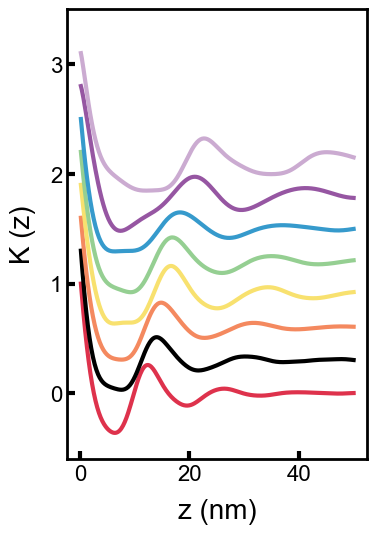

In [16]:
# ===================== СТИЛЬ ДЛЯ ПУБЛИКАЦИИ =====================
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 2
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['ytick.major.width'] = 2
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['ytick.major.size'] = 6
# =================================================================

fig, ax = plt.subplots(1, 1, figsize=(4, 6))
ax.set_position([0.15, 0.15, 0.75, 0.75])

colors = ['#de324c', 'black', '#f4895f', '#f8e16f', '#95cf92', '#369acc', '#9656a2', '#cbabd1']

for i in range(8):
    z = corr_funcs[i]['z']
    K = corr_funcs[i]['K']
    plt.plot(z, K + i*.3, color=colors[i], linewidth=3)

ax.set_xlabel('z (nm)', fontname='Arial', fontsize=20, labelpad=10)
ax.set_ylabel('K (z)', fontname='Arial', fontsize=20, labelpad=10)

ax.tick_params(axis='both', which='major', labelsize=16, length=6, width=3)
ax.tick_params(axis='both', which='minor', length=3, width=2)

ax.set_ylim(-.6, 3.5)
ax.set_yticks([0, 1, 2, 3])
# Легенда
# ax.scatter([], [], color='black', s=s_Lp, marker='s', label='L$_p$')
# ax.scatter([], [], color='black', s=s_Lc, marker='o', label='L$_c$')
# ax.legend(fontsize=15, frameon=True, facecolor='white', edgecolor='white', framealpha=1.0, loc=1)

ax.set_position([0.15, 0.15, 0.75, 0.75])
plt.savefig(r'C:\Users\LabPCA\Desktop\Fig1_SI.png', dpi=300, bbox_inches='tight', transparent=True)

### Corr 

D_amorphous = 3.256
D_crystalline = 9.165
Long period = 12.421
Crystalline fraction = 0.738
D_amorphous = 2.974
D_crystalline = 11.019
Long period = 13.994
Crystalline fraction = 0.787
D_amorphous = 3.296
D_crystalline = 11.484
Long period = 14.780
Crystalline fraction = 0.777
D_amorphous = 3.404
D_crystalline = 13.262
Long period = 16.667
Crystalline fraction = 0.796
D_amorphous = 3.454
D_crystalline = 13.369
Long period = 16.824
Crystalline fraction = 0.795
D_amorphous = 3.143
D_crystalline = 15.096
Long period = 18.239
Crystalline fraction = 0.828
D_amorphous = 4.545
D_crystalline = 16.367
Long period = 20.912
Crystalline fraction = 0.783
D_amorphous = 4.027
D_crystalline = 18.615
Long period = 22.641
Crystalline fraction = 0.822


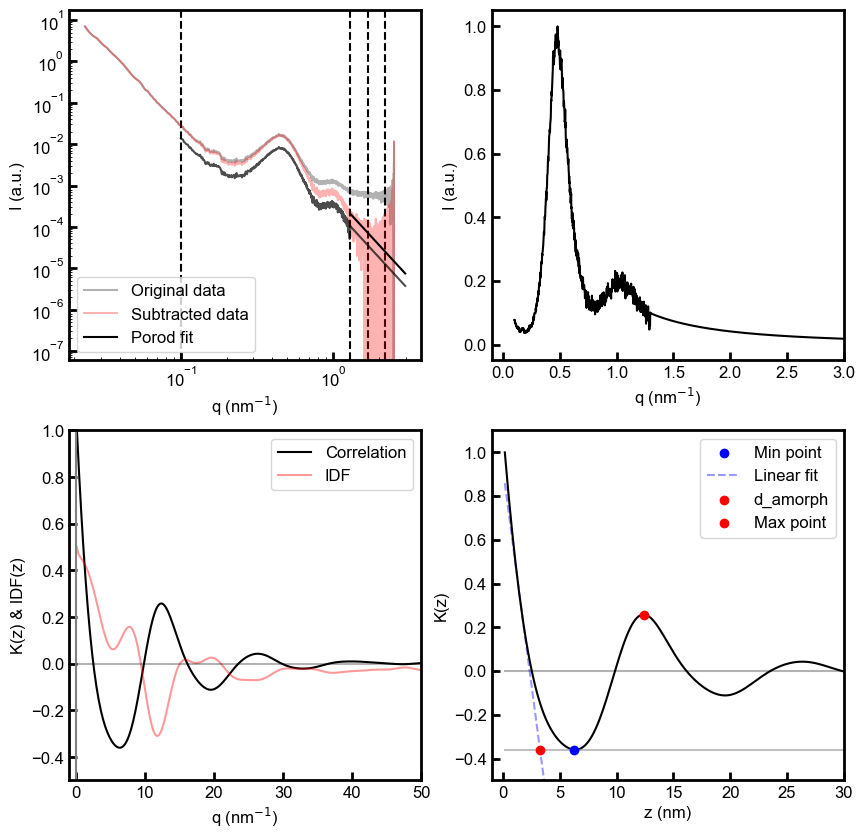

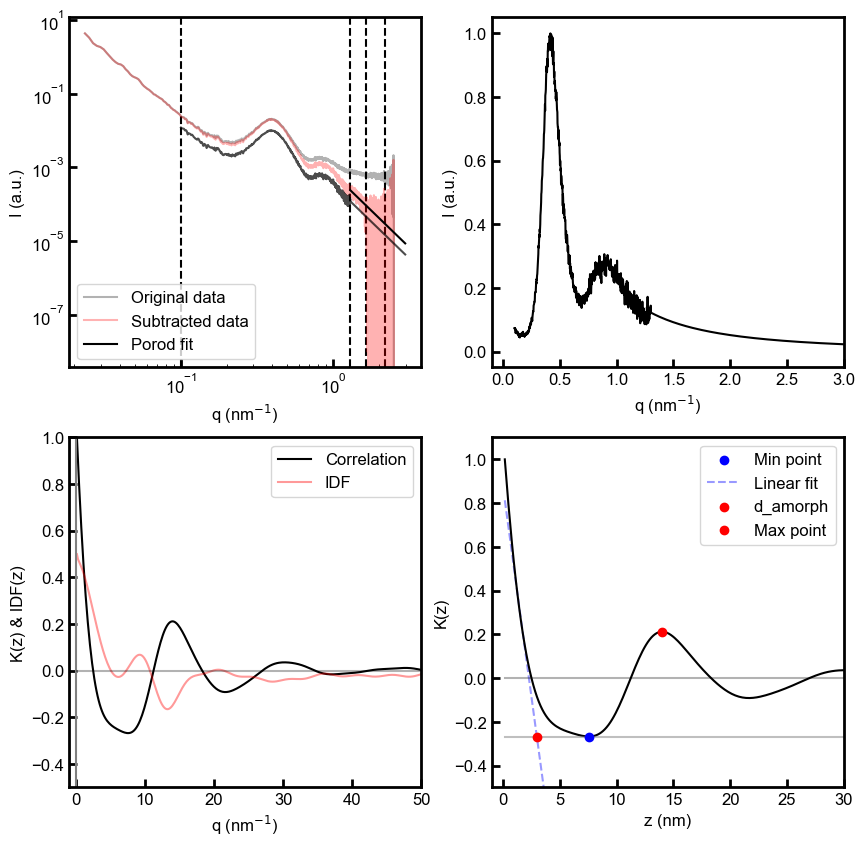

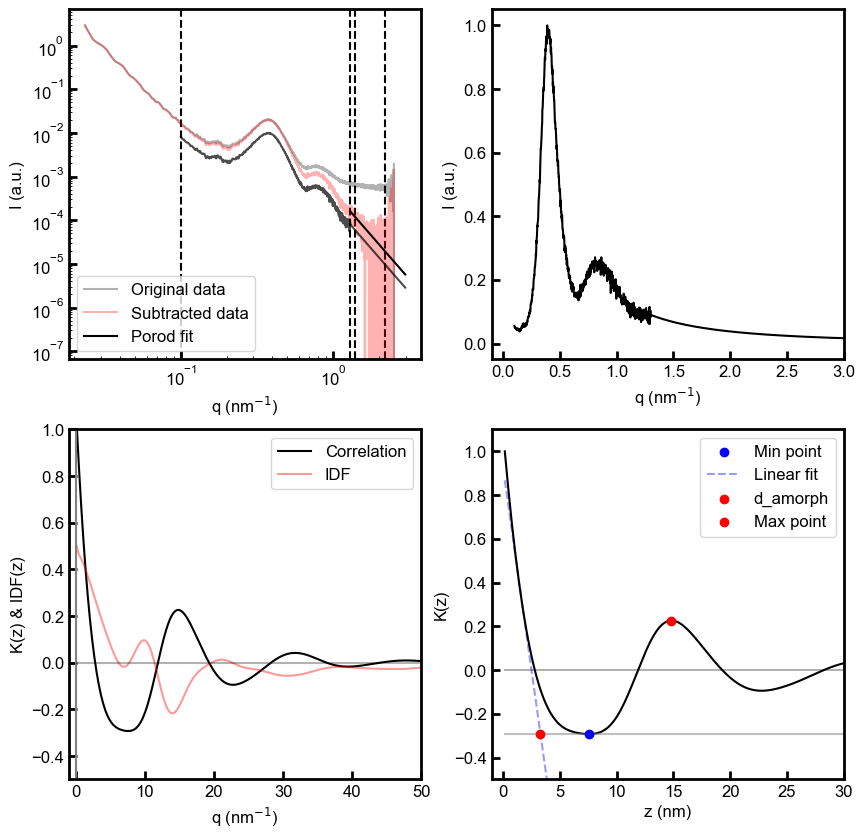

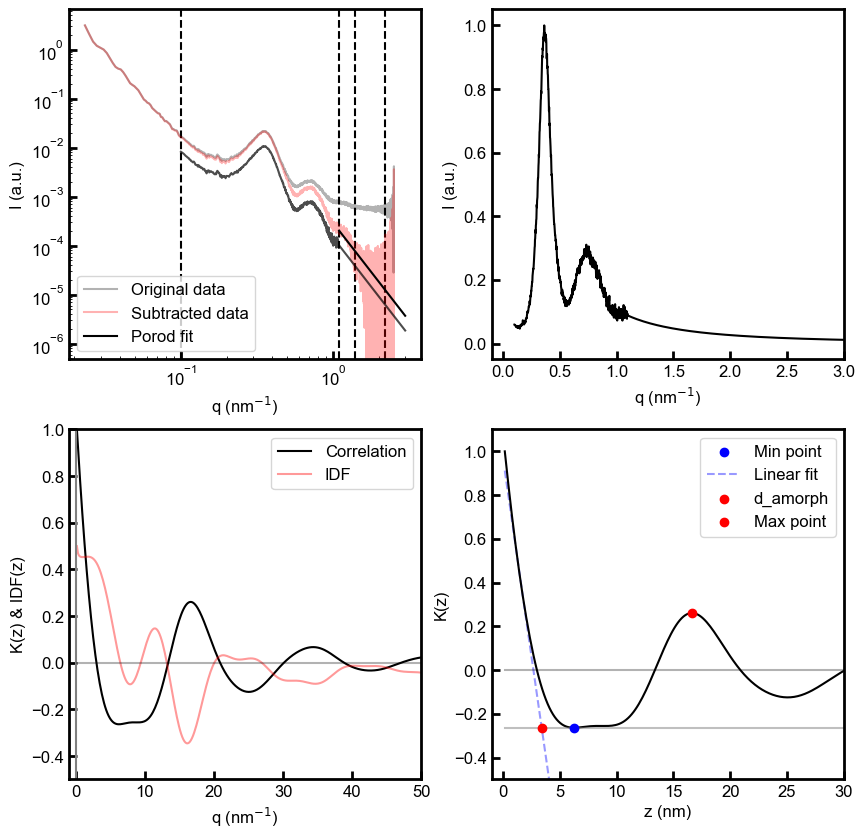

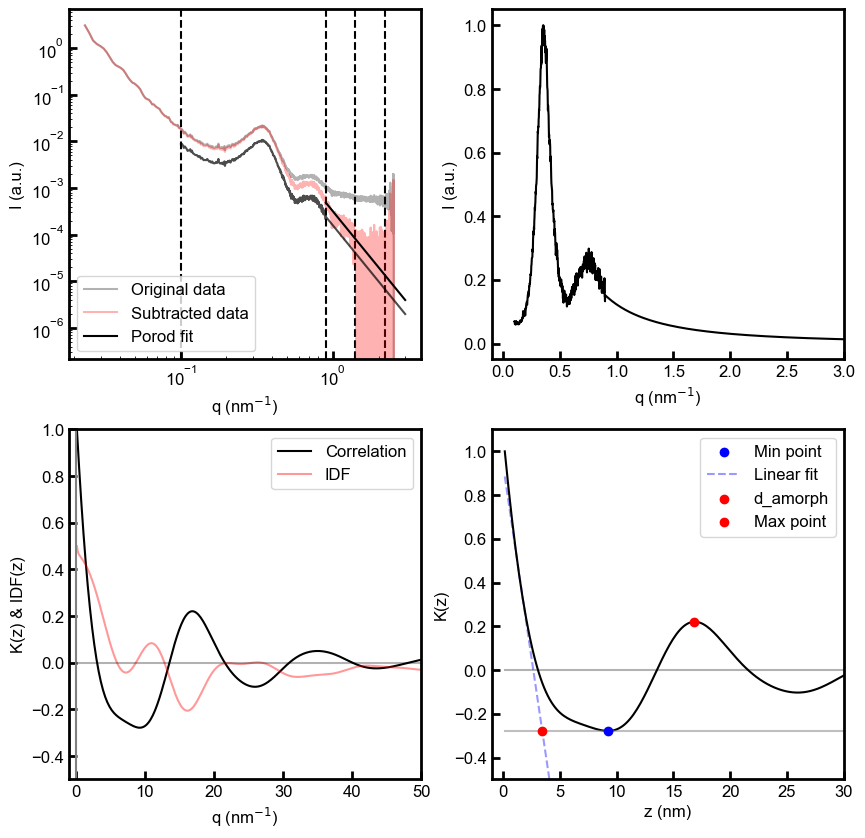

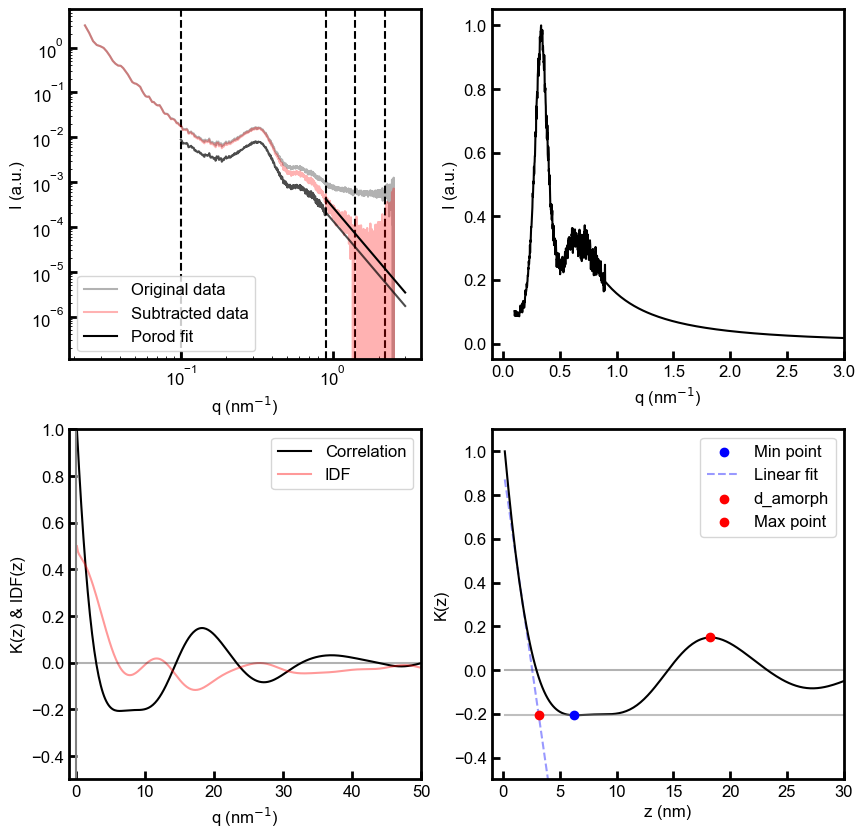

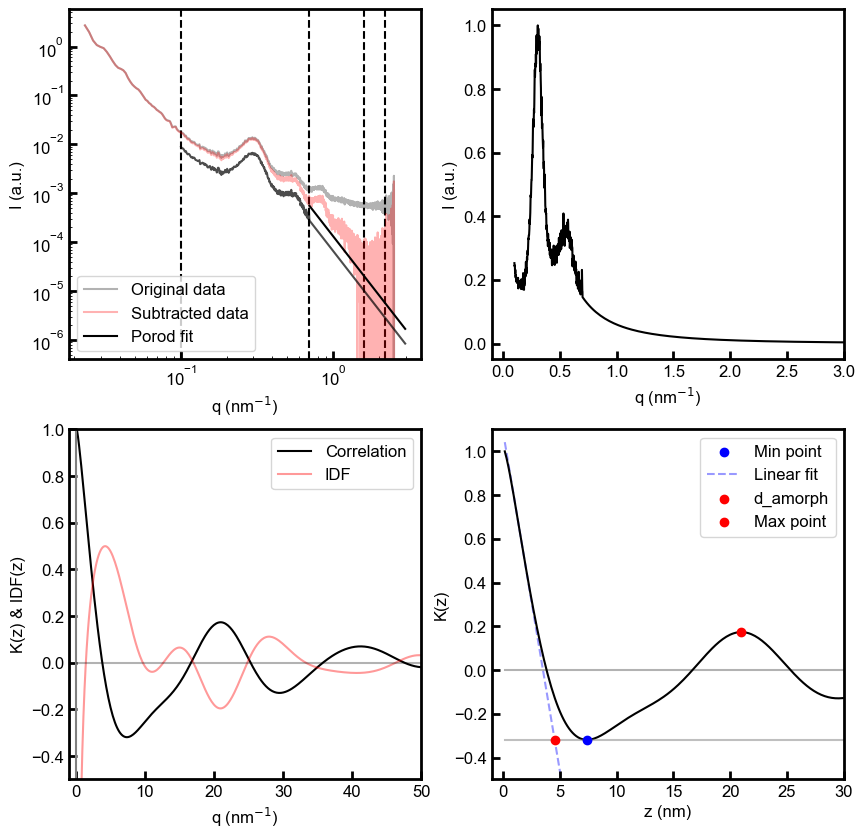

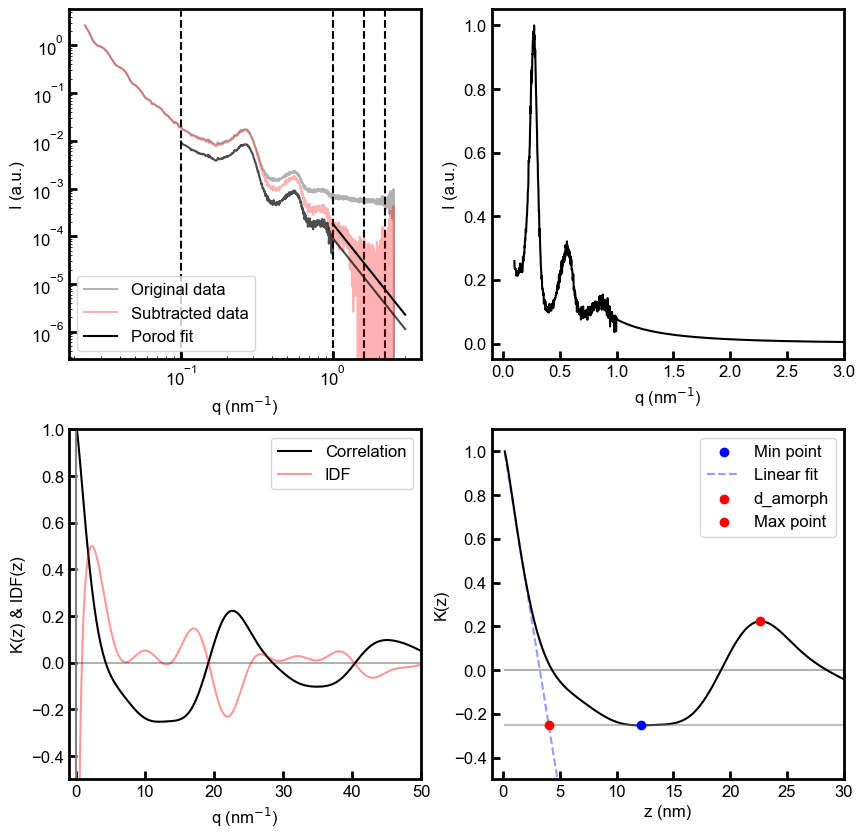

In [6]:
import pandas as pd

results_list = []
corr_funcs = []

# after quenching
path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00294_00_00001_av.dat"
results1 = analyze_saxs_data(path, limits=[0.1, 1.3, 1.7, 2.2], factor=2, porod_const=1, sigma=0)
results = results1
results_list.append({'cooling_rate': 1600, 'd_am': results['d_amorphous'], 'd_cr': results['d_crystalline'], 'Lp': results['long_period'], 'Xc': results['crystalline_fraction']})
corr_funcs.append({'z':results['z'], 'K':results['correlation']})

# 1000 K/s
path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00290_00_00001_av.dat"
results2 = analyze_saxs_data(path, limits=[0.1, 1.3, 1.65, 2.2], factor=2, porod_const=0.85, sigma=0)
results = results2
results_list.append({'cooling_rate': 1000, 'd_am': results['d_amorphous'], 'd_cr': results['d_crystalline'], 'Lp': results['long_period'], 'Xc': results['crystalline_fraction']})
corr_funcs.append({'z':results['z'], 'K':results['correlation']})

# 100 K/s
path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00299_00_00001_av.dat"
results3 = analyze_saxs_data(path, limits=[0.1, 1.3, 1.4, 2.2], factor=2, porod_const=1, sigma=0)
results = results3
results_list.append({'cooling_rate': 100, 'd_am': results['d_amorphous'], 'd_cr': results['d_crystalline'], 'Lp': results['long_period'], 'Xc': results['crystalline_fraction']})
corr_funcs.append({'z':results['z'], 'K':results['correlation']})

# 10 K/s
path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00302_00_00001_av.dat"
results4 = analyze_saxs_data(path, limits=[0.1, 1.1, 1.4, 2.2], factor=2, porod_const=1., sigma=0)
results = results4
results_list.append({'cooling_rate': 10, 'd_am': results['d_amorphous'], 'd_cr': results['d_crystalline'], 'Lp': results['long_period'], 'Xc': results['crystalline_fraction']})
corr_funcs.append({'z':results['z'], 'K':results['correlation']})

# 5 K/s
path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00305_00_00001_av.dat"
results5 = analyze_saxs_data(path, limits=[0.1, 0.9, 1.4, 2.2], factor=2, porod_const=1., sigma=0)
results = results5
results_list.append({'cooling_rate': 5, 'd_am': results['d_amorphous'], 'd_cr': results['d_crystalline'], 'Lp': results['long_period'], 'Xc': results['crystalline_fraction']})
corr_funcs.append({'z':results['z'], 'K':results['correlation']})

# 1 K/s
path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00301_00_00001_av.dat"
results6 = analyze_saxs_data(path, limits=[0.1, 0.9, 1.4, 2.2], factor=2, porod_const=1., sigma=0)
results = results6
results_list.append({'cooling_rate': 1, 'd_am': results['d_amorphous'], 'd_cr': results['d_crystalline'], 'Lp': results['long_period'], 'Xc': results['crystalline_fraction']})
corr_funcs.append({'z':results['z'], 'K':results['correlation']})

# 0.333 K/s
path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00291_00_00001_av.dat"
results7 = analyze_saxs_data(path, limits=[0.1, 0.7, 1.6, 2.2], factor=1.5, porod_const=0.9, sigma=0)
results = results7
results_list.append({'cooling_rate': 0.333, 'd_am': results['d_amorphous'], 'd_cr': results['d_crystalline'], 'Lp': results['long_period'], 'Xc': results['crystalline_fraction']})
corr_funcs.append({'z':results['z'], 'K':results['correlation']})

# 0.017 K/s
path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00296_00_00001_av.dat"
results8 = analyze_saxs_data(path, limits= [0.1, 1., 1.6, 2.2], factor=1.5, porod_const=1., sigma=0)
results = results8
results_list.append({'cooling_rate': 0.017, 'd_am': results['d_amorphous'], 'd_cr': results['d_crystalline'], 'Lp': results['long_period'], 'Xc': results['crystalline_fraction']})
corr_funcs.append({'z':results['z'], 'K':results['correlation']})

df = pd.DataFrame(results_list)
df['fold'] = 49.847 / df['d_cr']
# print(df)
res = df

In [13]:
df['fold'] = 390 * 0.254 * 0.5 / (df['d_cr'] + 0.855 * df['d_am']) - 1

In [14]:
res

,cooling_rate,d_am,d_cr,Lp,Xc,fold
0,1600.000,3.255907,9.165361,12.421268,0.737876,3.145061
1,1000.000,2.974266,11.019334,13.993600,0.787455,2.652027
2,100.000,3.295782,11.483984,14.779766,0.777007,2.463182
3,10.000,3.404105,13.262459,16.666564,0.795752,2.062517
4,5.000,3.454410,13.369387,16.823797,0.794671,2.034386
5,1.000,3.143073,15.095823,18.238896,0.827672,1.785221
6,0.333,4.545019,16.366841,20.911860,0.782658,1.445584
7,0.017,4.026818,18.614608,22.641425,0.822148,1.245491


In [15]:
x1 = res['fold'] * res['Xc']
x1

0    2.320666
1    2.088352
2    1.913910
3    1.641253
4    1.616668
5    1.477577
6    1.131398
7    1.023978
dtype: float64

In [16]:
Nc = res['d_cr'] / 0.254 * 2
Na = res['d_am'] / 0.254 * 2

In [17]:
390 / (Nc + 0.5 * Na) 

0    4.588952
1    3.960351
2    3.771739
3    3.309831
4    3.280873
5    2.971676
6    2.657281
7    2.401103
dtype: float64

In [18]:
390 * 0.1273 + 0.2

49.847

In [19]:
def power(x, k, b):
    return b * x ** k

In [26]:
res.to_csv(r'E:\C390\res_static.txt', sep='\t')

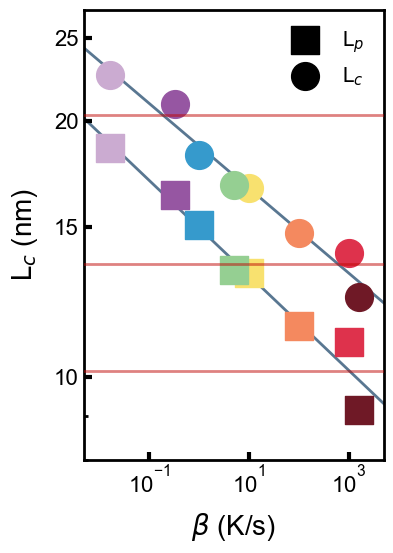

In [24]:
# ===================== СТИЛЬ ДЛЯ ПУБЛИКАЦИИ =====================
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 2
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['ytick.major.width'] = 2
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['ytick.major.size'] = 6
# =================================================================

fig, ax = plt.subplots(1, 1, figsize=(4, 6))
ax.set_position([0.15, 0.15, 0.75, 0.75])

rate = res['cooling_rate']
d_cr = res['d_cr']
Lp = res['Lp']

s_Lc = 400
s_Lp = 400

def power(x, a, b):
    return a * x ** b

# Lc (кружки)
ax.scatter(rate[0], d_cr[0], color='#6f1926', s=s_Lc, marker='s', zorder=5)
ax.scatter(rate[1], d_cr[1], color='#de324c', s=s_Lc, marker='s', zorder=5)
ax.scatter(rate[2], d_cr[2], color='#f4895f', s=s_Lc, marker='s', zorder=5)
ax.scatter(rate[3], d_cr[3], color='#f8e16f', s=s_Lc, marker='s', zorder=5)
ax.scatter(rate[4], d_cr[4], color='#95cf92', s=s_Lc, marker='s', zorder=5)
ax.scatter(rate[5], d_cr[5], color='#369acc', s=s_Lc, marker='s', zorder=5)
ax.scatter(rate[6], d_cr[6], color='#9656a2', s=s_Lc, marker='s', zorder=5)
ax.scatter(rate[7], d_cr[7], color='#cbabd1', s=s_Lc, marker='s', zorder=5)

p, _ = curve_fit(power, rate, d_cr)
x = np.linspace(1e-3, 3e4, 1000)
ax.plot(x, power(x, *p), color='#577590', alpha=0.99, zorder=0, linewidth=2)

# Lp (квадраты)
ax.scatter(rate[0], Lp[0], color='#6f1926', s=s_Lp, marker='o', zorder=5)
ax.scatter(rate[1], Lp[1], color='#de324c', s=s_Lp, marker='o', zorder=5)
ax.scatter(rate[2], Lp[2], color='#f4895f', s=s_Lp, marker='o', zorder=5)
ax.scatter(rate[3], Lp[3], color='#f8e16f', s=s_Lp, marker='o', zorder=5)
ax.scatter(rate[4], Lp[4], color='#95cf92', s=s_Lp, marker='o', zorder=5)
ax.scatter(rate[5], Lp[5], color='#369acc', s=s_Lp, marker='o', zorder=5)
ax.scatter(rate[6], Lp[6], color='#9656a2', s=s_Lp, marker='o', zorder=5)
ax.scatter(rate[7], Lp[7], color='#cbabd1', s=s_Lp, marker='o', zorder=5)

p, _ = curve_fit(power, rate, Lp)
ax.plot(x, power(x, *p), color='#577590', alpha=0.99, zorder=0, linewidth=2)

# Горизонтальные линии
ax.axhline(y=20.35, color='#bf0603', linewidth=2, zorder=10, alpha=0.5)
ax.axhline(y=13.57, color='#bf0603', linewidth=2, zorder=10, alpha=0.5)
ax.axhline(y=10.18, color='#bf0603', linewidth=2, zorder=10, alpha=0.5)

# ===================== НАСТРОЙКИ ОСЕЙ =====================
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(5e-3, 5e3)
ax.set_ylim(8, 27)

ax.set_xlabel('$\\beta$ (K/s)', fontname='Arial', fontsize=20, labelpad=10)
ax.set_ylabel('L$_c$ (nm)', fontname='Arial', fontsize=20, labelpad=10)

ax.tick_params(axis='both', which='major', labelsize=16, length=6, width=3)
ax.tick_params(axis='both', which='minor', length=3, width=2)

ax.set_yticks([10, 15, 20, 25])
ax.set_yticklabels(['10', '15', '20', '25'])

# Легенда
ax.scatter([], [], color='black', s=s_Lp, marker='s', label='L$_p$')
ax.scatter([], [], color='black', s=s_Lc, marker='o', label='L$_c$')
ax.legend(fontsize=15, frameon=True, facecolor='white', edgecolor='white', framealpha=1.0, loc=1)

ax.set_position([0.15, 0.15, 0.75, 0.75])
plt.savefig(r'E:\C390\Figures\Fig1_b.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

### Correlation plot

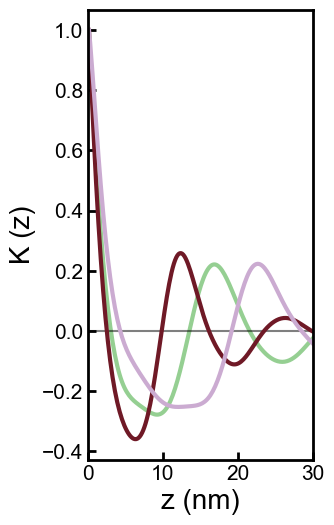

In [23]:
# ===================== СТИЛЬ ДЛЯ ПУБЛИКАЦИИ =====================
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 2
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['ytick.major.width'] = 2
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['ytick.major.size'] = 6
# =================================================================

fig, ax = plt.subplots(1, 1, figsize=(3, 6))
ax.set_position([0.15, 0.15, 0.75, 0.75])

plt.plot(results1['z'], results1['correlation'], color='#6f1926', linewidth=3)
plt.plot(results5['z'], results5['correlation'], color='#95cf92', linewidth=3, zorder=0)
plt.plot(results8['z'], results8['correlation'], color='#cbabd1', linewidth=3)
plt.plot(results2['z'], results2['z']*0, color='black', alpha=0.5, zorder=0)

ax.set_xlim(0, 30)
# ax.set_ylim(5e-6, 2e2)

# НАСТРОЙКА ТИКОВ: ТОЛЬКО 0.1 И 1 (без лишних)
# Отключаем все автоматические тики
ax.xaxis.set_major_locator(ticker.FixedLocator([0, 10, 20, 30]))
ax.xaxis.set_minor_locator(ticker.NullLocator())  # убираем малые тики

# Формат подписей: десятичные числа, без научного формата
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.xaxis.get_major_formatter().set_scientific(False)

# Подписи осей (Arial, размер 20 как в вашем примере)
ax.set_xlabel('z (nm)', fontname='Arial', fontsize=20)
ax.set_ylabel('K (z)', fontname='Arial', fontsize=20)
# ax.set_ylim()
# Легенда
# ax.legend(fontsize=10, loc=2, frameon=False)
# ax.set_xticks([0.2, 1, 2])
# Размер цифр на тиках
ax.tick_params(axis='both', which='major', labelsize=15, length=6, width=2)
ax.tick_params(axis='both', which='minor', length=3, width=1) 

plt.savefig(r'E:\C390\Figures\Fig2_Corr.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

## Heating

### NC

In [19]:
def T_programm(x):
    """Векторизованная кусочно-линейная функция температуры"""
    xp = np.array([0, 50, 175, 185, 310, 360])
    fp = np.array([0, 0, 125, 125, 0, 0])
    return np.interp(x, xp, fp, left=0, right=0)

from scipy.interpolate import Akima1DInterpolator
def get_background(x, y, l, r):
    mask = np.ones(len(x), dtype=bool)
    mask[l:r+1] = False
    interp = Akima1DInterpolator(x[mask], y[mask])
    return interp(x)


C:\Users\LabPCA\AppData\Local\Temp\ipykernel_9880\1600659905.py:12: OptimizeWarning:

Covariance of the parameters could not be estimated



Text(0, 0.5, 'T (°C)')

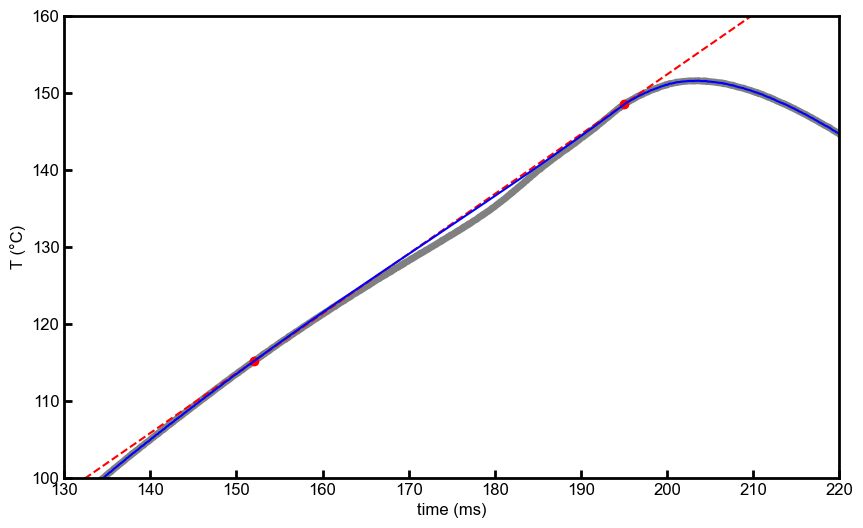

In [450]:
path = r"E:\C390\NANOCAL-DATA\C390_3m_20deg_min_cooling_S2_run2_293.txt"
# path = r"\\Synology\Data\2025\ESRF_SC5671\NANOCAL\DATA\2025-06-20-sc5671_ID02\test.txt"

NC = pd.read_csv(path, skiprows=2, sep='	', names=['t', 'T', 1,2,3,4,5,6,7])

time = NC['t']
T = NC['T']
plt.plot(time, T, label='exp', linewidth=5, zorder=0, color='grey')
l, r = 1520, 1950
plt.scatter([time[l], time[r]], [T[l], T[r]], color='r')

p, cov = curve_fit(linear, [time[l], time[r]], [T[l], T[r]])
plt.plot(x, linear(x, *p), color='r', linestyle='--')



x = np.linspace(0, 360, 1000)
# plt.plot(x, T_programm(x)+24, label='Programm')

bkg = get_background(time, T, l, r )
plt.plot(time, bkg, color='blue')

plt.xlim(130, 220)
plt.ylim(100, 160)

plt.xlabel('time (ms)')
plt.ylabel('T (°C)')

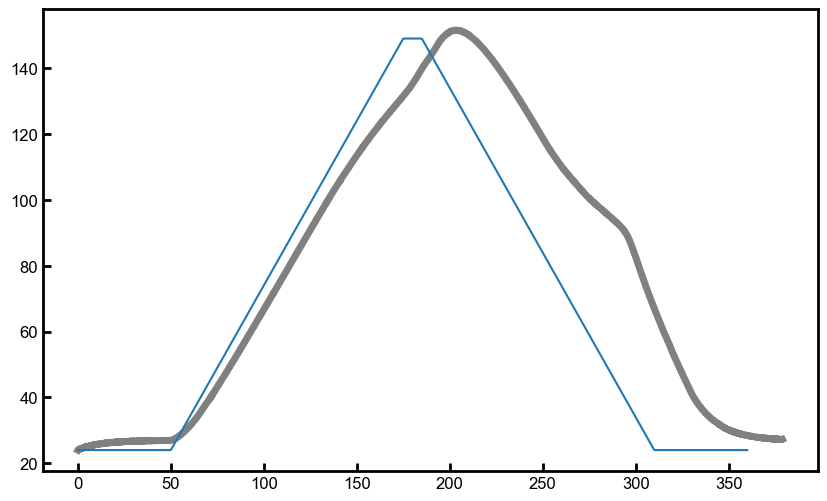

In [451]:
plt.plot(time, T, label='exp', linewidth=5, zorder=0, color='grey')
plt.plot(x, T_programm(x)+24, label='Programm')


<>:9: SyntaxWarning:

invalid escape sequence '\D'

<>:9: SyntaxWarning:

invalid escape sequence '\D'

C:\Users\LabPCA\AppData\Local\Temp\ipykernel_9880\2584214740.py:9: SyntaxWarning:

invalid escape sequence '\D'



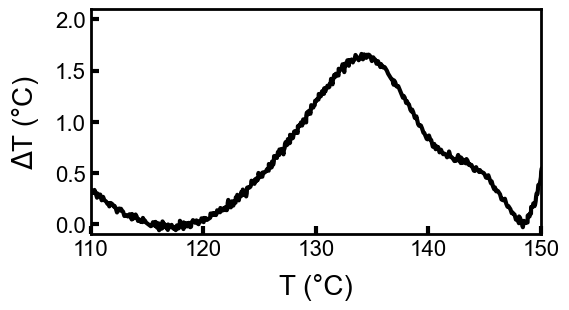

In [475]:
fig, ax = plt.subplots(1, 1, figsize=(6, 3))
ax.set_position([0.15, 0.15, 0.75, 0.75])

ax.plot(T, -T + linear(time, *p), color='black', linewidth=3)

ax.set_xlim(110, 150)
ax.set_ylim(-0.1, 2.1)

ax.set_ylabel('$\Delta$T (°C)', fontname='Arial', fontsize=20, labelpad=10)
ax.set_xlabel('T (°C)', fontname='Arial', fontsize=20, labelpad=10)

ax.tick_params(axis='both', which='major', labelsize=16, length=6, width=3)
ax.tick_params(axis='both', which='minor', length=3, width=2)

ax.set_yticks([0, 0.5, 1, 1.5, 2])

ax.set_position([0.15, 0.15, 0.75, 0.75])
plt.savefig(r'E:\C390\Figures\Fig_NC.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

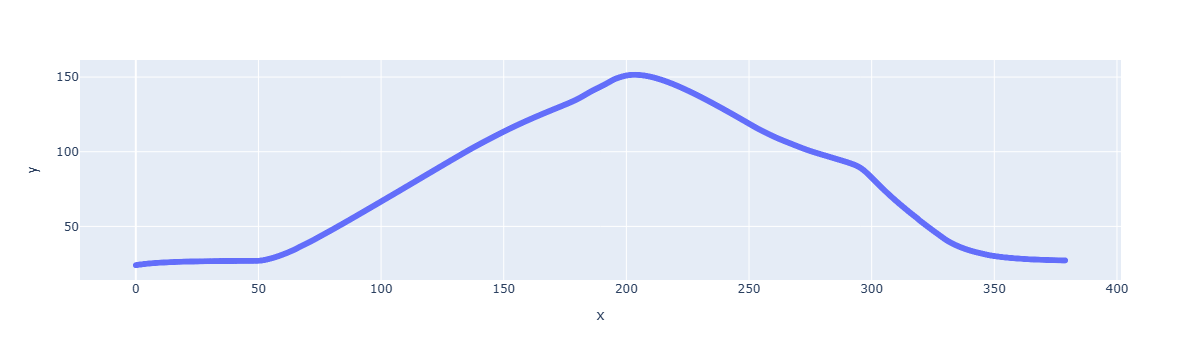

In [237]:
px.scatter(x=time, y=T)

In [226]:
import numpy as np

indices = np.array([0, 60, 65, 70, 75, 80, 85, 90, 93, 100])
target_times = indices * 1.9

for target in target_times:
    pos = np.argmin(np.abs(time - target))
    print(f"Время {target:.1f} -> ближайшее time[{pos}] = {time[pos]:.2f}, T = {T[pos]:.2f}")

Время 0.0 -> ближайшее time[0] = 0.00, T = 23.99
Время 114.0 -> ближайшее time[1140] = 114.00, T = 80.19
Время 123.5 -> ближайшее time[1235] = 123.50, T = 89.37
Время 133.0 -> ближайшее time[1330] = 133.00, T = 98.51
Время 142.5 -> ближайшее time[1425] = 142.50, T = 107.11
Время 152.0 -> ближайшее time[1520] = 152.00, T = 115.09
Время 161.5 -> ближайшее time[1615] = 161.50, T = 122.22
Время 171.0 -> ближайшее time[1710] = 171.00, T = 128.84
Время 176.7 -> ближайшее time[1767] = 176.70, T = 132.70
Время 190.0 -> ближайшее time[1900] = 190.00, T = 144.05


### Plot

In [20]:
path = r"\\Synology\Data\2025\ESRF_SC5671\ef20\ef20_20250620-091305\ef20_eiger2_00293_00_ave.h5"

Exp = ID02_experiment(path)

def average(Exp, index):
    q, res = Exp.get_1d_data()
    res *= 0
    
    for i in index:
        q, I = Exp.get_1d_data(i)
        res += I
    res /= len(index)
    return q, res
from scipy.signal import savgol_filter


In [422]:
Exp.get_Title()

'C390_S2_3m_R1_cryst1kKps'

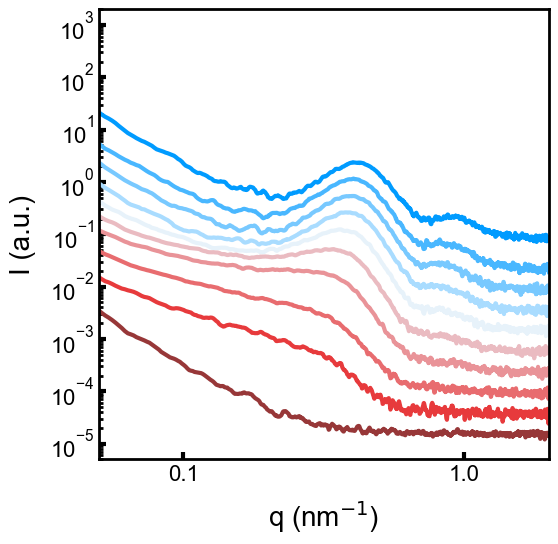

In [454]:
# ===================== СТИЛЬ ДЛЯ ПУБЛИКАЦИИ =====================
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 2
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['ytick.major.width'] = 2
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['ytick.major.size'] = 6
# =================================================================

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.set_position([0.15, 0.15, 0.75, 0.75])

scale = 2.5
linewidth = 3
window = 15
color_array = ["#009bff","#49b7ff","#78c9ff","#a9dcff","#e7f2fa","#eabbc1","#e99398","#e86c6f","#e73a3c","#973738"]


indexes = [i for i in range(0, 10)]
q, I = average(Exp,indexes)
I_smooth = savgol_filter(I, window_length=window, polyorder=3)
ax.plot(q, I_smooth * scale ** 5 * 1.5, color=color_array[0], linewidth=linewidth)

indexes = [i for i in range(60, 65)]
q, I = average(Exp,indexes)
I_smooth = savgol_filter(I, window_length=window, polyorder=3)
ax.plot(q, I_smooth * scale ** 4, color=color_array[1], linewidth=linewidth)

indexes = [i for i in range(65, 70)]
q, I = average(Exp,indexes)
I_smooth = savgol_filter(I, window_length=window, polyorder=3)
ax.plot(q, I_smooth * scale ** 3, color=color_array[2], linewidth=linewidth)

indexes = [i for i in range(70, 75)]
q, I = average(Exp,indexes)
I_smooth = savgol_filter(I, window_length=window, polyorder=3)
ax.plot(q, I_smooth * scale ** 2, color=color_array[3], linewidth=linewidth)

indexes = [i for i in range(75, 80)]
q, I = average(Exp,indexes)
I_smooth = savgol_filter(I, window_length=window, polyorder=3)
ax.plot(q, I_smooth * scale ** 1, color=color_array[4], linewidth=linewidth)

indexes = [i for i in range(80, 85)]
q, I = average(Exp,indexes)
I_smooth = savgol_filter(I, window_length=window, polyorder=3)
ax.plot(q, I_smooth * scale ** 0, color=color_array[5], linewidth=linewidth)

indexes = [i for i in range(85, 90)]
q, I = average(Exp,indexes)
I_smooth = savgol_filter(I, window_length=window, polyorder=3)
ax.plot(q, I_smooth * scale ** -1, color=color_array[6], linewidth=linewidth)

indexes = [i for i in range(90, 95)]
q, I = average(Exp,indexes)
I_smooth = savgol_filter(I, window_length=window, polyorder=3)
ax.plot(q, I_smooth * scale ** -2, color=color_array[7], linewidth=linewidth)

indexes = [i for i in range(93, 96)]
q, I = average(Exp,indexes)
I_smooth = savgol_filter(I, window_length=window, polyorder=3)
ax.plot(q, I_smooth * scale ** -3, color=color_array[8], linewidth=linewidth)

indexes = [i for i in range(100, 110)]
q, I = average(Exp,indexes)
I_smooth = savgol_filter(I, window_length=window, polyorder=3)
ax.plot(q, I_smooth * scale ** -4, color=color_array[9], linewidth=linewidth)

ax.set_xlim(0.05, 2)
ax.set_ylim(5e-6, 2e3)
ax.set_xscale('log')
ax.set_yscale('log')

ax.xaxis.set_major_locator(ticker.FixedLocator([0.1, 1]))
ax.xaxis.set_minor_locator(ticker.NullLocator())
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.xaxis.get_major_formatter().set_scientific(False)

ax.set_xlabel('q (nm$^{-1}$)', fontname='Arial', fontsize=20, labelpad=10)
ax.set_ylabel('I (a.u.)', fontname='Arial', fontsize=20, labelpad=10)

ax.tick_params(axis="both", which='major', direction="in", width=3, length=5, labelsize=16)
ax.tick_params(axis="both", which='minor', direction="in", width=2, length=3)


ax.set_position([0.15, 0.15, 0.75, 0.75])
plt.savefig(r'E:\C390\Figures\Fig2.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

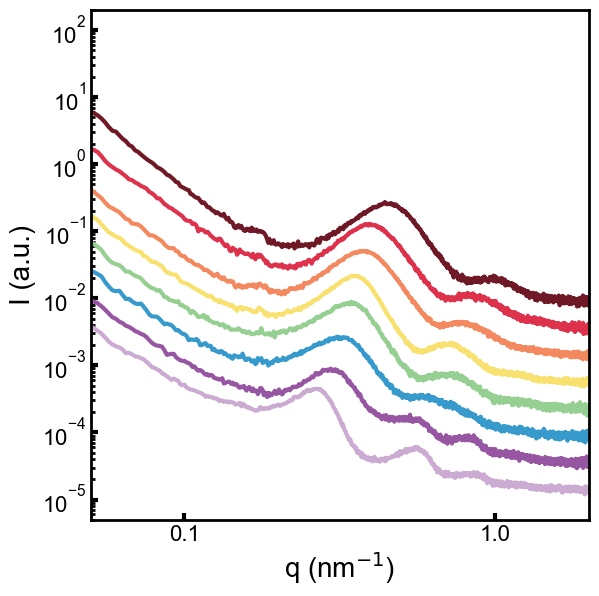

In [417]:
# ===================== СТИЛЬ ДЛЯ ПУБЛИКАЦИИ =====================
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 2
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['ytick.major.width'] = 2
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['ytick.major.size'] = 6
# =================================================================

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.set_position([0.15, 0.15, 0.75, 0.75])

scale = 2.5
linewidth = 3

# Ваши данные
path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00294_00_00001_av.dat"
df = pd.read_csv(path, skiprows=2, names=['q', 'I', 'err'], sep='\t')
q, I = np.array(df['q']), np.array(df['I'])
ax.plot(q, I * scale ** 3, label='after quenching', linewidth=linewidth, color='#6f1926')

path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00290_00_00001_av.dat"
df = pd.read_csv(path, skiprows=2, names=['q', 'I', 'err'], sep='\t')
q, I = np.array(df['q']), np.array(df['I'])
ax.plot(q, I * scale ** 2, label='1000 K/s', linewidth=linewidth, color='#de324c')

path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00299_00_00001_av.dat"
df = pd.read_csv(path, skiprows=2, names=['q', 'I', 'err'], sep='\t')
q, I = np.array(df['q']), np.array(df['I'])
ax.plot(q, I * scale ** 1, label='100 K/s', linewidth=linewidth, color='#f4895f')

path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00302_00_00001_av.dat"
df = pd.read_csv(path, skiprows=2, names=['q', 'I', 'err'], sep='\t')
q, I = np.array(df['q']), np.array(df['I'])
ax.plot(q, I * scale ** 0, label='10 K/s', linewidth=linewidth, color='#f8e16f')

path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00305_00_00001_av.dat"
df = pd.read_csv(path, skiprows=2, names=['q', 'I', 'err'], sep='\t')
q, I = np.array(df['q']), np.array(df['I'])
ax.plot(q, I * scale ** -1, label='5 K/s', linewidth=linewidth, color='#95cf92')

path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00301_00_00001_av.dat"
df = pd.read_csv(path, skiprows=2, names=['q', 'I', 'err'], sep='\t')
q, I = np.array(df['q']), np.array(df['I'])
ax.plot(q, I * scale ** -2, label='1 K/s', linewidth=linewidth, color='#369acc')

path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00291_00_00001_av.dat"
df = pd.read_csv(path, skiprows=2, names=['q', 'I', 'err'], sep='\t')
q, I = np.array(df['q']), np.array(df['I'])
ax.plot(q, I * scale ** -3, label='0.333 K/s', linewidth=linewidth, color='#9656a2')

path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00296_00_00001_av.dat"
df = pd.read_csv(path, skiprows=2, names=['q', 'I', 'err'], sep='\t')
q, I = np.array(df['q']), np.array(df['I'])
ax.plot(q, I * scale ** -4, label='0.017 K/s', linewidth=linewidth, color='#cbabd1')

# ===================== НАСТРОЙКИ ОСЕЙ =====================
ax.set_xlim(0.05, 2)
ax.set_ylim(5e-6, 2e2)

# Логарифмическая шкала
ax.set_xscale('log')
ax.set_yscale('log')

# НАСТРОЙКА ТИКОВ: ТОЛЬКО 0.1 И 1 (без лишних)
ax.xaxis.set_major_locator(ticker.FixedLocator([0.1, 1]))
ax.xaxis.set_minor_locator(ticker.NullLocator())

# Формат подписей: десятичные числа, без научного формата
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.xaxis.get_major_formatter().set_scientific(False)

# Подписи осей (Arial, размер 20)
ax.set_xlabel('q (nm$^{-1}$)', fontname='Arial', fontsize=20)
ax.set_ylabel('I (a.u.)', fontname='Arial', fontsize=20)

# Размер цифр на тиках
ax.tick_params(axis="both", which='major', direction="in", width=3, length=5, labelsize=16)
ax.tick_params(axis="both", which='minor', direction="in", width=2, length=3, labelsize=16)

plt.tight_layout()
plt.savefig(r'E:\C390\Figures\Fig1_a.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

### Corr

0
1
2
3
4
5
6
7
8
9


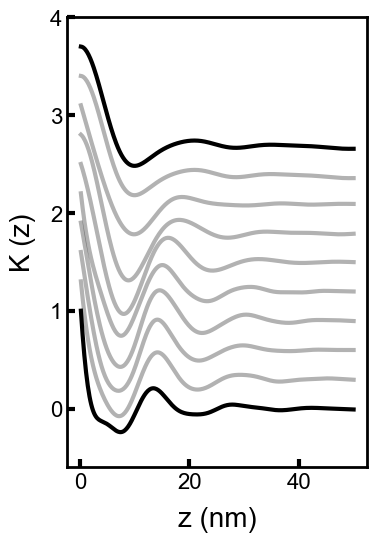

In [30]:
### ===================== СТИЛЬ ДЛЯ ПУБЛИКАЦИИ =====================
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 2
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['ytick.major.width'] = 2
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['ytick.major.size'] = 6
# =================================================================

fig, ax = plt.subplots(1, 1, figsize=(4, 6))
ax.set_position([0.15, 0.15, 0.75, 0.75])

colors = ['black', 'black', 'black', 'black', 'black', 'black', 'black', 'black', 'black', 'black',]
alphas = [1, .3, .3, .3, .3, .3, .3, .3, .3,  1]
number = [0, 21, 22, 24, 25, 27, 29, 30, 31, 32]

for i in range(10):
    print(i)
    z = corr_funcs[number[i]]['z']
    K = corr_funcs[number[i]]['K']
    plt.plot(z, K + i*.3, color=colors[i], linewidth=3, alpha=alphas[i])


ax.set_xlabel('z (nm)', fontname='Arial', fontsize=20, labelpad=10)
ax.set_ylabel('K (z)', fontname='Arial', fontsize=20, labelpad=10)

ax.tick_params(axis='both', which='major', labelsize=16, length=6, width=3)
ax.tick_params(axis='both', which='minor', length=3, width=2)

ax.set_ylim(-.6, 3.5)
ax.set_yticks([0, 1, 2, 3, 4])
# Легенда
# ax.scatter([], [], color='black', s=s_Lp, marker='s', label='L$_p$')
# ax.scatter([], [], color='black', s=s_Lc, marker='o', label='L$_c$')
# ax.legend(fontsize=15, frameon=True, facecolor='white', edgecolor='white', framealpha=1.0, loc=1)

ax.set_position([0.15, 0.15, 0.75, 0.75])
plt.savefig(r'C:\Users\LabPCA\Desktop\Fig2_SI.png', dpi=300, bbox_inches='tight', transparent=True)

D_amorphous = 5.000
D_crystalline = 8.208
Long period = 13.207
Crystalline fraction = 0.621

D_amorphous = 6.733
D_crystalline = 11.034
Long period = 17.767
Crystalline fraction = 0.621



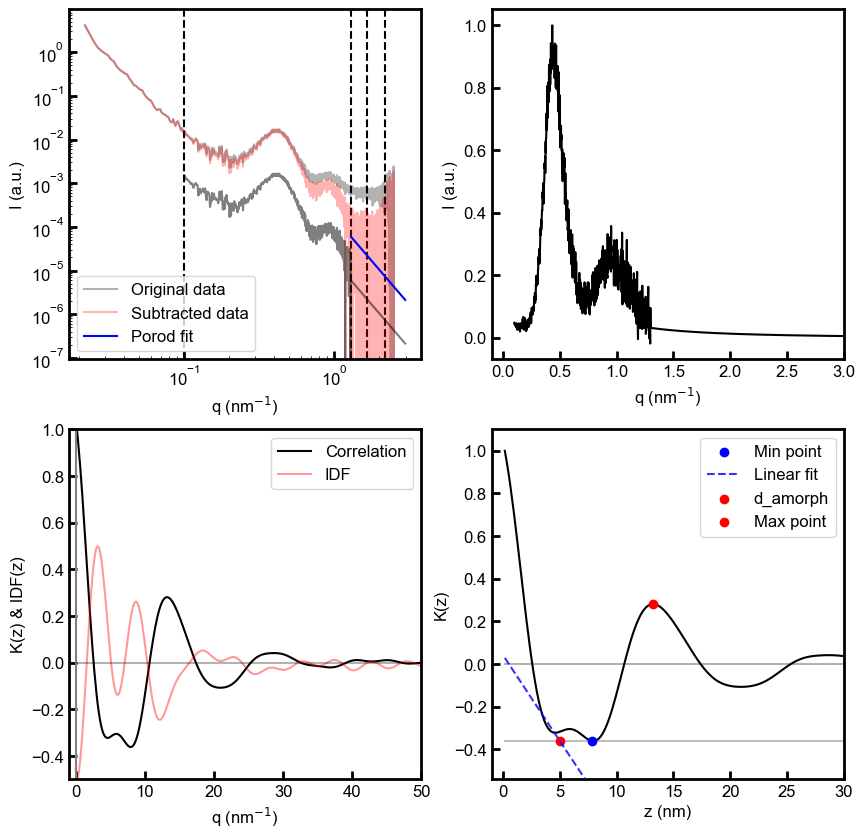

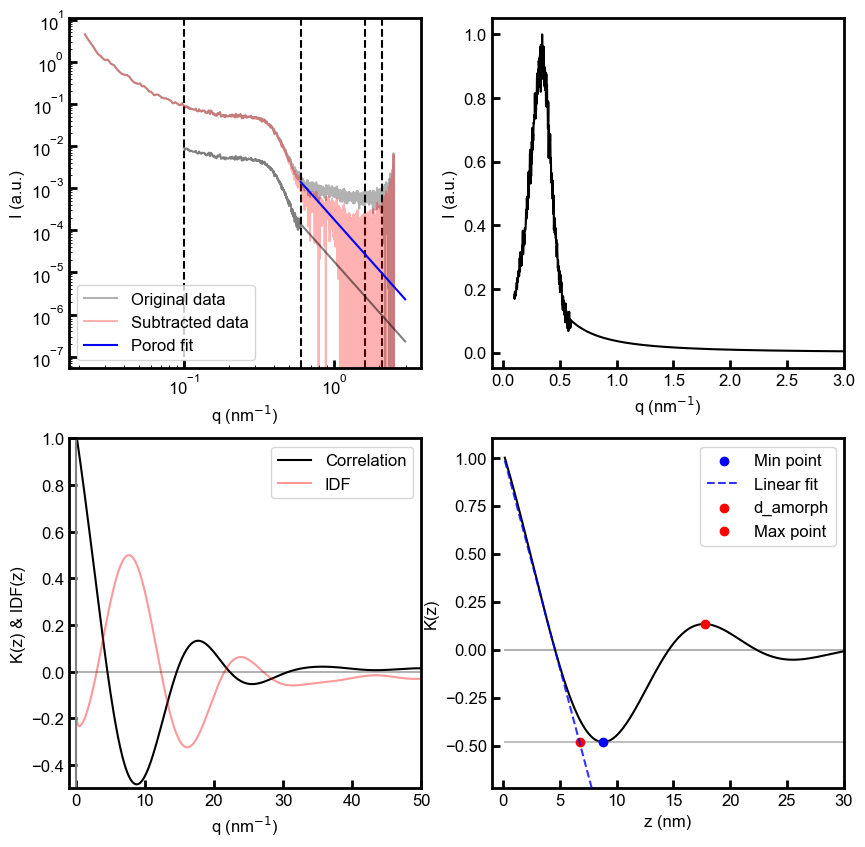

In [398]:
path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00290_00_00001_av.dat"
# results2 = analyze_saxs_data(path, limits=[0.1, 1.3, 1.65, 2.2], factor=2, porod_const=0.85, sigma=0)

Lp = []
d_cr = []

q, I = average(Exp, [i for i in range(0, 10)])
results = analyze_saxs_data_q_I(q, I, limits=[0.1, 1.3, 1.65, 2.2], factor=2, porod_const=1, sigma=0, lin1=3, lin2=5)
d_cr.append(results['d_crystalline'])
Lp.append(results['long_period'])
print()

q, I = average(Exp, [i for i in range(85, 90)])
results = analyze_saxs_data_q_I(q, I, limits=[0.1, .6, 1.62, 2.1], factor=2, porod_const=1, sigma=0, lin1=3, lin2=5)
d_cr.append(results['d_crystalline'])
Lp.append(results['long_period'])
print()

# q, I = average(Exp, [i for i in range(90, 92)])
# results = analyze_saxs_data_q_I(q, I, limits=[0., 0.6, 1.62, 2.1], factor=2, porod_const=1, sigma=0, lin1=3, lin2=5)
# d_cr.append(results['d_crystalline'])
# Lp.append(results['long_period'])
# print()

# q, I = average(Exp, [i for i in range(93, 96)])
# results = analyze_saxs_data_q_I(q, I, limits=[0., 0.6, 1.62, 2.1], factor=2, porod_const=1, sigma=0, lin1=3, lin2=5)
# d_cr.append(results['d_crystalline'])
# Lp.append(results['long_period'])
# print()

In [ ]:
corr_funcs

D_amorphous = 1.924
D_crystalline = 11.441
Long period = 13.365
Crystalline fraction = 0.856
D_amorphous = 2.160
D_crystalline = 11.204
Long period = 13.365
Crystalline fraction = 0.838
D_amorphous = 1.929
D_crystalline = 11.435
Long period = 13.365
Crystalline fraction = 0.856
D_amorphous = 2.472
D_crystalline = 10.892
Long period = 13.365
Crystalline fraction = 0.815
D_amorphous = 2.004
D_crystalline = 11.361
Long period = 13.365
Crystalline fraction = 0.850
D_amorphous = 2.286
D_crystalline = 11.078
Long period = 13.365
Crystalline fraction = 0.829
D_amorphous = 2.597
D_crystalline = 10.767
Long period = 13.365
Crystalline fraction = 0.806
D_amorphous = 2.033
D_crystalline = 11.489
Long period = 13.522
Crystalline fraction = 0.850
D_amorphous = 1.990
D_crystalline = 11.532
Long period = 13.522
Crystalline fraction = 0.853
D_amorphous = 1.782
D_crystalline = 11.740
Long period = 13.522
Crystalline fraction = 0.868
D_amorphous = 2.528
D_crystalline = 10.837
Long period = 13.365
Crysta

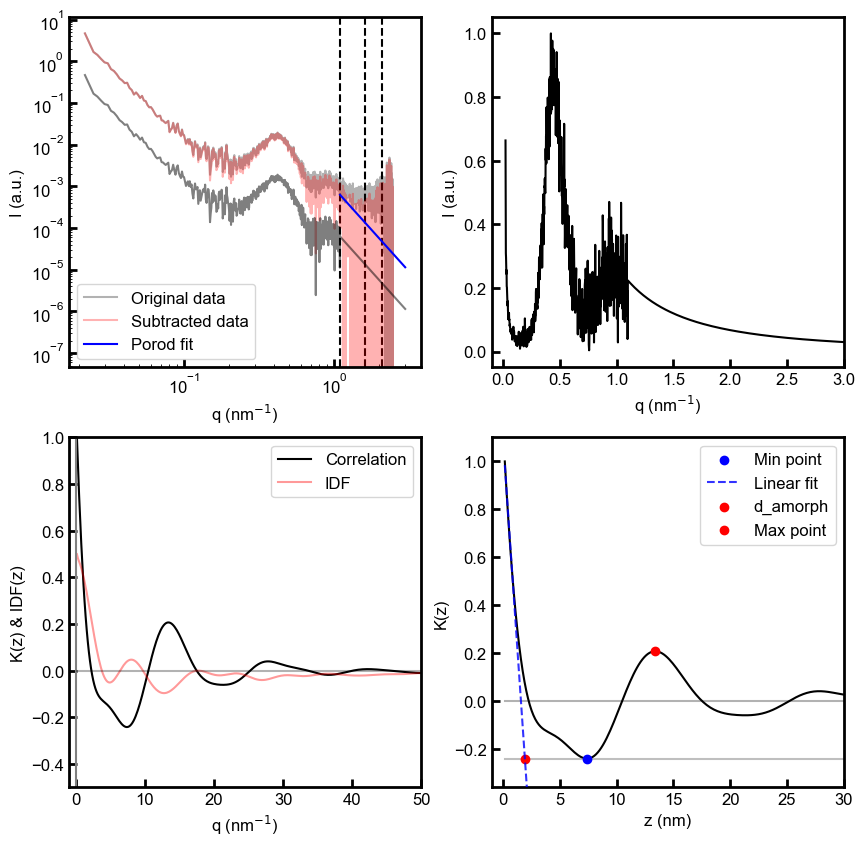

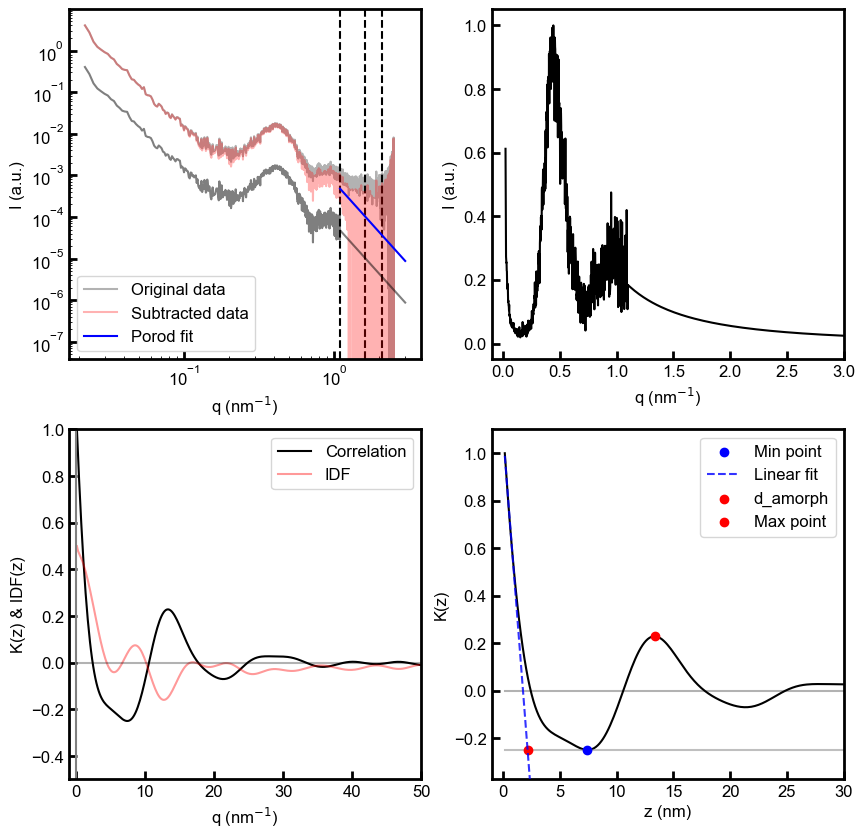

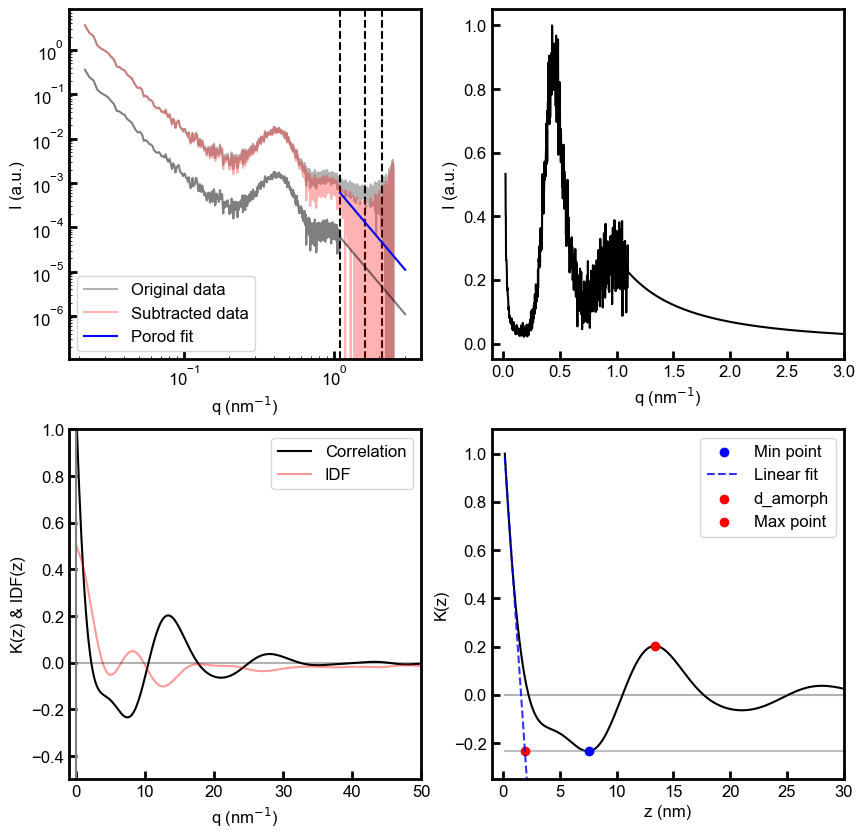

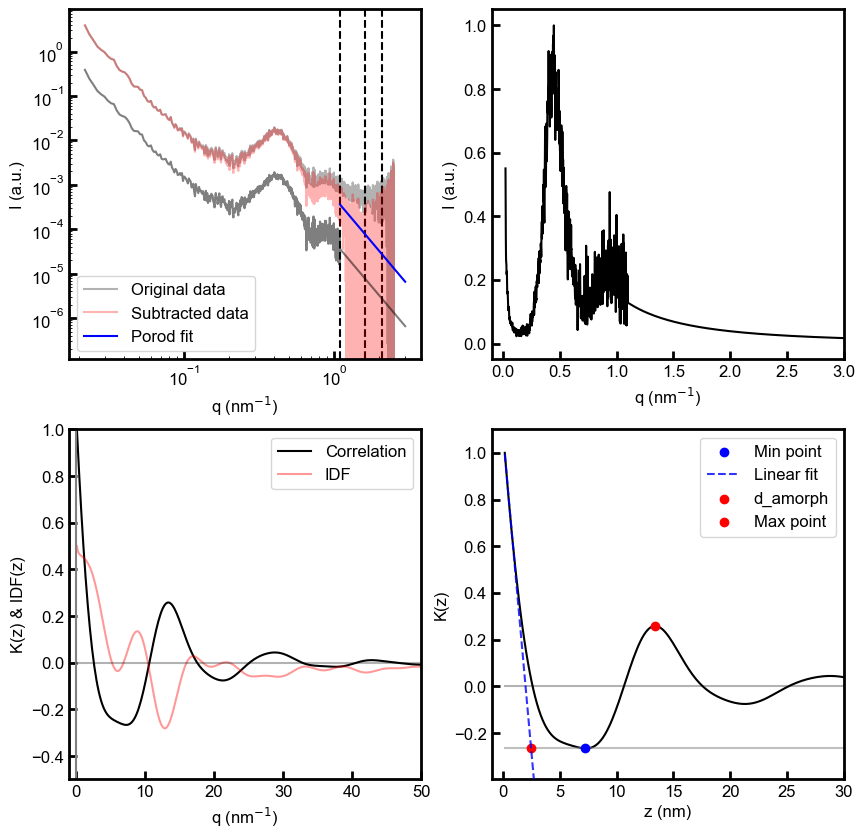

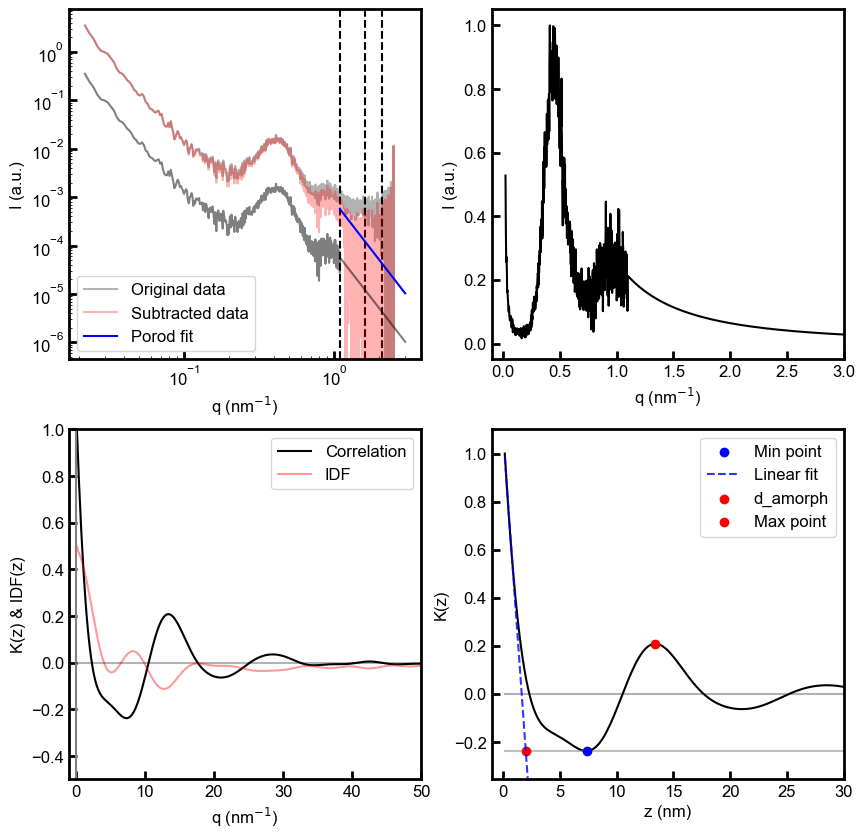

In [25]:
Lp = []
d_cr = []

Corr_1 = []
z_1 = []

Corr_2 = []
z_2 = []

for i in range(32):
    indexes = [i for i in range(3 * i, 3 * i + 3)]
    q, I = average(Exp, indexes)
    if i < 26:
        if i < 5:
            results = analyze_saxs_data_q_I(q, I, limits=[0., 1.1, 1.62, 2.1], factor=2, porod_const=1, sigma=0, lin1=0, lin2=1, plot=True)
            Corr_1 = results['correlation']
            z_1 = results['z']
            corr_funcs.append({'z':results['z'], 'K':results['correlation']})
            
        else:
            results = analyze_saxs_data_q_I(q, I, limits=[0., 1.1, 1.62, 2.1], factor=2, porod_const=1, sigma=0, lin1=0, lin2=1, plot=False)
            corr_funcs.append({'z':results['z'], 'K':results['correlation']})
    else:
        results = analyze_saxs_data_q_I(q, I, limits=[0.0, 0.64, 1.5, 2.1], factor=2, porod_const=1, sigma=0, lin1=2, lin2=5, plot=False)
        corr_funcs.append({'z':results['z'], 'K':results['correlation']})
        if i == 31:
            Corr_2 = results['correlation']
            corr_funcs.append({'z':results['z'], 'K':results['correlation']})
            z_2 = results['z']
        
    d_cr.append(results['d_crystalline'])
    Lp.append(results['long_period'])



(0.0, 20.0)

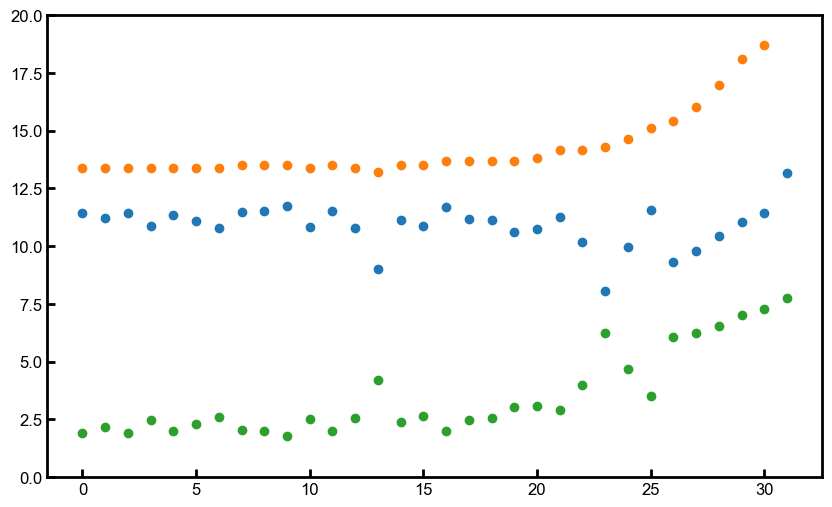

In [467]:
Lp = np.array(Lp)
d_cr = np.array(d_cr)

plt.scatter(range(32), d_cr)
plt.scatter(range(32), Lp)
plt.scatter(range(32), Lp-d_cr)

plt.ylim(0, 20)

In [443]:
# Ваш массив Time_exp
Time_exp = np.arange(32) * 3 * 1.9

# Для каждого значения Time_exp ищем ближайшее в time и берем T
T_exp = []
for t_target in Time_exp:
    pos = np.argmin(np.abs(time - t_target))
    T_exp.append(T[pos])

T_exp = np.array(T_exp)

# Проверка
for i in range(5):
    print(f"Time_exp[{i}] = {Time_exp[i]:.2f} -> T_exp = {T_exp[i]:.2f}°C")

Time_exp[0] = 0.00 -> T_exp = 23.99°C
Time_exp[1] = 5.70 -> T_exp = 25.18°C
Time_exp[2] = 11.40 -> T_exp = 25.85°C
Time_exp[3] = 17.10 -> T_exp = 26.28°C
Time_exp[4] = 22.80 -> T_exp = 26.50°C


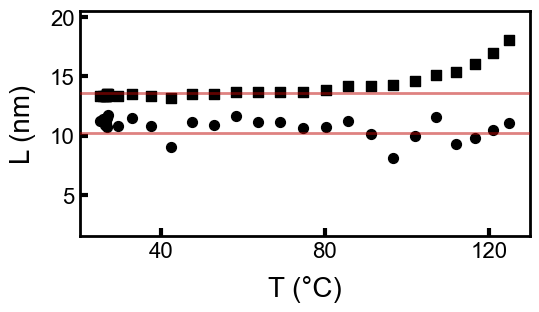

In [474]:
# ===================== СТИЛЬ ДЛЯ ПУБЛИКАЦИИ =====================
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 2
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['ytick.major.width'] = 2
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['ytick.major.size'] = 6
# =================================================================

fig, ax = plt.subplots(1, 1, figsize=(6, 3))
ax.set_position([0.15, 0.15, 0.75, 0.75])

Lp = np.array(Lp)
d_cr = np.array(d_cr)

ax.scatter(T_exp[1:-2], Lp[1:-2], s=50, marker='s', color='black')
ax.scatter(T_exp[1:-2], d_cr[1:-2], s=50, marker='o', color='black')

ax.axhline(y=10.18, color='#bf0603', linewidth=2, zorder=10, alpha=0.5)
ax.axhline(y=13.57, color='#bf0603', linewidth=2, zorder=10, alpha=0.5)

ax.set_ylim(1.5, 20.5)

ax.xaxis.set_minor_locator(ticker.NullLocator())
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.xaxis.get_major_formatter().set_scientific(False)

ax.set_ylabel('L (nm)', fontname='Arial', fontsize=20, labelpad=10)
ax.set_xlabel('T (°C)', fontname='Arial', fontsize=20, labelpad=10)

ax.set_xticks([40, 80, 120])

ax.tick_params(axis='both', which='major', labelsize=16, length=6, width=3)
ax.tick_params(axis='both', which='minor', length=3, width=2)

ax.set_position([0.15, 0.15, 0.75, 0.75])
plt.savefig(r'E:\C390\Figures\Fig_heat_b.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

# **Linear PE**

In [36]:
def analyze_saxs_data_q_I(q,I , limits=None, factor=2, porod_const=1.2, sigma=0.0, lin1=1, lin2=2):

    
    # Default limits if not provided
    if limits is None:
        limits = [0.1, 0.95, 1.6, 2.2]
    
    # Create figure and axes
    fig, axes = plt.subplots(2, 2, figsize=(10, 10))
    ax1 = axes[0][0]
    ax2 = axes[0][1]
    ax3 = axes[1][0]
    ax4 = axes[1][1]
    
    # Load data
    
    # Add vertical lines at limits
    for lim in limits:
        ax1.axvline(x=lim, color='black', linestyle='--')
    
    # Plot original data
    ax1.loglog(q, I, color='black', alpha=0.3, label='Original data')
    
    # Porod fitting
    mask_for_porod = (q > limits[-2]) & (q < limits[-1])
    const, P = find_porod_A(q[mask_for_porod], I[mask_for_porod])
    I_sub = I - const
    
    ax1.loglog(q, I_sub, color='r', alpha=0.3, label='Subtracted data')
    
    # Generate Porod fit
    x_porod = np.linspace(limits[1], 40, 2000)
    Ampl = I_sub[q < limits[1]][-1] * q[q < limits[1]][-1] ** 4
    y_porod = porod_const * smeared_porod(x_porod, Ampl, sigma)
    ax1.plot(x_porod[x_porod < 3], y_porod[x_porod < 3], color='blue', label='Porod fit')
    
    # Combine main data with Porod fit
    mask_main = (q > limits[0]) & (q < limits[1])
    res_q = np.concatenate([q[mask_main], x_porod])
    res_I = np.concatenate([I_sub[mask_main], y_porod])
    
    ax1.plot(res_q[res_q < 3], res_I[res_q < 3] / 10, color='black', alpha=0.5)
    ax1.set_xlabel('q (nm$^{-1}$)')
    ax1.set_ylabel('I (a.u.)')
    ax1.legend()
    
    # Lorenz correction
    X_lorenz, Y_lorenz = Lorenz(res_q, res_I, factor)
    ax2.plot(X_lorenz, Y_lorenz / max(Y_lorenz), color='black')
    ax2.set_xlim(-0.1, 3)
    ax2.set_xlabel('q (nm$^{-1}$)')
    ax2.set_ylabel('I (a.u.)')
    
    # Correlation function
    dz = 2 * np.pi / max(X_lorenz)
    z = np.linspace(dz, 50, int(50 / dz))
    Corr = K(X_lorenz, Y_lorenz, z)
    Corr /= max(Corr)
    
    # IDF calculation
    idf = K(X_lorenz, Y_lorenz * X_lorenz ** 2, z)
    idf /= 2 * max(-idf)
    
    # Plot correlation and IDF
    ax3.plot(z, Corr, color='black', label='Correlation')
    ax3.plot(z, -idf, color='r', alpha=0.4, label='IDF')
    ax3.set_xlim(-1, 50)
    ax3.set_ylim(-0.5, 1)
    ax3.axvline(x=0, color='grey')
    ax3.plot(z, z * 0, color='black', alpha=0.3)
    ax3.set_xlabel('q (nm$^{-1}$)')
    ax3.set_ylabel('K(z) & IDF(z)')
    ax3.legend()
    
    # Detailed correlation analysis
    ax4.plot(z, Corr, color='black')
    ax4.plot(z, z * 0, color='black', alpha=0.3)
    ax4.set_xlim(-1, 30)
    ax4.set_ylim(-0.5, 1.1)
    
    # Find minima and maxima in specified range
    mask_corr = (z > 4) & (z < 15)
    point_1 = min(Corr[mask_corr])  # minimum in the range
    point_2 = max(Corr[(z>10)&(z<25)])  # maximum in the range

    ax4.set_ylim(1.5 * point_1, 1.1)
    
    
    # Mark minimum point
    ax4.scatter(z[Corr == point_1], point_1, zorder=100, color='b', label='Min point')
    ax4.plot(z, point_1 + np.zeros(len(z)), color='grey', alpha=0.5)
    
    # Linear fit for small z
    mask_linear = (z < lin2 ) & (z > lin1)
    def linear(x, a, b):
        return a * x + b
    
    popt, cov = curve_fit(linear, z[mask_linear], Corr[mask_linear])
    ax4.plot(z, linear(z, *popt), color='b', alpha=0.8, zorder=300, linestyle='--', label='Linear fit')
    
    # Calculate amorphous domain size
    d_amorph = (point_1 - popt[1]) / popt[0]
    ax4.scatter(d_amorph, point_1, color='r', label='d_amorph', zorder=100)
    
    # Mark maximum point
    ax4.scatter(z[Corr == point_2], point_2, zorder=100, color='r', label='Max point')
    lp = z[Corr == point_2][0]
    
    ax4.set_xlabel('z (nm)')
    ax4.set_ylabel('K(z)')
    ax4.legend()
    
    # Calculate results
    d_cr = lp - d_amorph
    ratio = d_cr / lp
    
    # Print results
    print(f'D_amorphous = {d_amorph:.3f}')
    print(f'D_crystalline = {d_cr:.3f}')
    print(f'Long period = {lp:.3f}')
    print(f'Crystalline fraction = {ratio:.3f}')
    
    # Return results
    results = {
        'fig': fig,
        'axes': axes,
        'd_amorphous': d_amorph,
        'd_crystalline': d_cr,
        'long_period': lp,
        'crystalline_fraction': ratio,
        'q': q,
        'I': I,
        'I_subtracted': I_sub,
        'correlation': Corr,
        'idf': idf,
        'z': z,
        'porod_constants': (const, P, Ampl)
    }
    
    return results

In [37]:
path = r"E:\PE ETH Theo Tervoort\SC5671\ef20_eiger2_00068_00_ave.h5"

Exp = ID02_experiment(path)
q_before, I_before_1 = Exp.get_1d_data(0)
path = r"E:\PE ETH Theo Tervoort\SC5671\ef20_eiger2_00069_00_ave.h5"

Exp = ID02_experiment(path)
q_before, I_before_2 = Exp.get_1d_data(0)
I_before = (I_before_1 + I_before_2 )/ 2

D_amorphous = 2.169
D_crystalline = 8.994
Long period = 11.163
Crystalline fraction = 0.806


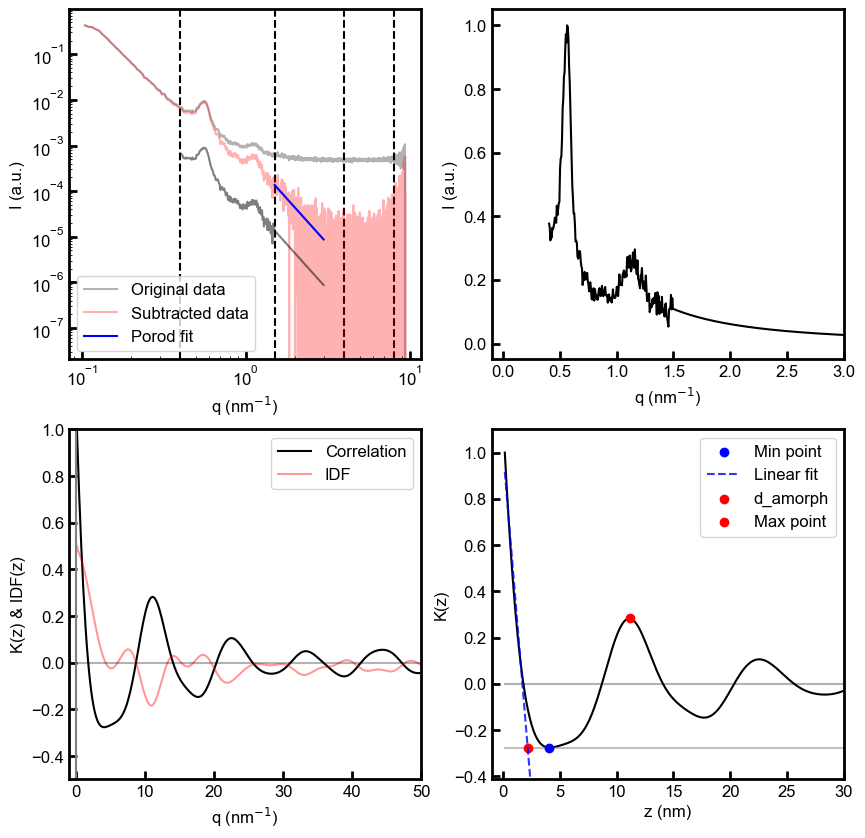

In [38]:
q, I = Exp.get_1d_data(0)

results1 = analyze_saxs_data_q_I(q_before, I_before, limits=[0.4, 1.5, 4, 8], factor=2, porod_const=1, sigma=0, lin1=0, lin2=2)

In [39]:
path = r"E:\PE ETH Theo Tervoort\SC5671\ef20_eiger2_00070_00_ave.h5"

Exp = ID02_experiment(path)

def average(Exp, index):
    q, res = Exp.get_1d_data()
    res *= 0
    
    for i in index:
        q, I = Exp.get_1d_data(i)
        res += I
    res /= len(index)
    return q, res

D_amorphous = 5.135
D_crystalline = 13.890
Long period = 19.025
Crystalline fraction = 0.730


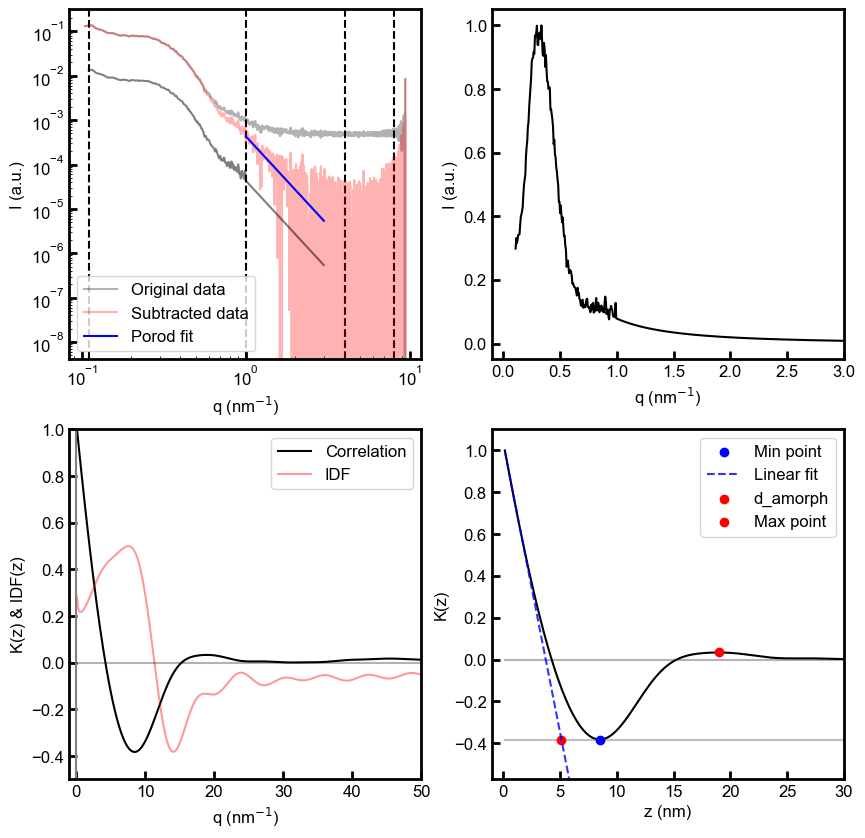

In [56]:
q, I = average(Exp, [226, 227, 228, 229])
results2 = analyze_saxs_data_q_I(q, I, limits=[0.11, 1., 4, 8], factor=2, porod_const=1, sigma=0, lin1=0, lin2=2)

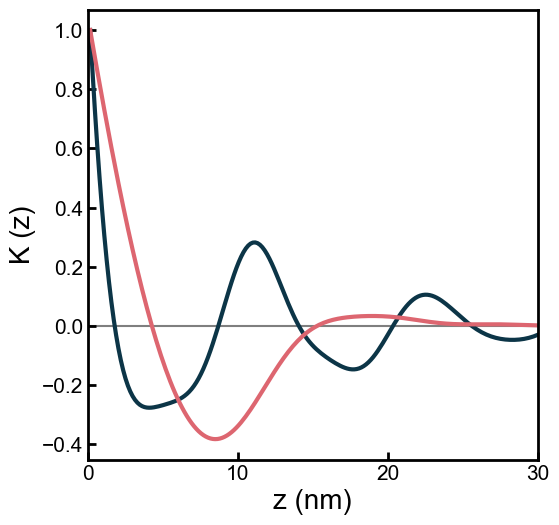

In [57]:
# ===================== СТИЛЬ ДЛЯ ПУБЛИКАЦИИ =====================
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 2
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['ytick.major.width'] = 2
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['ytick.major.size'] = 6
# =================================================================

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.set_position([0.15, 0.15, 0.75, 0.75])

plt.plot(results1['z'], results1['correlation'], color='#0c3547', linewidth=3)
plt.plot(results2['z'], results2['correlation'], color='#dd6670', linewidth=3)
plt.plot(results2['z'], results2['z']*0, color='black', alpha=0.5, zorder=0)

ax.set_xlim(0, 30)
# ax.set_ylim(5e-6, 2e2)

# НАСТРОЙКА ТИКОВ: ТОЛЬКО 0.1 И 1 (без лишних)
# Отключаем все автоматические тики
ax.xaxis.set_major_locator(ticker.FixedLocator([0, 10, 20, 30]))
ax.xaxis.set_minor_locator(ticker.NullLocator())  # убираем малые тики

# Формат подписей: десятичные числа, без научного формата
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.xaxis.get_major_formatter().set_scientific(False)

# Подписи осей (Arial, размер 20 как в вашем примере)
ax.set_xlabel('z (nm)', fontname='Arial', fontsize=20)
ax.set_ylabel('K (z)', fontname='Arial', fontsize=20)

# Легенда
# ax.legend(fontsize=10, loc=2, frameon=False)
# ax.set_xticks([0.2, 1, 2])
# Размер цифр на тиках
ax.tick_params(axis='both', which='major', labelsize=15, length=6, width=2)
ax.tick_params(axis='both', which='minor', length=3, width=1) 

plt.savefig(r'E:\C390\Figures\Fig3_b.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

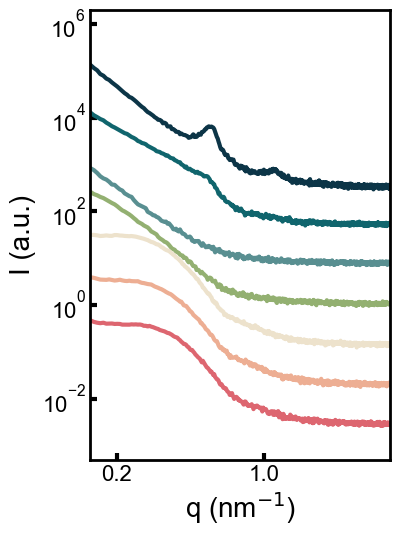

In [418]:
# ===================== СТИЛЬ ДЛЯ ПУБЛИКАЦИИ =====================
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 2
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['ytick.major.width'] = 2
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['ytick.major.size'] = 6
# =================================================================

fig, ax = plt.subplots(1, 1, figsize=(4, 6))
ax.set_position([0.15, 0.15, 0.75, 0.75])

scale = 3
linewidth = 3

path = r"E:\PE ETH Theo Tervoort\SC5671\ef20_eiger2_00070_00_ave.h5"
Exp = ID02_experiment(path)

scale = 7
linewidth = 3
palette = ["#0c3547","#10656d","#598f91","#93b071","#ede2cc","#edae93","#dd6670"]
# ["#f23e17","#e2644e","#cf7e72","#b99393","#9da5b3","#76b5d2","#28c3f1"]
    # ["#011a4d","#255d8d","#499fcd","#86bca4","#c2d87a","#fece52","#feb94a"]

q, I = average(Exp, [i for i in range(0, 10)])
plt.plot(q, I * scale ** 1 * 1e5, color=palette[0], linewidth=linewidth)

q, I = average(Exp, [i for i in range(100, 110)])
plt.plot(q, I / scale ** 0 * 1e5, color=palette[1], linewidth=linewidth)

q, I = average(Exp, [i for i in range(120, 130)])
plt.plot(q, I / scale ** 1 * 1e5, color=palette[2], linewidth=linewidth)

q, I = average(Exp, [i for i in range(170, 180)])
plt.plot(q, I / scale ** 2 * 1e5, color=palette[3], linewidth=linewidth)

q, I = average(Exp, [i for i in range(200, 210)])
plt.plot(q, I / scale ** 3 * 1e5, color=palette[4], linewidth=linewidth)


q, I = average(Exp, [i for i in range(220, 229)])
plt.plot(q, I / scale ** 4 * 1e5, color=palette[5], linewidth=linewidth)

path = r"E:\PE ETH Theo Tervoort\SC5671\ef20_eiger2_00071_00_ave.h5"
Exp = ID02_experiment(path)

q, I = average(Exp, [i for i in range(220, 229)])
plt.plot(q, I / scale ** 5 * 1e5, color=palette[6], linewidth=linewidth)

# ===================== НАСТРОЙКИ ОСЕЙ =====================
ax.set_xlim(0.15, 4)
ax.set_ylim(5e-4, 2e6)

# Логарифмическая шкала
ax.set_xscale('log')
ax.set_yscale('log')

# НАСТРОЙКА ТИКОВ: ТОЛЬКО 0.1 И 1 (без лишних)
# Отключаем все автоматические тики
ax.xaxis.set_major_locator(ticker.FixedLocator([0.1, 1]))
ax.xaxis.set_minor_locator(ticker.NullLocator())  # убираем малые тики

# Формат подписей: десятичные числа, без научного формата
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.xaxis.get_major_formatter().set_scientific(False)

# Подписи осей (Arial, размер 20 как в вашем примере)
ax.set_xlabel('q (nm$^{-1}$)', fontname='Arial', fontsize=20)
ax.set_ylabel('I (a.u.)', fontname='Arial', fontsize=20)

# Легенда
# ax.legend(fontsize=10, loc=2, frameon=False)
ax.set_xticks([0.2, 1])
# Размер цифр на тиках
ax.tick_params(axis="both", which='major', direction="in", width=3, length=5, labelsize=16)
ax.tick_params(axis="both", which='minor', direction="in", width=2, length=3, labelsize=16)

plt.savefig(r'E:\C390\Figures\Fig3_a.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

# ...

D_amorphous = 4.947
D_crystalline = 8.574
Long period = 13.522
Crystalline fraction = 0.634

D_amorphous = 4.678
D_crystalline = 9.473
Long period = 14.151
Crystalline fraction = 0.669

D_amorphous = 4.918
D_crystalline = 9.390
Long period = 14.308
Crystalline fraction = 0.656

D_amorphous = 5.331
D_crystalline = 9.291
Long period = 14.623
Crystalline fraction = 0.635

D_amorphous = 5.774
D_crystalline = 9.320
Long period = 15.094
Crystalline fraction = 0.617

D_amorphous = 6.054
D_crystalline = 9.355
Long period = 15.409
Crystalline fraction = 0.607



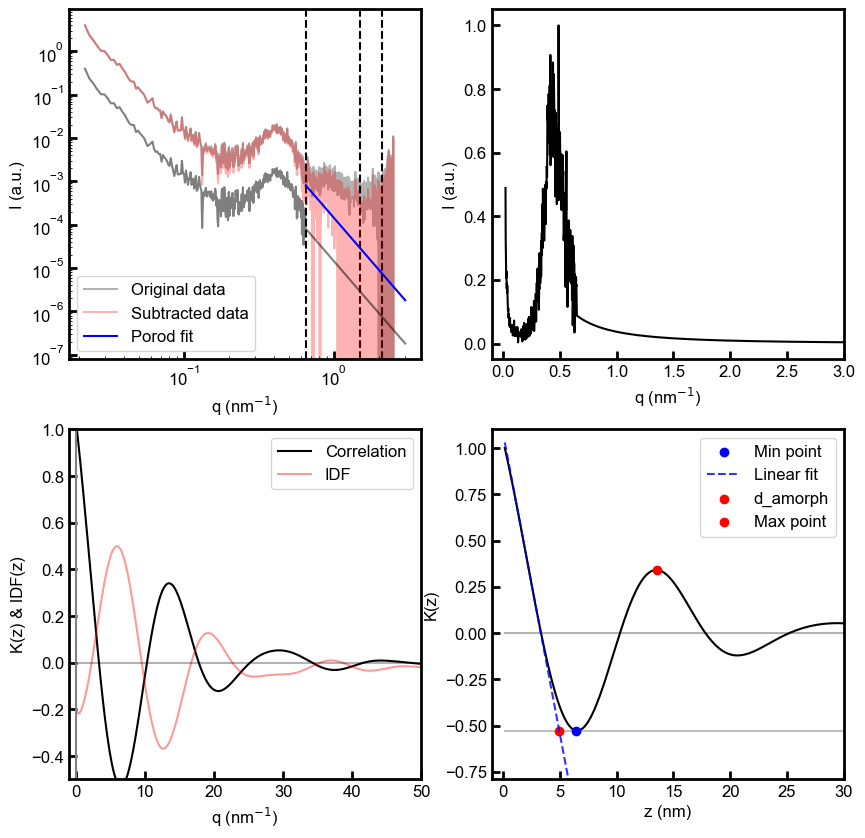

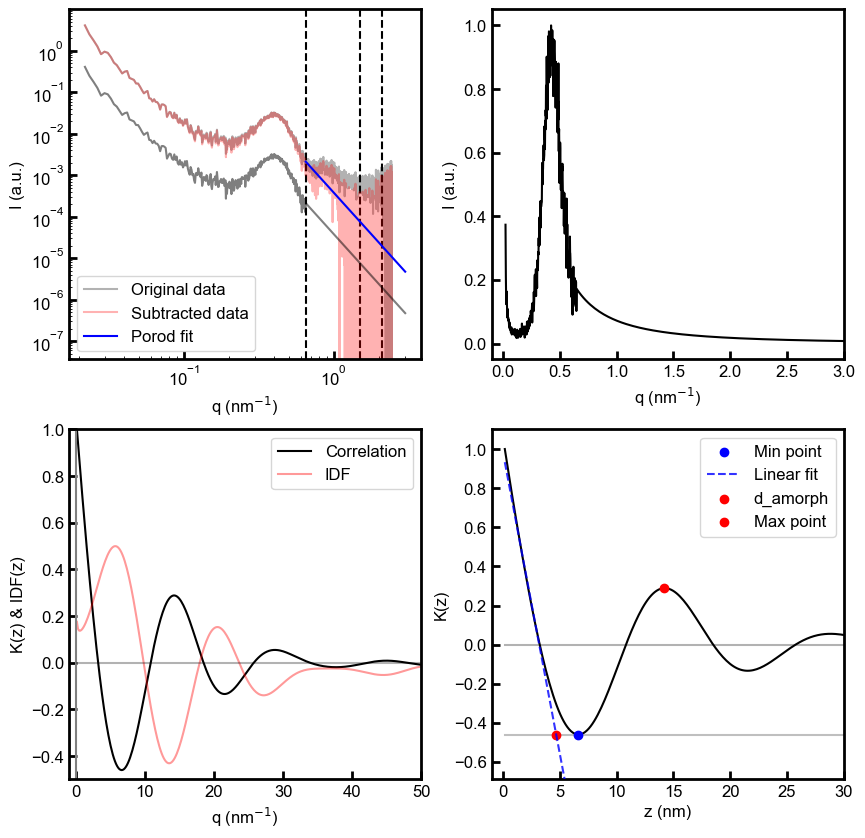

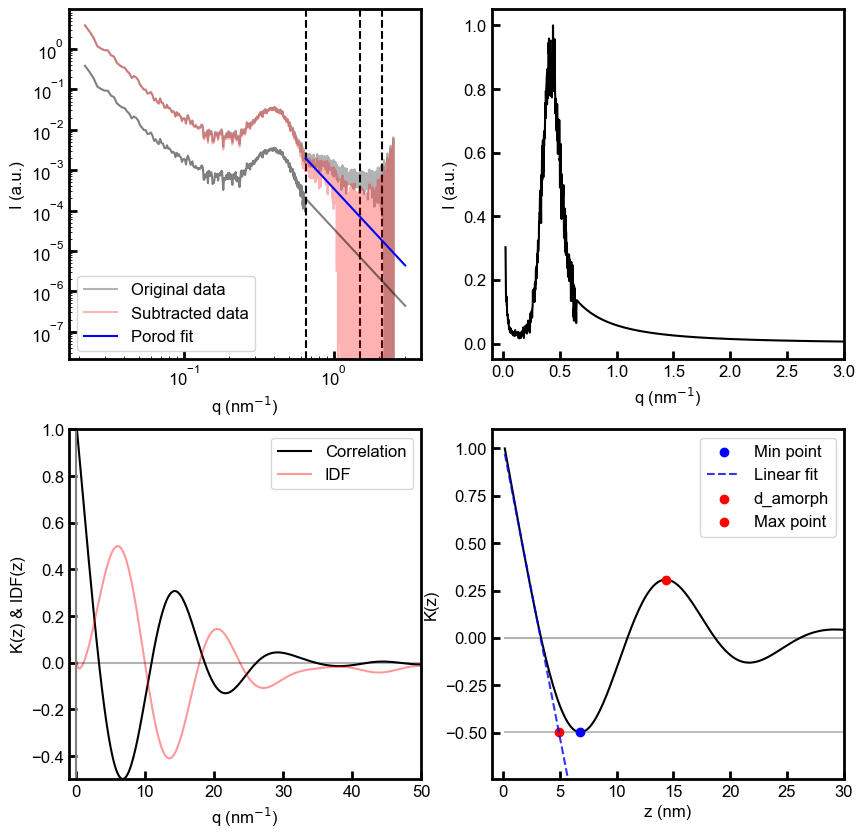

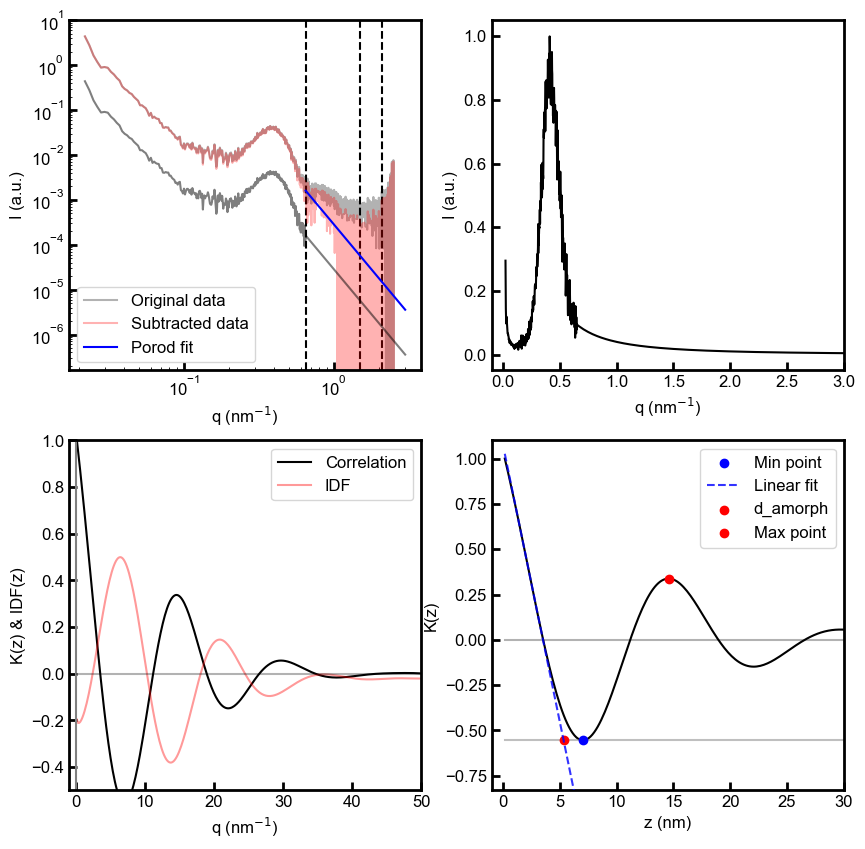

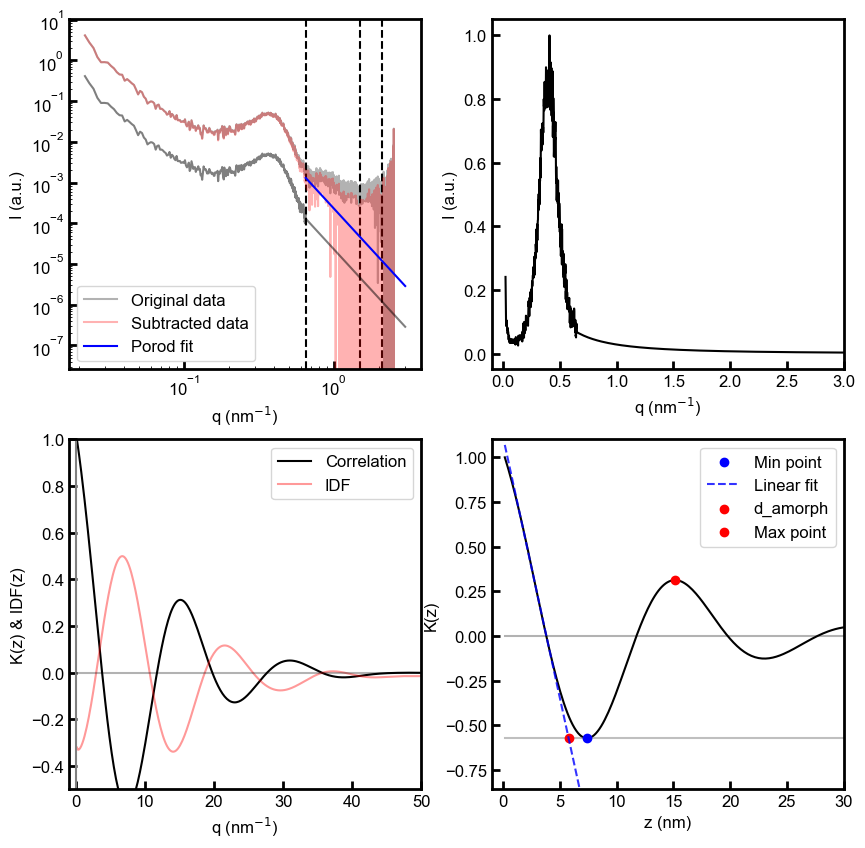

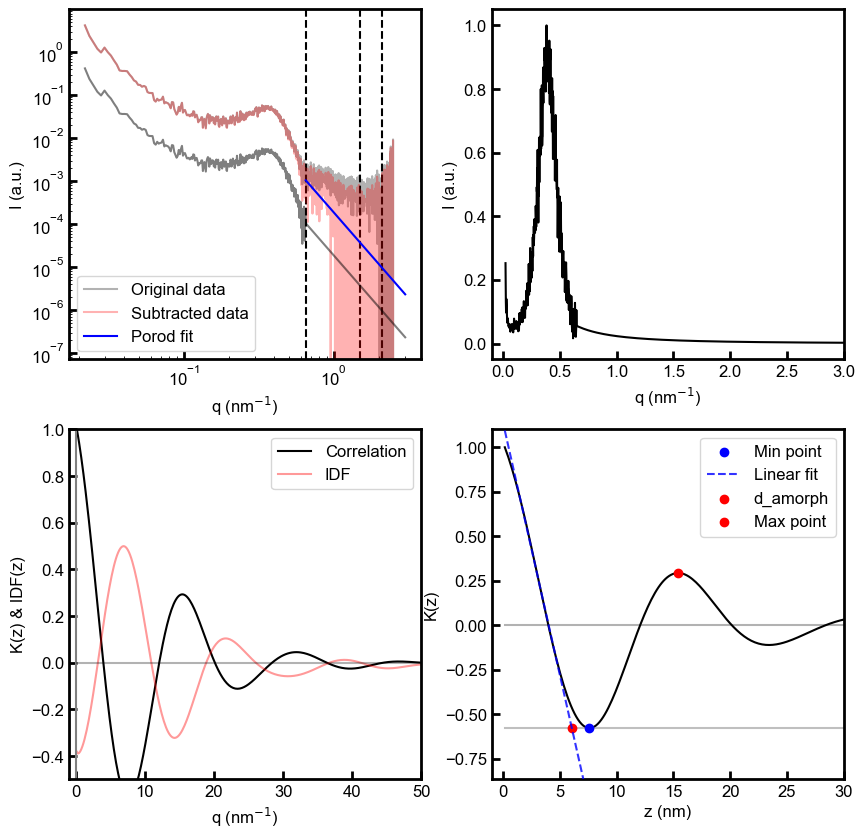

In [194]:
results_list = []

# 1000 K/s (indexes 0-10)

indexes = [i for i in range(10, 12)]
q, I = average(Exp, indexes)
results = analyze_saxs_data_q_I(q, I, limits=[0.0, 0.65, 1.5, 2.1], factor=2, porod_const=1, sigma=0, lin1=1, lin2=4)
results_list.append({'temperature': 1000, 'd_am': results['d_amorphous'], 'd_cr': results['d_crystalline'], 'Lp': results['long_period'], 'Xc': results['crystalline_fraction']})
print()


indexes = [i for i in range(62, 64)]
q, I = average(Exp, indexes)
results = analyze_saxs_data_q_I(q, I, limits=[0.0, 0.65, 1.5, 2.1], factor=2, porod_const=1, sigma=0, lin1=1, lin2=4)
results_list.append({'temperature': 1000, 'd_am': results['d_amorphous'], 'd_cr': results['d_crystalline'], 'Lp': results['long_period'], 'Xc': results['crystalline_fraction']})
print()

indexes = [i for i in range(66, 68)]
q, I = average(Exp, indexes)
results = analyze_saxs_data_q_I(q, I, limits=[0.0, 0.65, 1.5, 2.1], factor=2, porod_const=1, sigma=0, lin1=1, lin2=4)
results_list.append({'temperature': 1000, 'd_am': results['d_amorphous'], 'd_cr': results['d_crystalline'], 'Lp': results['long_period'], 'Xc': results['crystalline_fraction']})
print()

indexes = [i for i in range(70, 72)]
q, I = average(Exp, indexes)
results = analyze_saxs_data_q_I(q, I, limits=[0.0, 0.65, 1.5, 2.1], factor=2, porod_const=1, sigma=0, lin1=1, lin2=4)
results_list.append({'temperature': 1000, 'd_am': results['d_amorphous'], 'd_cr': results['d_crystalline'], 'Lp': results['long_period'], 'Xc': results['crystalline_fraction']})
print()


indexes = [i for i in range(76, 78)]
q, I = average(Exp, indexes)
results = analyze_saxs_data_q_I(q, I, limits=[0.0, 0.65, 1.5, 2.1], factor=2, porod_const=1, sigma=0, lin1=1, lin2=4)
results_list.append({'temperature': 1000, 'd_am': results['d_amorphous'], 'd_cr': results['d_crystalline'], 'Lp': results['long_period'], 'Xc': results['crystalline_fraction']})
print()

indexes = [i for i in range(79, 80)]
q, I = average(Exp, indexes)
results = analyze_saxs_data_q_I(q, I, limits=[0.0, 0.65, 1.5, 2.1], factor=2, porod_const=1, sigma=0, lin1=1, lin2=4)
results_list.append({'temperature': 1000, 'd_am': results['d_amorphous'], 'd_cr': results['d_crystalline'], 'Lp': results['long_period'], 'Xc': results['crystalline_fraction']})
print()

# indexes = [i for i in range(80, 83)]
# q, I = average(Exp, indexes)
# results = analyze_saxs_data_q_I(q, I, limits=[0.0, 0.65, 1.5, 2.1], factor=2, porod_const=1, sigma=0, lin1=0, lin2=4)
# results_list.append({'temperature': 1000, 'd_am': results['d_amorphous'], 'd_cr': results['d_crystalline'], 'Lp': results['long_period'], 'Xc': results['crystalline_fraction']})
# print()

# indexes = [i for i in range(83, 86)]
# q, I = average(Exp, indexes)
# results = analyze_saxs_data_q_I(q, I, limits=[0.0, 0.65, 1.7, 2.1], factor=2, porod_const=1., sigma=0, lin1=1, lin2=4)
# results_list.append({'temperature': 1000, 'd_am': results['d_amorphous'], 'd_cr': results['d_crystalline'], 'Lp': results['long_period'], 'Xc': results['crystalline_fraction']})
# print()

# indexes = [i for i in range(86, 89)]
# q, I = average(Exp, indexes)
# results = analyze_saxs_data_q_I(q, I, limits=[0.0, 0.65, 1.7, 2.1], factor=2, porod_const=1., sigma=0, lin1=1, lin2=4)
# results_list.append({'temperature': 1000, 'd_am': results['d_amorphous'], 'd_cr': results['d_crystalline'], 'Lp': results['long_period'], 'Xc': results['crystalline_fraction']})
# print()

# indexes = [i for i in range(89, 92)]
# q, I = average(Exp, indexes)
# results = analyze_saxs_data_q_I(q, I, limits=[0.0, 0.65, 1.7, 2.1], factor=2, porod_const=1, sigma=0, lin1=1, lin2=4)
# results_list.append({'temperature': 1000, 'd_am': results['d_amorphous'], 'd_cr': results['d_crystalline'], 'Lp': results['long_period'], 'Xc': results['crystalline_fraction']})
# print()

# indexes = [i for i in range(92, 94)]
# q, I = average(Exp, indexes)
# results = analyze_saxs_data_q_I(q, I, limits=[0.0, 0.65, 1.7, 2.1], factor=2, porod_const=1, sigma=0, lin1=1, lin2=6)
# results_list.append({'temperature': 1000, 'd_am': results['d_amorphous'], 'd_cr': results['d_crystalline'], 'Lp': results['long_period'], 'Xc': results['crystalline_fraction']})
# print()


# Корреляционные функции для 0-90
# heating_results = []
# for temp_idx in range(0, 91):
#     indexes = [temp_idx]
#     q, I = average(Exp, indexes)
#     I_smooth = savgol_filter(I, window_length=window, polyorder=3)
#     results = analyze_saxs_data_q_I(q, I_smooth, limits=[0.15, 1.1, 1.7, 2.2], factor=2, porod_const=1., sigma=0, lin1=1, lin2=2, show_plots=False)
#     heating_results.append({
#         'temperature': temp_idx,
#         'd_am': results['d_amorphous'],
#         'd_cr': results['d_crystalline'],
#         'Lp': results['long_period'],
#         'Xc': results['crystalline_fraction'],
#         'correlation': results['correlation'],
#         'z': results['z']
#     })

df_heating = pd.DataFrame(heating_results)

In [424]:
48.8 / 13.599

3.5884991543495843

In [435]:
48.8 / 15.1

3.2317880794701987

### 294

D_a = 3.00147782331672
D_cr = 9.419790417094632
Lp = 12.42126824041135
0.7583597934426928


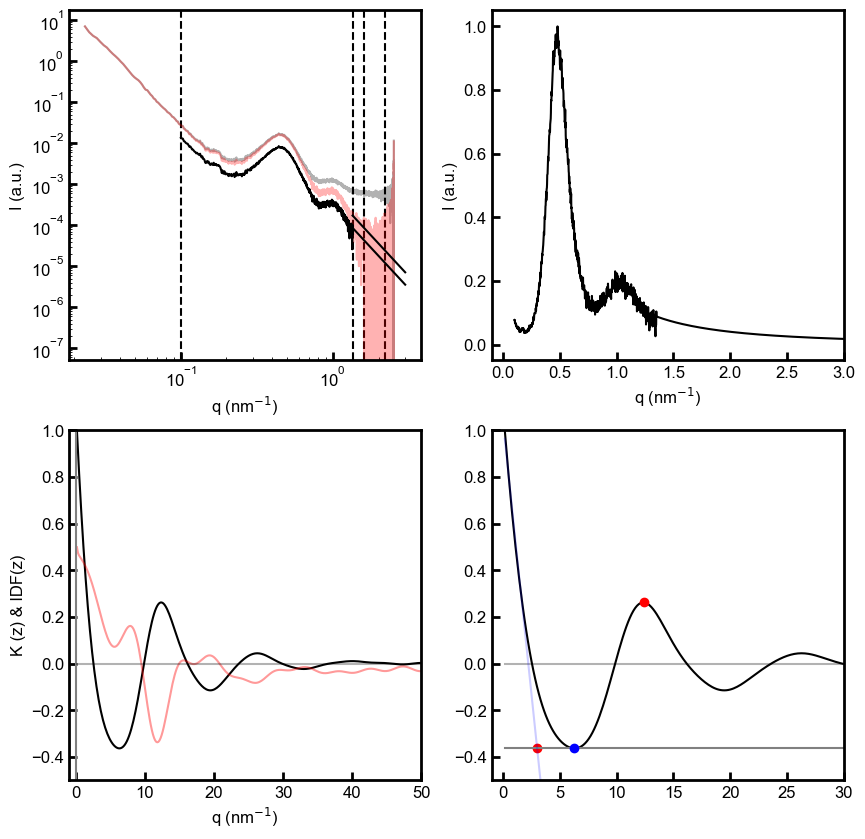

In [255]:
fig, axes = plt.subplots(2,2, figsize=(10,10))
ax1 = axes[0][0]
ax2 = axes[0][1]
ax3 = axes[1][0]
ax4 = axes[1][1]

path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00294_00_00001_av.dat"
df = pd.read_csv(path, skiprows=2, names=['q', 'I', 'err'], sep='\t')

q, I = np.array(df['q']), np.array(df['I'])

limits = [0.1, 1.35, 1.6, 2.2]
factor = 2
Porod_Const = 0.85

for lim in limits:
    ax1.axvline(x=lim, color='black', linestyle='--')


ax1.loglog(q, I, color='black', alpha=0.3)

mask_for_porod = (q > limits[-2]) * (q < limits[-1])

const, P = find_porod_A(q[mask_for_porod], I[mask_for_porod])
I_sub = I - const
ax1.loglog(q, I_sub, color='r', alpha=0.3)
x_porod = np.linspace(limits[1], 40, 2000)

sigma = 0.
Ampl = I_sub[q < limits[1]][-1] * q[q<limits[1]][-1] ** 4
y_porod = Porod_Const * smeared_porod(x_porod, Ampl, sigma)  
ax1.plot(x_porod[x_porod<3], y_porod[x_porod<3], color='black')

mask_main = (q > limits[0]) & (q < limits[1])
res_q = np.concatenate([q[mask_main], x_porod]) 
res_I = np.concatenate([I_sub[mask_main], y_porod]) 

ax1.plot(res_q[res_q<3], res_I[res_q<3] / 2, color='black')

X_lorenz, Y_lorenz = Lorenz(res_q, res_I, factor)
ax2.plot(X_lorenz, Y_lorenz / max(Y_lorenz), color='black')
# ax2.plot(X_lorenz, Y_lorenz * X_lorenz ** 2 / max(Y_lorenz * X_lorenz ** 2), color='black')
ax2.set_xlim(-0.1, 3)


dz = 2 * np.pi / max(X_lorenz)
z = np.linspace(dz, 50,  int(50 / dz))
Corr = K(X_lorenz,Y_lorenz, z)
Corr /= max(Corr)
ax3.plot(z, Corr, color='black')


idf = K(X_lorenz, Y_lorenz * X_lorenz ** 2, z)
idf /= 2 * max(-idf)
ax3.plot(z, -idf,  color='r', alpha=0.4)

ax3.set_xlim(-1, 50)
ax3.set_ylim(-.5, 1)
ax3.axvline(x=0, color='grey')
# idf = IDF(z, Corr)
# ax3.plot(z, idf, color='r')
ax3.plot(z, z*0, color='black', alpha=0.3)

ax1.set_xlabel('q (nm$^{-1}$)')
ax2.set_xlabel('q (nm$^{-1}$)')
ax3.set_xlabel('q (nm$^{-1}$)')
ax1.set_ylabel('I (a.u.)')
ax2.set_ylabel('I (a.u.)')
ax3.set_ylabel('K (z) & IDF(z)')

ax4.plot(z, Corr, color='black')
ax4.plot(z, z*0, color='black', alpha=0.3)
ax4.set_xlim(-1, 30)
ax4.set_ylim(-0.5, 1)


mask_corr = (z > 4) & (z < 20)
point_1 = min(Corr[mask_corr])
point_2 = max(Corr[mask_corr])
ax4.scatter(z[Corr == point_1], point_1, zorder=100, color='b')
ax4.plot(z, point_1 + np.zeros(len(z)), color='grey')
mask_linear = (z < 2)
popt, cov = curve_fit(linear, z[mask_linear], Corr[mask_linear])
ax4.plot(z, linear(z, *popt), color='b', alpha=0.2)
d_Amorph = (point_1 - popt[1]) / popt[0] 
ax4.scatter(d_Amorph, point_1,  color='r')

ax4.scatter(z[Corr == point_2], point_2, zorder=100, color='r')
Lp = z[Corr == point_2][0]


print('D_a =', d_Amorph)
print('D_cr =', Lp - d_Amorph)

print('Lp =', Lp)
print((Lp - d_Amorph) / Lp)

### 

#### 301

D_a = 2.775589397786502
D_cr = 15.463306771933551
Lp = 18.238896169720054
0.847820319170713


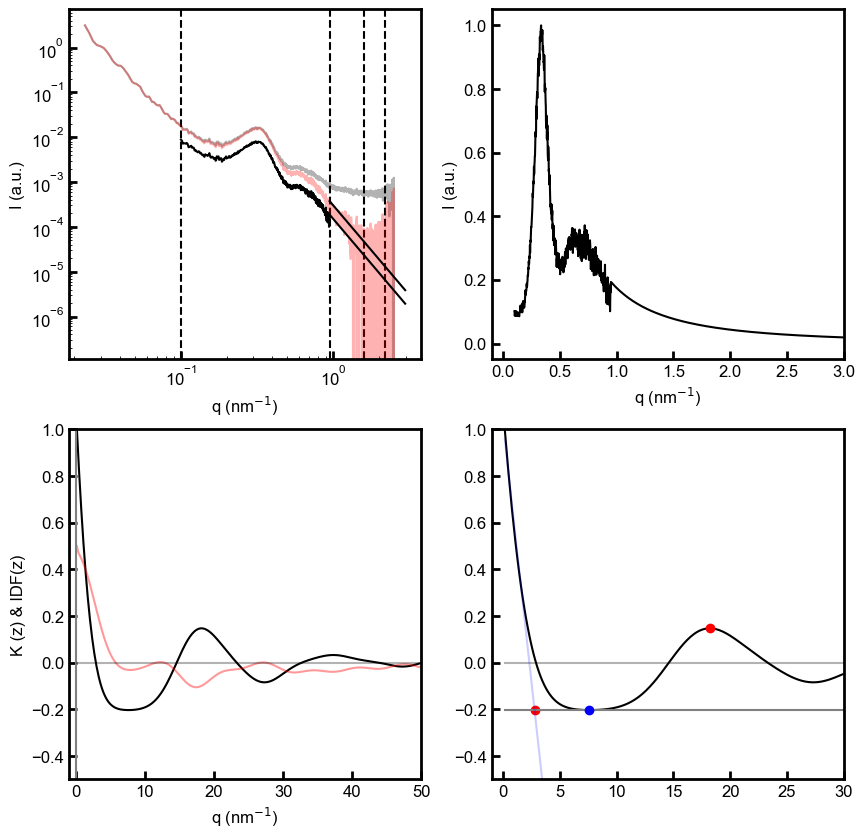

In [266]:
fig, axes = plt.subplots(2,2, figsize=(10,10))
ax1 = axes[0][0]
ax2 = axes[0][1]
ax3 = axes[1][0]
ax4 = axes[1][1]

path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00301_00_00001_av.dat"
df = pd.read_csv(path, skiprows=2, names=['q', 'I', 'err'], sep='\t')

q, I = np.array(df['q']), np.array(df['I'])

limits = [0.1, 0.95, 1.6, 2.2]
factor = 2
Porod_Const = 1.2

for lim in limits:
    ax1.axvline(x=lim, color='black', linestyle='--')


ax1.loglog(q, I, color='black', alpha=0.3)

mask_for_porod = (q > limits[-2]) * (q < limits[-1])

const, P = find_porod_A(q[mask_for_porod], I[mask_for_porod])
I_sub = I - const
ax1.loglog(q, I_sub, color='r', alpha=0.3)
x_porod = np.linspace(limits[1], 40, 2000)

sigma = 0.
Ampl = I_sub[q < limits[1]][-1] * q[q<limits[1]][-1] ** 4
y_porod = Porod_Const * smeared_porod(x_porod, Ampl, sigma)  
ax1.plot(x_porod[x_porod<3], y_porod[x_porod<3], color='black')

mask_main = (q > limits[0]) & (q < limits[1])
res_q = np.concatenate([q[mask_main], x_porod]) 
res_I = np.concatenate([I_sub[mask_main], y_porod]) 

ax1.plot(res_q[res_q<3], res_I[res_q<3] / 2, color='black')

X_lorenz, Y_lorenz = Lorenz(res_q, res_I, factor)
ax2.plot(X_lorenz, Y_lorenz / max(Y_lorenz), color='black')
# ax2.plot(X_lorenz, Y_lorenz * X_lorenz ** 2 / max(Y_lorenz * X_lorenz ** 2), color='black')
ax2.set_xlim(-0.1, 3)


dz = 2 * np.pi / max(X_lorenz)
z = np.linspace(dz, 50,  int(50 / dz))
Corr = K(X_lorenz,Y_lorenz, z)
Corr /= max(Corr)
ax3.plot(z, Corr, color='black')


idf = K(X_lorenz, Y_lorenz * X_lorenz ** 2, z)
idf /= 2 * max(-idf)
ax3.plot(z, -idf,  color='r', alpha=0.4)

ax3.set_xlim(-1, 50)
ax3.set_ylim(-.5, 1)
ax3.axvline(x=0, color='grey')
# idf = IDF(z, Corr)
# ax3.plot(z, idf, color='r')
ax3.plot(z, z*0, color='black', alpha=0.3)

ax1.set_xlabel('q (nm$^{-1}$)')
ax2.set_xlabel('q (nm$^{-1}$)')
ax3.set_xlabel('q (nm$^{-1}$)')
ax1.set_ylabel('I (a.u.)')
ax2.set_ylabel('I (a.u.)')
ax3.set_ylabel('K (z) & IDF(z)')

ax4.plot(z, Corr, color='black')
ax4.plot(z, z*0, color='black', alpha=0.3)
ax4.set_xlim(-1, 30)
ax4.set_ylim(-0.5, 1)


mask_corr = (z > 4) & (z < 25)
point_1 = min(Corr[mask_corr])
point_2 = max(Corr[mask_corr])
ax4.scatter(z[Corr == point_1], point_1, zorder=100, color='b')
ax4.plot(z, point_1 + np.zeros(len(z)), color='grey')
mask_linear = (z < 2)
popt, cov = curve_fit(linear, z[mask_linear], Corr[mask_linear])
ax4.plot(z, linear(z, *popt), color='b', alpha=0.2)
d_Amorph = (point_1 - popt[1]) / popt[0] 
ax4.scatter(d_Amorph, point_1,  color='r')

ax4.scatter(z[Corr == point_2], point_2, zorder=100, color='r')
Lp = z[Corr == point_2][0]


print('D_a =', d_Amorph)
print('D_cr =', Lp - d_Amorph)

print('Lp =', Lp)
print((Lp - d_Amorph) / Lp)


### 291

D_a = 4.893690361244077
D_cr = 16.80433592860548
Lp = 21.698026289849555
0.774463801643868


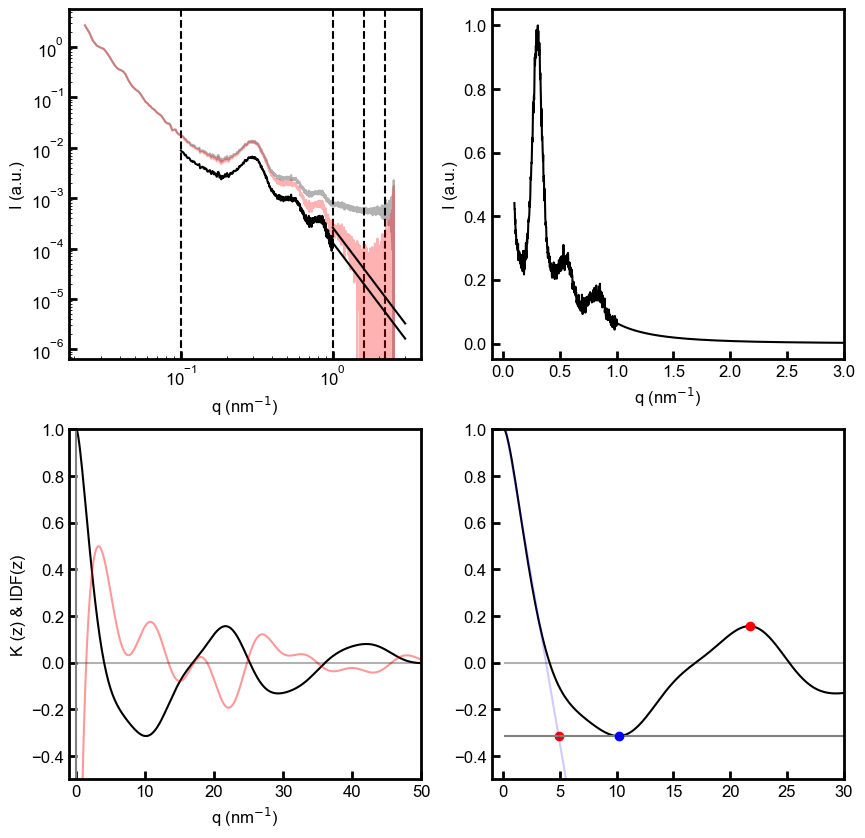

In [258]:
fig, axes = plt.subplots(2,2, figsize=(10,10))
ax1 = axes[0][0]
ax2 = axes[0][1]
ax3 = axes[1][0]
ax4 = axes[1][1]

path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00291_00_00001_av.dat"
df = pd.read_csv(path, skiprows=2, names=['q', 'I', 'err'], sep='\t')

q, I = np.array(df['q']), np.array(df['I'])

limits = [0.1, 1., 1.6, 2.2]
factor = 1.
Porod_Const = 0.85

for lim in limits:
    ax1.axvline(x=lim, color='black', linestyle='--')


ax1.loglog(q, I, color='black', alpha=0.3)

mask_for_porod = (q > limits[-2]) * (q < limits[-1])

const, P = find_porod_A(q[mask_for_porod], I[mask_for_porod])
I_sub = I - const
ax1.loglog(q, I_sub, color='r', alpha=0.3)
x_porod = np.linspace(limits[1], 40, 2000)

sigma = 0.
Ampl = I_sub[q < limits[1]][-1] * q[q<limits[1]][-1] ** 4
y_porod = Porod_Const * smeared_porod(x_porod, Ampl, sigma)  
ax1.plot(x_porod[x_porod<3], y_porod[x_porod<3], color='black')

mask_main = (q > limits[0]) & (q < limits[1])
res_q = np.concatenate([q[mask_main], x_porod]) 
res_I = np.concatenate([I_sub[mask_main], y_porod]) 

ax1.plot(res_q[res_q<3], res_I[res_q<3] / 2, color='black')

X_lorenz, Y_lorenz = Lorenz(res_q, res_I, factor)
ax2.plot(X_lorenz, Y_lorenz / max(Y_lorenz), color='black')
# ax2.plot(X_lorenz, Y_lorenz * X_lorenz ** 2 / max(Y_lorenz * X_lorenz ** 2), color='black')
ax2.set_xlim(-0.1, 3)


dz = 2 * np.pi / max(X_lorenz)
z = np.linspace(dz, 50,  int(50 / dz))
Corr = K(X_lorenz,Y_lorenz, z)
Corr /= max(Corr)
ax3.plot(z, Corr, color='black')


idf = K(X_lorenz, Y_lorenz * X_lorenz ** 2, z)
idf /= 2 * max(-idf)
ax3.plot(z, -idf,  color='r', alpha=0.4)

ax3.set_xlim(-1, 50)
ax3.set_ylim(-.5, 1)
ax3.axvline(x=0, color='grey')
# idf = IDF(z, Corr)
# ax3.plot(z, idf, color='r')
ax3.plot(z, z*0, color='black', alpha=0.3)

ax1.set_xlabel('q (nm$^{-1}$)')
ax2.set_xlabel('q (nm$^{-1}$)')
ax3.set_xlabel('q (nm$^{-1}$)')
ax1.set_ylabel('I (a.u.)')
ax2.set_ylabel('I (a.u.)')
ax3.set_ylabel('K (z) & IDF(z)')

ax4.plot(z, Corr, color='black')
ax4.plot(z, z*0, color='black', alpha=0.3)
ax4.set_xlim(-1, 30)
ax4.set_ylim(-0.5, 1)


mask_corr = (z > 4) & (z < 25)
point_1 = min(Corr[mask_corr])
point_2 = max(Corr[mask_corr])
ax4.scatter(z[Corr == point_1], point_1, zorder=100, color='b')
ax4.plot(z, point_1 + np.zeros(len(z)), color='grey')
mask_linear = (z < 2)
popt, cov = curve_fit(linear, z[mask_linear], Corr[mask_linear])
ax4.plot(z, linear(z, *popt), color='b', alpha=0.2)
d_Amorph = (point_1 - popt[1]) / popt[0] 
ax4.scatter(d_Amorph, point_1,  color='r')

ax4.scatter(z[Corr == point_2], point_2, zorder=100, color='r')
Lp = z[Corr == point_2][0]


print('D_a =', d_Amorph)
print('D_cr =', Lp - d_Amorph)

print('Lp =', Lp)
print((Lp - d_Amorph) / Lp)


### 296


D_a = 4.182832840509074
D_cr = 18.45859257301216
Lp = 22.641425413521237
0.8152575306495001


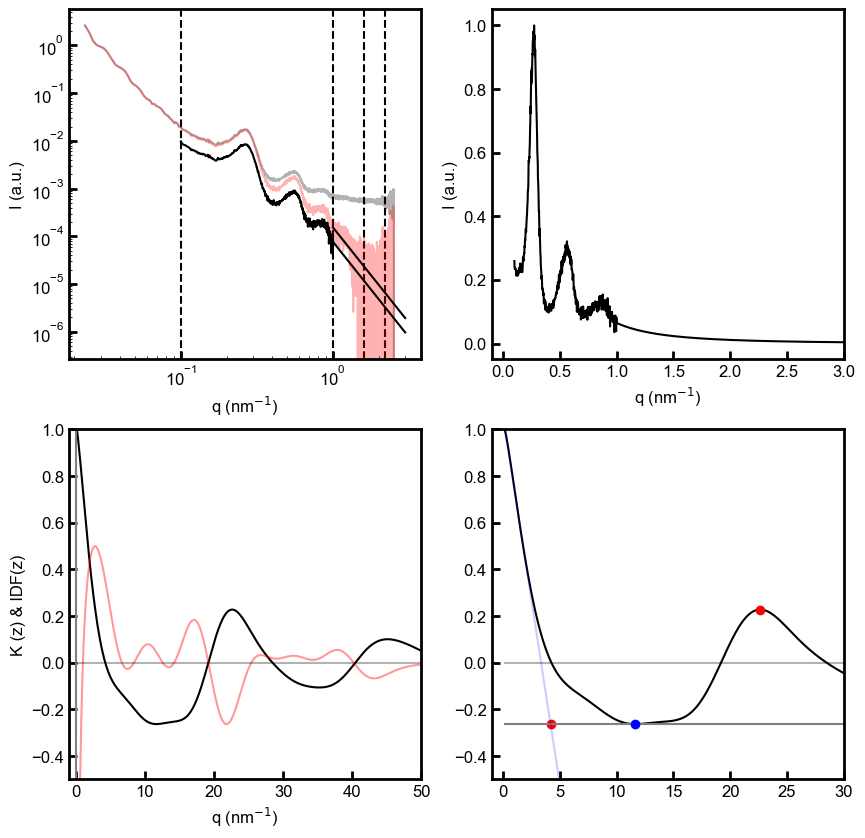

In [256]:
fig, axes = plt.subplots(2,2, figsize=(10,10))
ax1 = axes[0][0]
ax2 = axes[0][1]
ax3 = axes[1][0]
ax4 = axes[1][1]

path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00296_00_00001_av.dat"
df = pd.read_csv(path, skiprows=2, names=['q', 'I', 'err'], sep='\t')

q, I = np.array(df['q']), np.array(df['I'])

limits = [0.1, 1., 1.6, 2.2]
factor = 1.5
Porod_Const = 0.85

for lim in limits:
    ax1.axvline(x=lim, color='black', linestyle='--')


ax1.loglog(q, I, color='black', alpha=0.3)

mask_for_porod = (q > limits[-2]) * (q < limits[-1])

const, P = find_porod_A(q[mask_for_porod], I[mask_for_porod])
I_sub = I - const
ax1.loglog(q, I_sub, color='r', alpha=0.3)
x_porod = np.linspace(limits[1], 40, 2000)

sigma = 0.
Ampl = I_sub[q < limits[1]][-1] * q[q<limits[1]][-1] ** 4
y_porod = Porod_Const * smeared_porod(x_porod, Ampl, sigma)  
ax1.plot(x_porod[x_porod<3], y_porod[x_porod<3], color='black')

mask_main = (q > limits[0]) & (q < limits[1])
res_q = np.concatenate([q[mask_main], x_porod]) 
res_I = np.concatenate([I_sub[mask_main], y_porod]) 

ax1.plot(res_q[res_q<3], res_I[res_q<3] / 2, color='black')

X_lorenz, Y_lorenz = Lorenz(res_q, res_I, factor)
ax2.plot(X_lorenz, Y_lorenz / max(Y_lorenz), color='black')
# ax2.plot(X_lorenz, Y_lorenz * X_lorenz ** 2 / max(Y_lorenz * X_lorenz ** 2), color='black')
ax2.set_xlim(-0.1, 3)


dz = 2 * np.pi / max(X_lorenz)
z = np.linspace(dz, 50,  int(50 / dz))
Corr = K(X_lorenz,Y_lorenz, z)
Corr /= max(Corr)
ax3.plot(z, Corr, color='black')


idf = K(X_lorenz, Y_lorenz * X_lorenz ** 2, z)
idf /= 2 * max(-idf)
ax3.plot(z, -idf,  color='r', alpha=0.4)

ax3.set_xlim(-1, 50)
ax3.set_ylim(-.5, 1)
ax3.axvline(x=0, color='grey')
# idf = IDF(z, Corr)
# ax3.plot(z, idf, color='r')
ax3.plot(z, z*0, color='black', alpha=0.3)

ax1.set_xlabel('q (nm$^{-1}$)')
ax2.set_xlabel('q (nm$^{-1}$)')
ax3.set_xlabel('q (nm$^{-1}$)')
ax1.set_ylabel('I (a.u.)')
ax2.set_ylabel('I (a.u.)')
ax3.set_ylabel('K (z) & IDF(z)')

ax4.plot(z, Corr, color='black')
ax4.plot(z, z*0, color='black', alpha=0.3)
ax4.set_xlim(-1, 30)
ax4.set_ylim(-0.5, 1)


mask_corr = (z > 4) & (z < 25)
point_1 = min(Corr[mask_corr])
point_2 = max(Corr[mask_corr])
ax4.scatter(z[Corr == point_1], point_1, zorder=100, color='b')
ax4.plot(z, point_1 + np.zeros(len(z)), color='grey')
mask_linear = (z < 2)
popt, cov = curve_fit(linear, z[mask_linear], Corr[mask_linear])
ax4.plot(z, linear(z, *popt), color='b', alpha=0.2)
d_Amorph = (point_1 - popt[1]) / popt[0] 
ax4.scatter(d_Amorph, point_1,  color='r')

ax4.scatter(z[Corr == point_2], point_2, zorder=100, color='r')
Lp = z[Corr == point_2][0]


print('D_a =', d_Amorph)
print('D_cr =', Lp - d_Amorph)

print('Lp =', Lp)
print((Lp - d_Amorph) / Lp)


Text(0, 0.5, 'I (a.u.)')

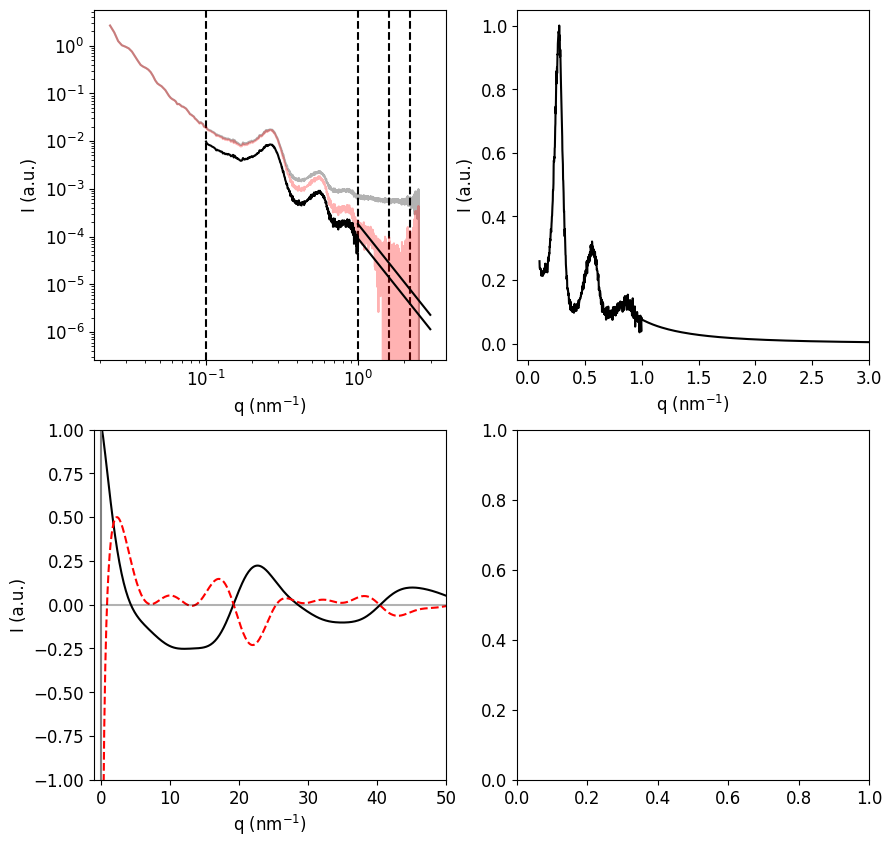

In [197]:
fig, axes = plt.subplots(2,2, figsize=(10,10))
ax1 = axes[0][0]
ax2 = axes[0][1]
ax3 = axes[1][0]
ax4 = axes[1][1]

path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00296_00_00001_av.dat"
df = pd.read_csv(path, skiprows=2, names=['q', 'I', 'err'], sep='\t')

q, I = np.array(df['q']), np.array(df['I'])

limits = [0.1, 1., 1.6, 2.2]

for lim in limits:
    ax1.axvline(x=lim, color='black', linestyle='--')


ax1.loglog(q, I, color='black', alpha=0.3)

mask_for_porod = (q > limits[-2]) * (q < limits[-1])

const, P = find_porod_A(q[mask_for_porod], I[mask_for_porod])
I_sub = I - const
ax1.loglog(q, I_sub, color='r', alpha=0.3)
x_porod = np.linspace(limits[1], 40, 2000)

sigma = 0.
Ampl = I_sub[q < limits[1]][-1] * q[q<limits[1]][-1] ** 4
y_porod = smeared_porod(x_porod, Ampl, sigma)  
ax1.plot(x_porod[x_porod<3], y_porod[x_porod<3], color='black')

mask_main = (q > limits[0]) & (q < limits[1])
res_q = np.concatenate([q[mask_main], x_porod]) 
res_I = np.concatenate([I_sub[mask_main], y_porod]) 

ax1.plot(res_q[res_q<3], res_I[res_q<3] / 2, color='black')

X_lorenz, Y_lorenz = Lorenz(res_q, res_I, 1.5)
ax2.plot(X_lorenz, Y_lorenz / max(Y_lorenz), color='black')
# ax2.plot(X_lorenz, Y_lorenz * X_lorenz ** 2 / max(Y_lorenz * X_lorenz ** 2), color='black')
ax2.set_xlim(-0.1, 3)


dz = 2 * np.pi / max(X_lorenz)
z = np.linspace(dz, 50, int(50 / dz))
Corr = K(X_lorenz,Y_lorenz, z)
Corr /= max(Corr)
ax3.plot(z, Corr, color='black')


idf = K(X_lorenz, Y_lorenz * X_lorenz ** 2, z)
idf /= 2 * max(-idf)
ax3.plot(z, -idf,  color='r', linestyle='--')

ax3.set_xlim(-1, 50)
ax3.set_ylim(-1, 1)
ax3.axvline(x=0, color='grey')
# idf = IDF(z, Corr)
# ax3.plot(z, idf, color='r')
ax3.plot(z, z*0, color='black', alpha=0.3)

ax1.set_xlabel('q (nm$^{-1}$)')
ax2.set_xlabel('q (nm$^{-1}$)')
ax3.set_xlabel('q (nm$^{-1}$)')
ax1.set_ylabel('I (a.u.)')
ax2.set_ylabel('I (a.u.)')
ax3.set_ylabel('I (a.u.)')

Text(0, 0.5, 'I (a.u.)')

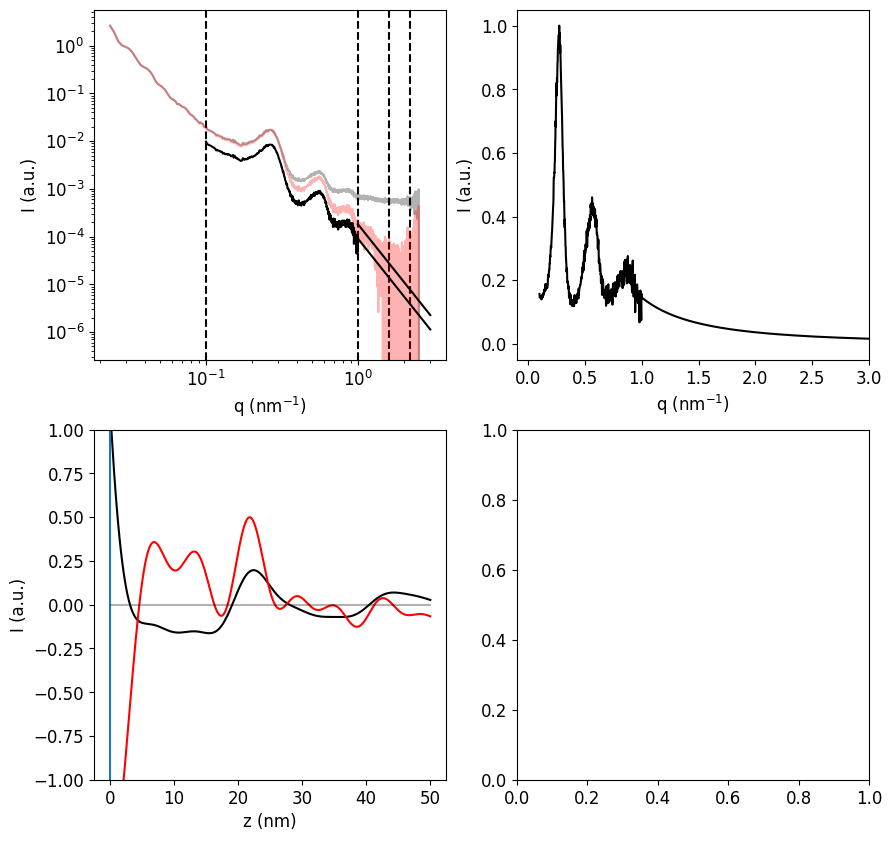

In [188]:
fig, axes = plt.subplots(2,2, figsize=(10,10))
ax1 = axes[0][0]
ax2 = axes[0][1]
ax3 = axes[1][0]
ax4 = axes[1][1]

path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00296_00_00001_av.dat"
df = pd.read_csv(path, skiprows=2, names=['q', 'I', 'err'], sep='\t')

q, I = np.array(df['q']), np.array(df['I'])

limits = [0.1, 1., 1.6, 2.2]
Lorenz_factor = 2

for lim in limits:
    ax1.axvline(x=lim, color='black', linestyle='--')


ax1.loglog(q, I, color='black', alpha=0.3)

mask_for_porod = (q > limits[-2]) * (q < limits[-1])

const, P = find_porod_A(q[mask_for_porod], I[mask_for_porod])
I_sub = I - const
ax1.loglog(q, I_sub, color='r', alpha=0.3)
x_porod = np.linspace(limits[1], 30, 5000)

sigma = 0.
Ampl = I_sub[q < limits[1]][-1] * q[q<limits[1]][-1] ** 4
y_porod = smeared_porod(x_porod, Ampl, sigma)  
ax1.plot(x_porod[x_porod<3], y_porod[x_porod<3], color='black')

mask_main = (q > limits[0]) & (q < limits[1])
res_q = np.concatenate([q[mask_main], x_porod]) 
res_I = np.concatenate([I_sub[mask_main], y_porod]) 

ax1.plot(res_q[res_q<3], res_I[res_q<3] / 2, color='black')

X_lorenz, Y_lorenz = Lorenz(res_q, res_I, Lorenz_factor)
ax2.plot(X_lorenz, Y_lorenz / max(Y_lorenz), color='black')
ax2.set_xlim(-0.1, 3)

dz = 2 * np.pi / max(X_lorenz)
z = np.linspace(dz, 50, int(50 / dz))
Corr = K(X_lorenz,Y_lorenz, z)
Corr /= max(Corr)
ax3.plot(z, Corr, color='black')
ax3.axvline(x=0)

# idf = IDF(z, Corr)
idf = K(X_lorenz,Y_lorenz * X_lorenz ** 2, z)
idf /= 2 * max(idf)
ax3.plot(z, idf, color='r')
ax3.plot(z, z*0, color='black', alpha=0.3)
ax3.set_ylim(-1, 1)

ax1.set_xlabel('q (nm$^{-1}$)')
ax2.set_xlabel('q (nm$^{-1}$)')
ax3.set_xlabel('z (nm)')
ax1.set_ylabel('I (a.u.)')
ax2.set_ylabel('I (a.u.)')
ax3.set_ylabel('I (a.u.)')

Text(0, 0.5, 'I (a.u.)')

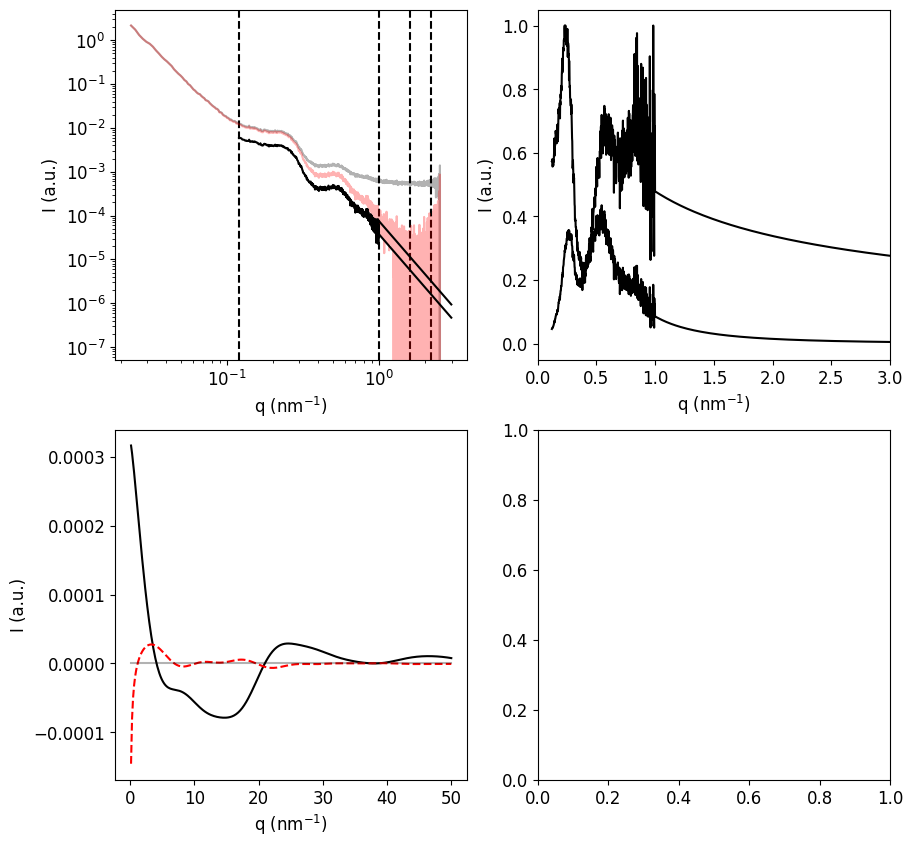

In [172]:
fig, axes = plt.subplots(2,2, figsize=(10,10))
ax1 = axes[0][0]
ax2 = axes[0][1]
ax3 = axes[1][0]
ax4 = axes[1][1]

path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00287_00_00001_av.dat"
df = pd.read_csv(path, skiprows=2, names=['q', 'I', 'err'], sep='\t')

q, I = np.array(df['q']), np.array(df['I'])

limits = [0.12, 1., 1.6, 2.2]

for lim in limits:
    ax1.axvline(x=lim, color='black', linestyle='--')


ax1.loglog(q, I, color='black', alpha=0.3)

mask_for_porod = (q > limits[-2]) * (q < limits[-1])

const, P = find_porod_A(q[mask_for_porod], I[mask_for_porod])
I_sub = I - const
ax1.loglog(q, I_sub, color='r', alpha=0.3)
x_porod = np.linspace(limits[1], 40, 2000)

sigma = 0.
Ampl = I_sub[q < limits[1]][-1] * q[q<limits[1]][-1] ** 4
y_porod = smeared_porod(x_porod, Ampl, sigma)  
ax1.plot(x_porod[x_porod<3], y_porod[x_porod<3], color='black')

mask_main = (q > limits[0]) & (q < limits[1])
res_q = np.concatenate([q[mask_main], x_porod]) 
res_I = np.concatenate([I_sub[mask_main], y_porod]) 

ax1.plot(res_q[res_q<3], res_I[res_q<3] / 2, color='black')

X_lorenz, Y_lorenz = Lorenz(res_q, res_I, 1.5)
ax2.plot(X_lorenz, Y_lorenz / max(Y_lorenz), color='black')
ax2.plot(X_lorenz, Y_lorenz * X_lorenz ** 2 / max(Y_lorenz * X_lorenz ** 2), color='black')
ax2.set_xlim(0, 3)

dz = 2 * np.pi / max(X_lorenz)
z = np.linspace(dz, 50, int(50 / dz))
Corr = K(X_lorenz,Y_lorenz, z)
ax3.plot(z, Corr, color='black')


Corr = K(X_lorenz, Y_lorenz * X_lorenz ** 2, z)
ax3.plot(z, -Corr,  color='r', linestyle='--')

idf = IDF(z, Corr)
# ax3.plot(z, idf, color='r')
ax3.plot(z, z*0, color='black', alpha=0.3)

ax1.set_xlabel('q (nm$^{-1}$)')
ax2.set_xlabel('q (nm$^{-1}$)')
ax3.set_xlabel('q (nm$^{-1}$)')
ax1.set_ylabel('I (a.u.)')
ax2.set_ylabel('I (a.u.)')
ax3.set_ylabel('I (a.u.)')

Text(0, 0.5, 'I (a.u.)')

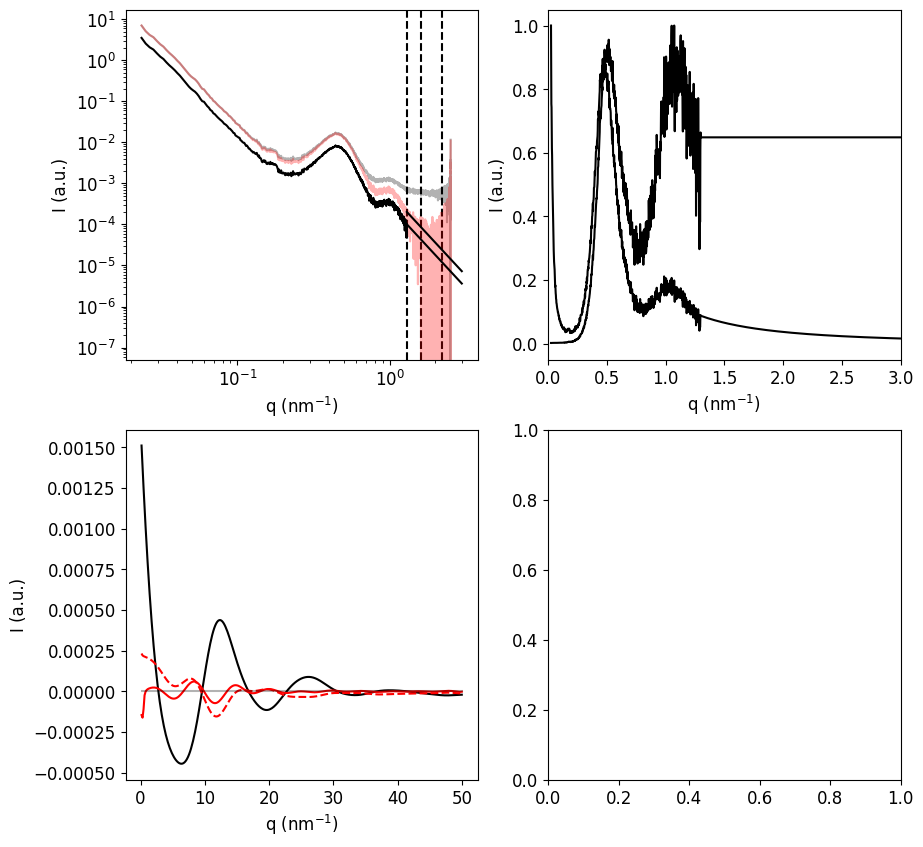

In [168]:
fig, axes = plt.subplots(2,2, figsize=(10,10))
ax1 = axes[0][0]
ax2 = axes[0][1]
ax3 = axes[1][0]
ax4 = axes[1][1]

path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00294_00_00001_av.dat"
df = pd.read_csv(path, skiprows=2, names=['q', 'I', 'err'], sep='\t')

q, I = np.array(df['q']), np.array(df['I'])

limits = [0., 1.3, 1.6, 2.2]

for lim in limits:
    ax1.axvline(x=lim, color='black', linestyle='--')


ax1.loglog(q, I, color='black', alpha=0.3)

mask_for_porod = (q > limits[-2]) * (q < limits[-1])

const, P = find_porod_A(q[mask_for_porod], I[mask_for_porod])
I_sub = I - const 

ax1.loglog(q, I_sub, color='r', alpha=0.3)
x_porod = np.linspace(limits[1], 40, 2000)

sigma = 0.
Ampl = I_sub[q < limits[1]][-1] * q[q<limits[1]][-1] ** 4
y_porod = smeared_porod(x_porod, Ampl, sigma)  
ax1.plot(x_porod[x_porod<3], y_porod[x_porod<3], color='black')

mask_main = (q > limits[0]) & (q < limits[1])
res_q = np.concatenate([q[mask_main], x_porod]) 
res_I = np.concatenate([I_sub[mask_main], y_porod]) 

ax1.plot(res_q[res_q<3], res_I[res_q<3] / 2, color='black')

X_lorenz, Y_lorenz = Lorenz(res_q, res_I, 2)
ax2.plot(X_lorenz, Y_lorenz / max(Y_lorenz), color='black')
ax2.plot(X_lorenz, Y_lorenz * X_lorenz ** 2 / max(Y_lorenz * X_lorenz ** 2), color='black')
ax2.set_xlim(0, 3)

dz = 2 * np.pi / max(X_lorenz)
z = np.linspace(dz, 50, int(50 / dz))
Corr = K(X_lorenz,Y_lorenz, z)
ax3.plot(z, Corr, color='black')


Corr = K(X_lorenz, Y_lorenz * X_lorenz ** 2, z)
ax3.plot(z, -Corr,  color='r', linestyle='--')

idf = IDF(z, Corr)
ax3.plot(z, idf, color='r')
ax3.plot(z, z*0, color='black', alpha=0.3)

ax1.set_xlabel('q (nm$^{-1}$)')
ax2.set_xlabel('q (nm$^{-1}$)')
ax3.set_xlabel('q (nm$^{-1}$)')
ax1.set_ylabel('I (a.u.)')
ax2.set_ylabel('I (a.u.)')
ax3.set_ylabel('I (a.u.)')

Text(0, 0.5, 'I (a.u.)')

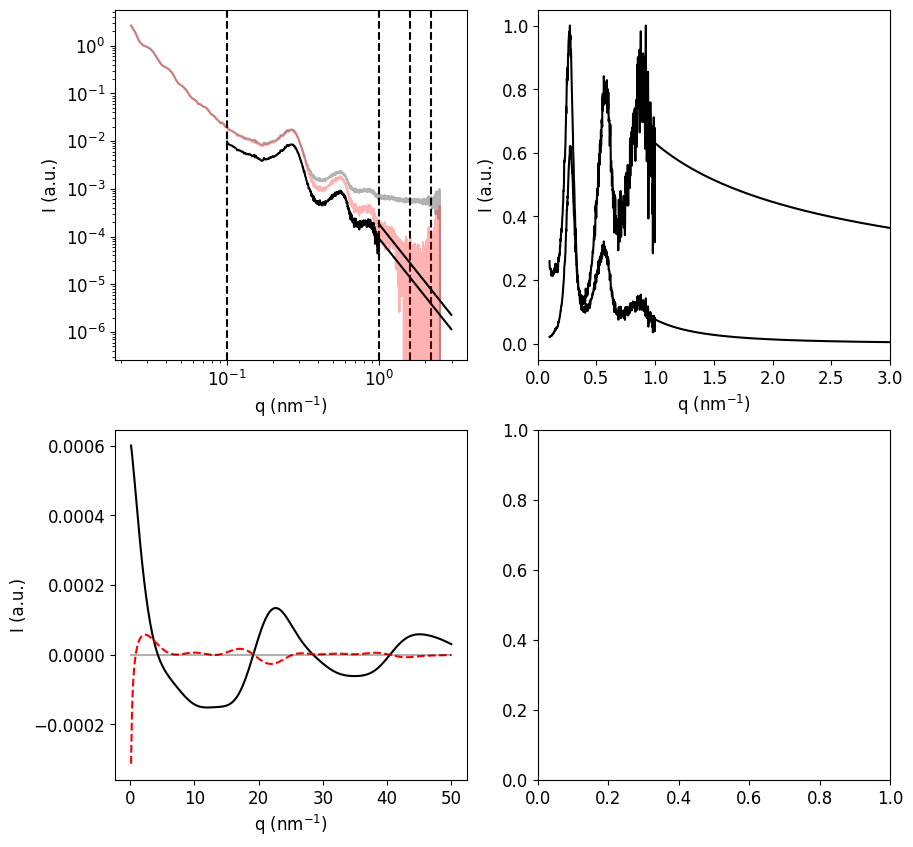

In [163]:
fig, axes = plt.subplots(2,2, figsize=(10,10))
ax1 = axes[0][0]
ax2 = axes[0][1]
ax3 = axes[1][0]
ax4 = axes[1][1]

path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00296_00_00001_av.dat"
df = pd.read_csv(path, skiprows=2, names=['q', 'I', 'err'], sep='\t')

q, I = np.array(df['q']), np.array(df['I'])

limits = [0.1, 1., 1.6, 2.2]

for lim in limits:
    ax1.axvline(x=lim, color='black', linestyle='--')


ax1.loglog(q, I, color='black', alpha=0.3)

mask_for_porod = (q > limits[-2]) * (q < limits[-1])

const, P = find_porod_A(q[mask_for_porod], I[mask_for_porod])
I_sub = I - const
ax1.loglog(q, I_sub, color='r', alpha=0.3)
x_porod = np.linspace(limits[1], 40, 2000)

sigma = 0.
Ampl = I_sub[q < limits[1]][-1] * q[q<limits[1]][-1] ** 4
y_porod = smeared_porod(x_porod, Ampl, sigma)  
ax1.plot(x_porod[x_porod<3], y_porod[x_porod<3], color='black')

mask_main = (q > limits[0]) & (q < limits[1])
res_q = np.concatenate([q[mask_main], x_porod]) 
res_I = np.concatenate([I_sub[mask_main], y_porod]) 

ax1.plot(res_q[res_q<3], res_I[res_q<3] / 2, color='black')

X_lorenz, Y_lorenz = Lorenz(res_q, res_I, 1.5)
ax2.plot(X_lorenz, Y_lorenz / max(Y_lorenz), color='black')
ax2.plot(X_lorenz, Y_lorenz * X_lorenz ** 2 / max(Y_lorenz * X_lorenz ** 2), color='black')
ax2.set_xlim(0, 3)

dz = 2 * np.pi / max(X_lorenz)
z = np.linspace(dz, 50, int(50 / dz))
Corr = K(X_lorenz,Y_lorenz, z)
ax3.plot(z, Corr, color='black')


Corr = K(X_lorenz, Y_lorenz * X_lorenz ** 2, z)
ax3.plot(z, -Corr,  color='r', linestyle='--')

idf = IDF(z, Corr)
# ax3.plot(z, idf, color='r')
ax3.plot(z, z*0, color='black', alpha=0.3)

ax1.set_xlabel('q (nm$^{-1}$)')
ax2.set_xlabel('q (nm$^{-1}$)')
ax3.set_xlabel('q (nm$^{-1}$)')
ax1.set_ylabel('I (a.u.)')
ax2.set_ylabel('I (a.u.)')
ax3.set_ylabel('I (a.u.)')

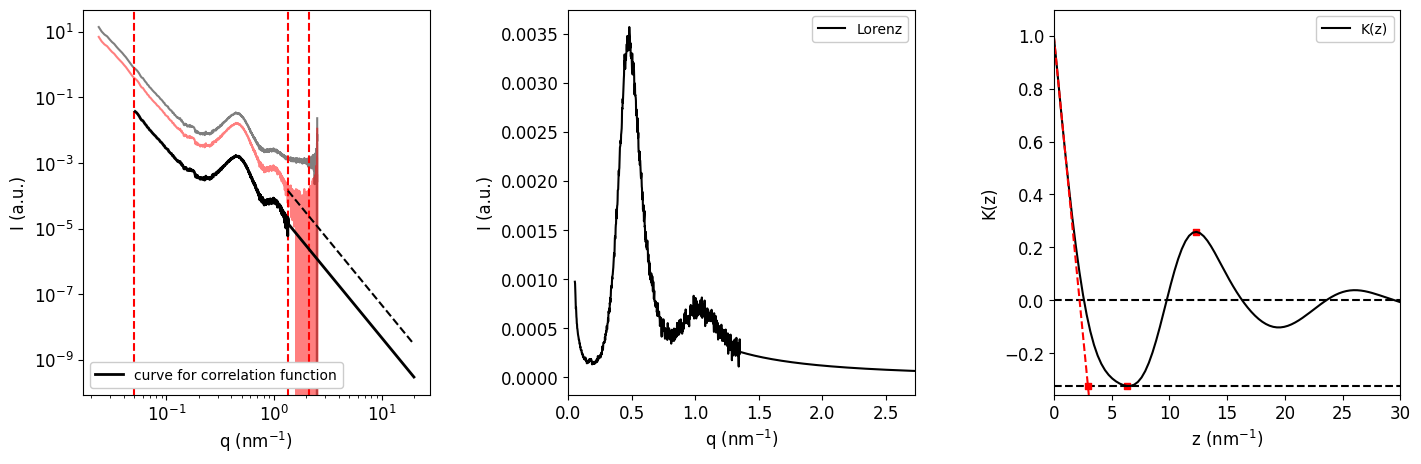

2.9553815335642795
12.341772151898734
9.386390618334454


In [319]:
z, corr_func, d_amorph_Corr, Lp_cryst_Corr = corr_analysis(q, I, limits=(0.05, 1.35, 2.1), plot=True, idf=False, lorenz_power=2, porod_const=1.05)
print(d_amorph_Corr)
print(Lp_cryst_Corr)
print(Lp_cryst_Corr-d_amorph_Corr)

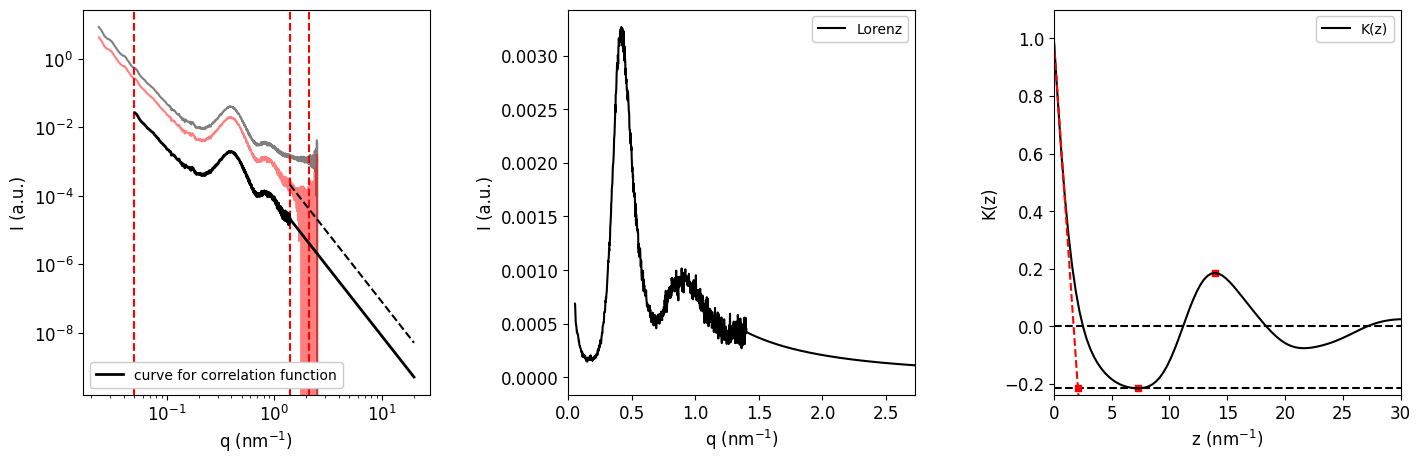

2.0822962148214024
13.924050632911394
11.841754418089991


In [276]:
z, corr_func, d_amorph_Corr, Lp_cryst_Corr = corr_analysis(q, I, limits=(0.05, 1.4, 2.1), plot=True, idf=False, lorenz_power=2, porod_const=1.05)
print(d_amorph_Corr)
print(Lp_cryst_Corr)
print(Lp_cryst_Corr-d_amorph_Corr)

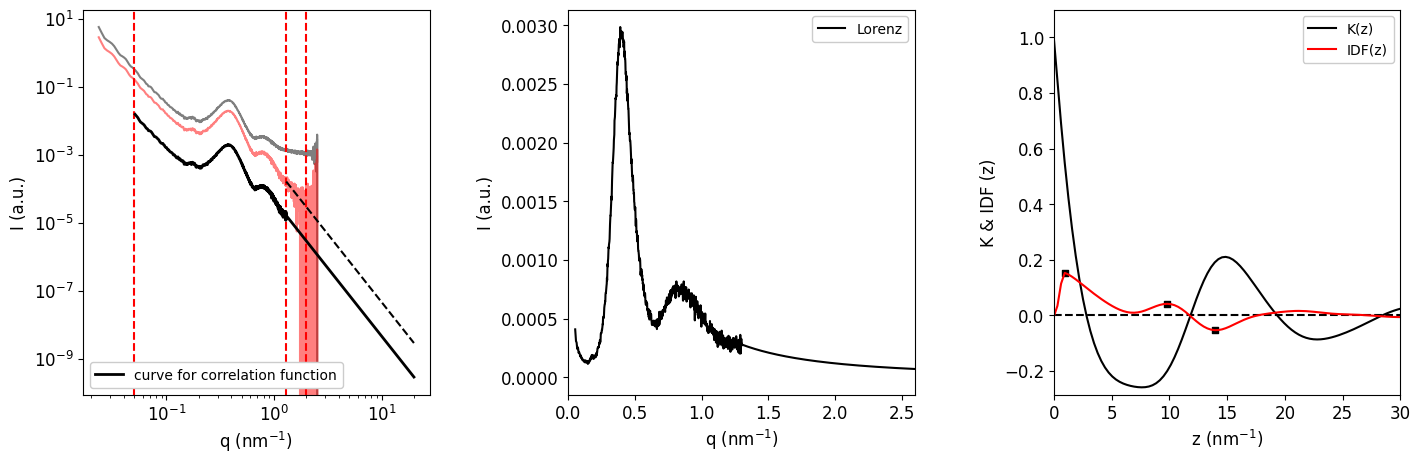

d_amorph =  0.949367088607595
d_cryst =  9.810126582278482
Lp =  13.924050632911394


In [277]:
path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00299_00_00001_av.dat"
df = pd.read_csv(path, skiprows=2, names=['q', 'I', 'err'], sep='\t')

q, I = np.array(df['q']), np.array(df['I'])
z, Korr, idf, d_amorph_idf, d_cryst_idf, Lp_idf = corr_analysis(q, I, limits=(0.05, 1.3, 2.), 
                                                                plot=True, idf=True, lorenz_power=2, porod_const=1.)

print('d_amorph = ', d_amorph_idf)
print('d_cryst = ', d_cryst_idf)
print('Lp = ', Lp_idf)

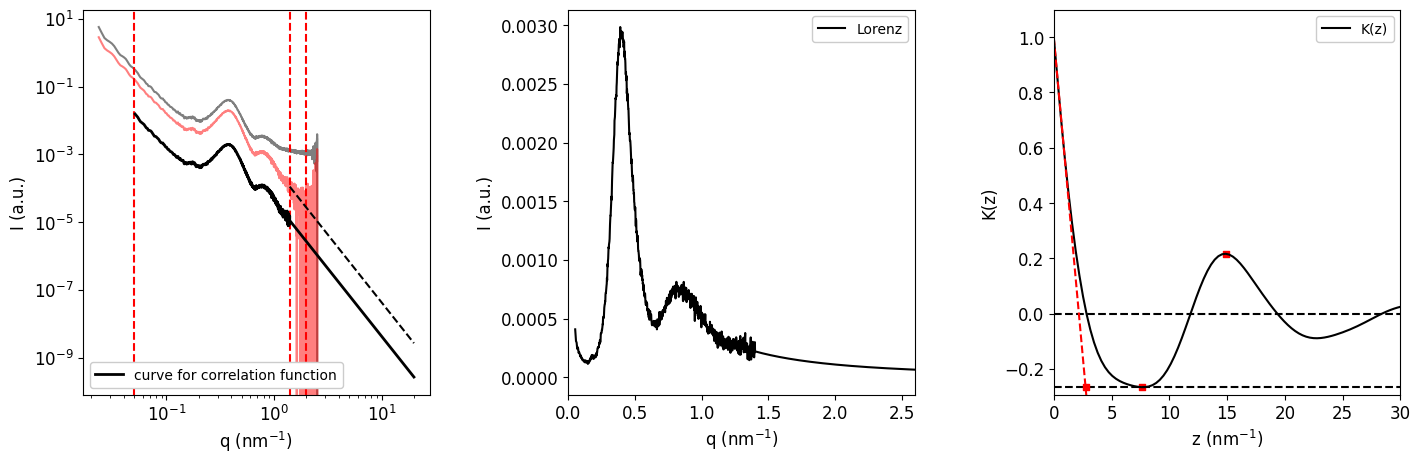

2.7507315662109715
14.873417721518988
12.122686155308017


In [278]:
z, corr_func, d_amorph_Corr, Lp_cryst_Corr = corr_analysis(q, I, limits=(0.05, 1.4, 2.), 
                                                           plot=True, idf=False, lorenz_power=2, porod_const=1.)
print(d_amorph_Corr)
print(Lp_cryst_Corr)
print(Lp_cryst_Corr-d_amorph_Corr)

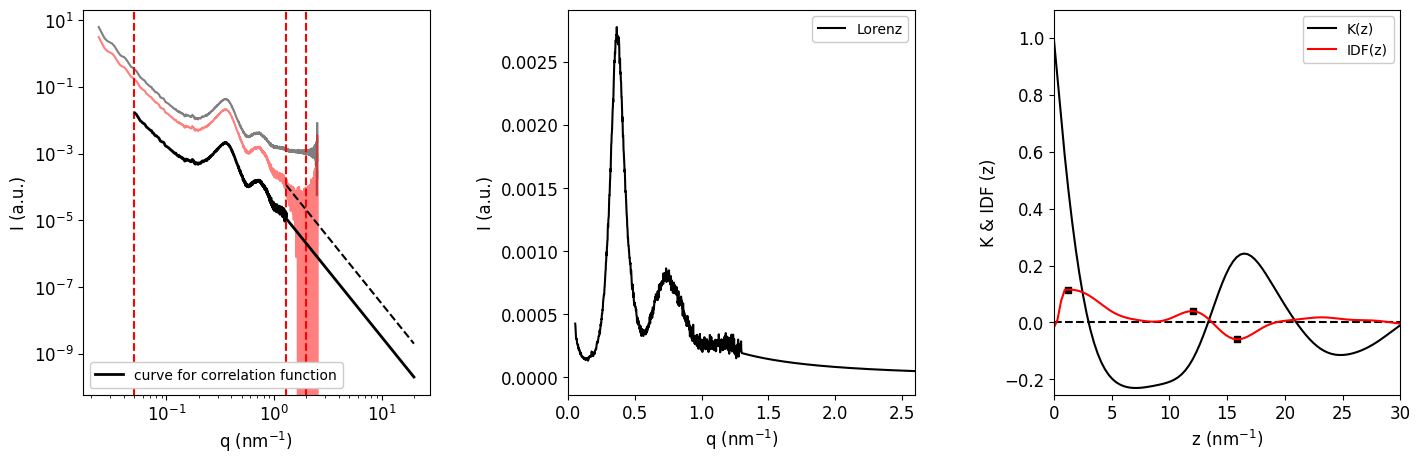

d_amorph =  1.2658227848101267
d_cryst =  12.025316455696203
Lp =  15.822784810126583


In [279]:
path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00302_00_00001_av.dat"
df = pd.read_csv(path, skiprows=2, names=['q', 'I', 'err'], sep='\t')

q, I = np.array(df['q']), np.array(df['I'])
z, Korr, idf, d_amorph_idf, d_cryst_idf, Lp_idf = corr_analysis(q, I, limits=(0.05, 1.3, 2.), 
                                                                plot=True, idf=True, lorenz_power=2, porod_const=1.2)

print('d_amorph = ', d_amorph_idf)
print('d_cryst = ', d_cryst_idf)
print('Lp = ', Lp_idf)

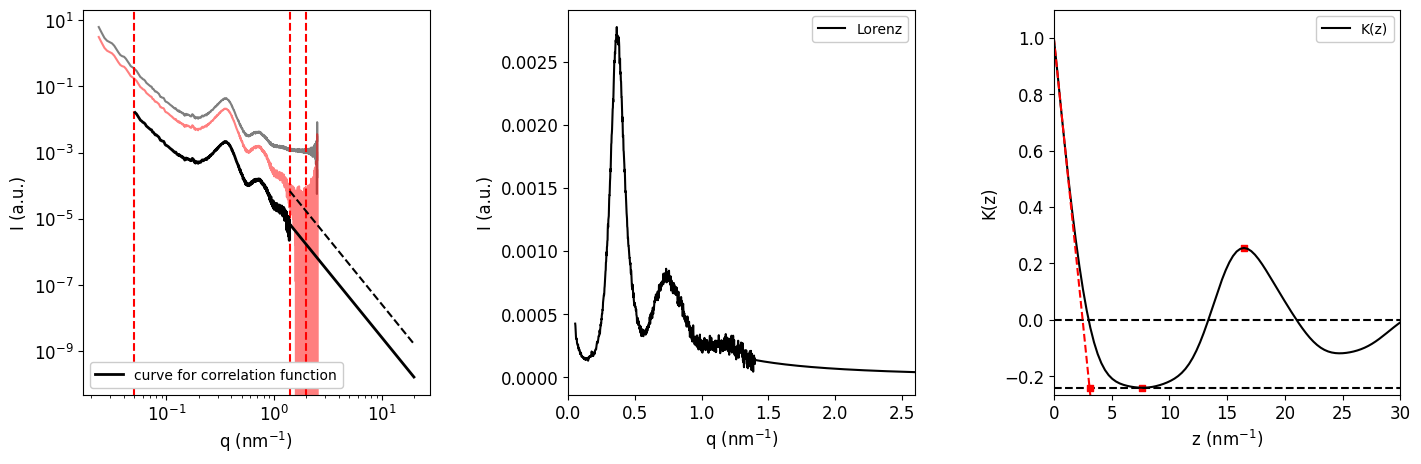

3.0957471243905155
16.455696202531648
13.359949078141133


In [280]:
z, corr_func, d_amorph_Corr, Lp_cryst_Corr = corr_analysis(q, I, limits=(0.05, 1.4, 2.), 
                                                           plot=True, idf=False, lorenz_power=2, porod_const=1.2)
print(d_amorph_Corr)
print(Lp_cryst_Corr)
print(Lp_cryst_Corr-d_amorph_Corr)

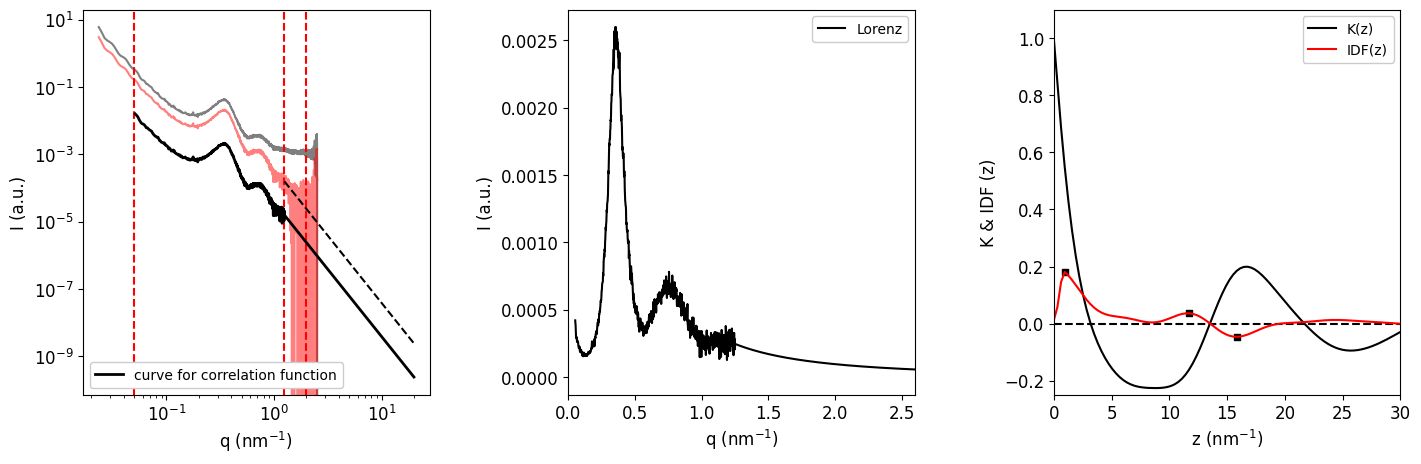

d_amorph =  0.949367088607595
d_cryst =  11.708860759493671
Lp =  15.822784810126583


In [284]:
path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00305_00_00001_av.dat"
df = pd.read_csv(path, skiprows=2, names=['q', 'I', 'err'], sep='\t')

q, I = np.array(df['q']), np.array(df['I'])
z, Korr, idf, d_amorph_idf, d_cryst_idf, Lp_idf = corr_analysis(q, I, limits=(0.05, 1.25, 2.), 
                                                                plot=True, idf=True, lorenz_power=2, porod_const=1.0)

print('d_amorph = ', d_amorph_idf)
print('d_cryst = ', d_cryst_idf)
print('Lp = ', Lp_idf)

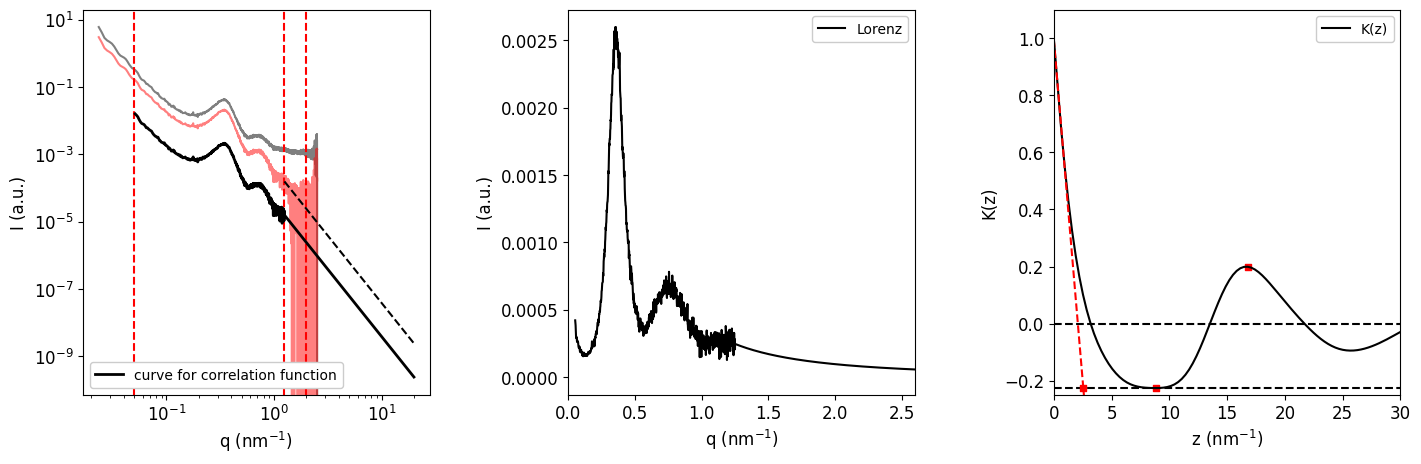

2.555270104160568
16.77215189873418
14.216881794573611


In [285]:
z, corr_func, d_amorph_Corr, Lp_cryst_Corr = corr_analysis(q, I, limits=(0.05, 1.25, 2.), 
                                                           plot=True, idf=False, lorenz_power=2, porod_const=1.0)
print(d_amorph_Corr)
print(Lp_cryst_Corr)
print(Lp_cryst_Corr-d_amorph_Corr)

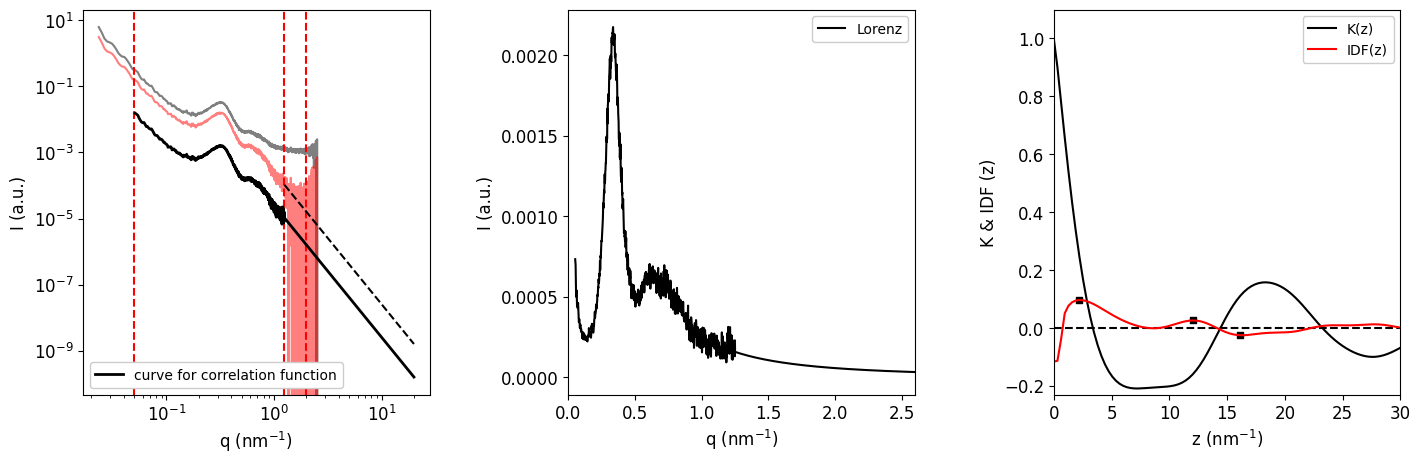

d_amorph =  2.2151898734177218
d_cryst =  12.025316455696203
Lp =  16.139240506329116


In [295]:
path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00301_00_00001_av.dat"
df = pd.read_csv(path, skiprows=2, names=['q', 'I', 'err'], sep='\t')

q, I = np.array(df['q']), np.array(df['I'])
z, Korr, idf, d_amorph_idf, d_cryst_idf, Lp_idf = corr_analysis(q, I, limits=(0.05, 1.25, 2.), 
                                                                plot=True, idf=True, lorenz_power=1.8, porod_const=1.1)

print('d_amorph = ', d_amorph_idf)
print('d_cryst = ', d_cryst_idf)
print('Lp = ', Lp_idf)

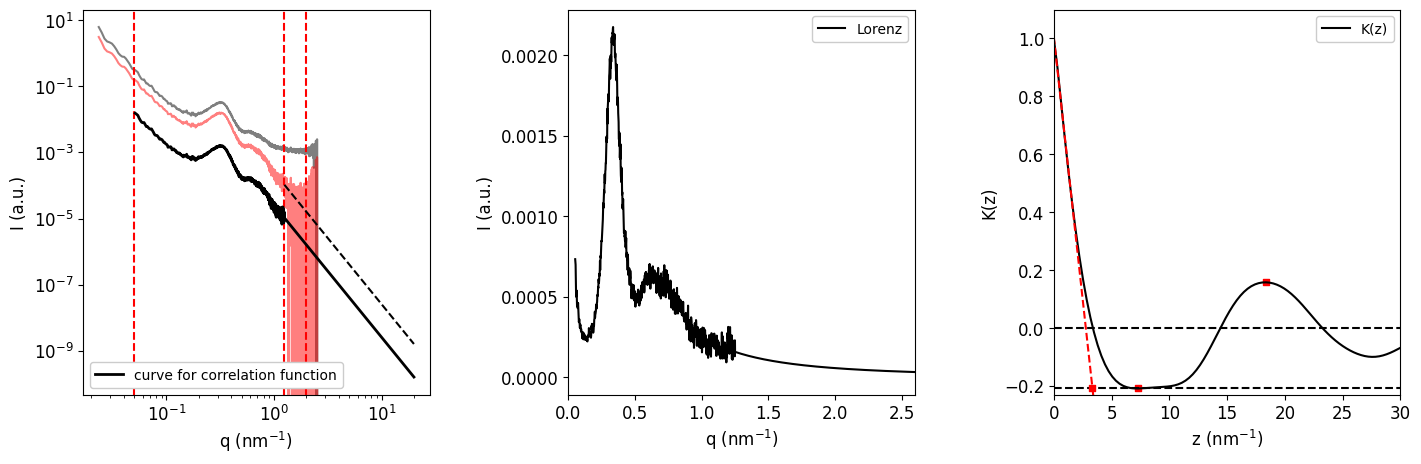

3.3492372924603107
18.354430379746837
15.005193087286527


In [296]:
z, corr_func, d_amorph_Corr, Lp_cryst_Corr = corr_analysis(q, I, limits=(0.05, 1.25, 2.), 
                                                           plot=True, idf=False, lorenz_power=1.8, porod_const=1.1)
print(d_amorph_Corr)
print(Lp_cryst_Corr)
print(Lp_cryst_Corr-d_amorph_Corr)

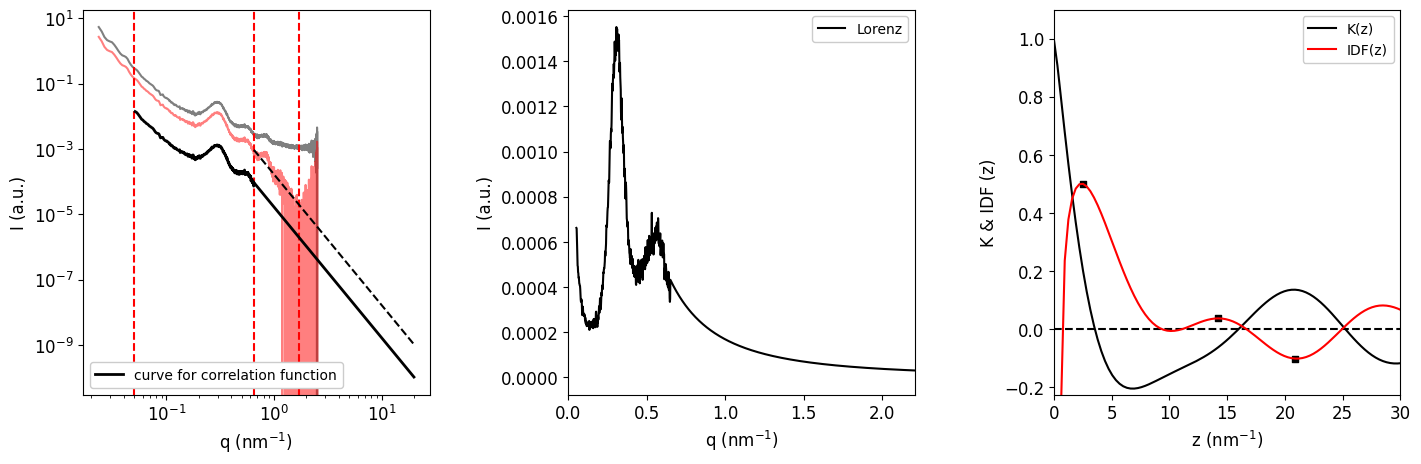

d_amorph =  2.5316455696202533
d_cryst =  14.240506329113925
Lp =  20.88607594936709


In [366]:
path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00291_00_00001_av.dat"
df = pd.read_csv(path, skiprows=2, names=['q', 'I', 'err'], sep='\t')

q, I = np.array(df['q']), np.array(df['I'])
z, Korr, idf, d_amorph_idf, d_cryst_idf, Lp_idf = corr_analysis(q, I, limits=(0.05, 0.65, 1.7), 
                                                                plot=True, idf=True, lorenz_power=1.8, porod_const=.9)

print('d_amorph = ', d_amorph_idf)
print('d_cryst = ', d_cryst_idf)
print('Lp = ', Lp_idf)

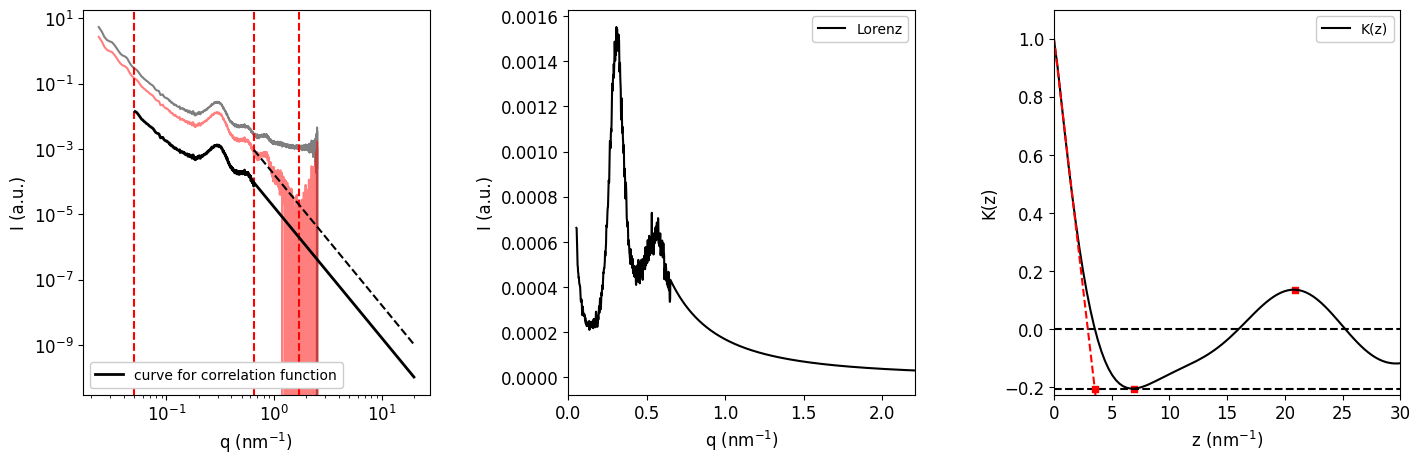

3.543937142256154
20.88607594936709
17.342138807110935


In [368]:
z, corr_func, d_amorph_Corr, Lp_cryst_Corr = corr_analysis(q, I, limits=(0.05, 0.65, 1.7), 
                                                           plot=True, idf=False, lorenz_power=1.8, porod_const=.9)
print(d_amorph_Corr)
print(Lp_cryst_Corr)
print(Lp_cryst_Corr-d_amorph_Corr)

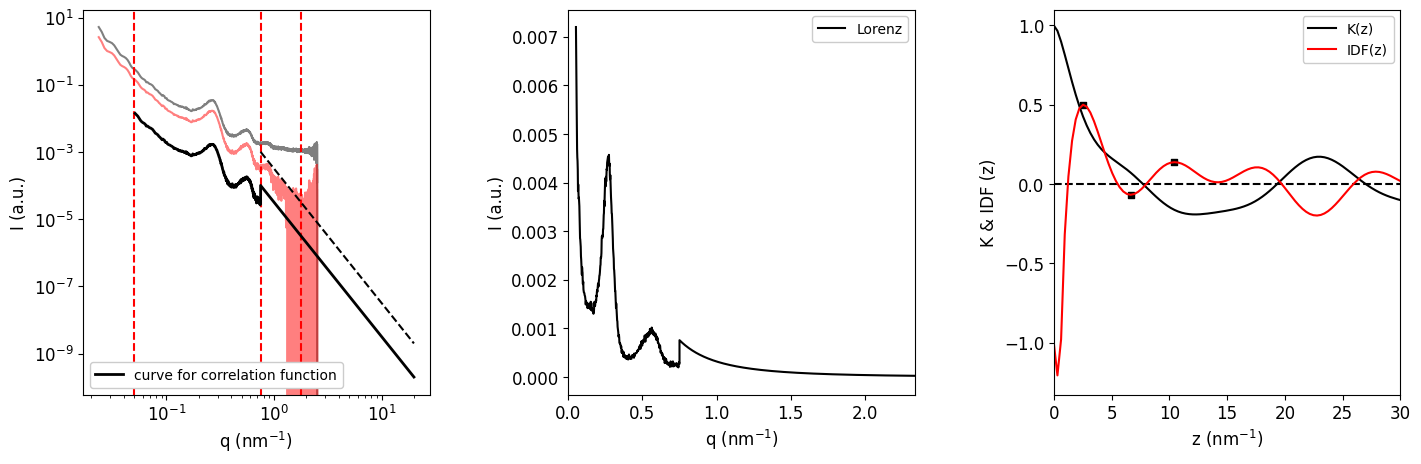

d_amorph =  2.5316455696202533
d_cryst =  10.443037974683545
Lp =  6.645569620253165


In [408]:
path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00296_00_00001_av.dat"
df = pd.read_csv(path, skiprows=2, names=['q', 'I', 'err'], sep='\t')

q, I = np.array(df['q']), np.array(df['I'])
z, Korr, idf, d_amorph_idf, d_cryst_idf, Lp_idf = corr_analysis(q, I, limits=(0.05, 0.75, 1.8), 
                                                                plot=True, idf=True, lorenz_power=1., porod_const=2)

print('d_amorph = ', d_amorph_idf)
print('d_cryst = ', d_cryst_idf)
print('Lp = ', Lp_idf)

In [ ]:
z, corr_func, d_amorph_Corr, Lp_cryst_Corr = corr_analysis(q, I, limits=(0.05, 1.25, 2.), 
                                                           plot=True, idf=False, lorenz_power=1.8, porod_const=1.1)
print(d_amorph_Corr)
print(Lp_cryst_Corr)
print(Lp_cryst_Corr-d_amorph_Corr)

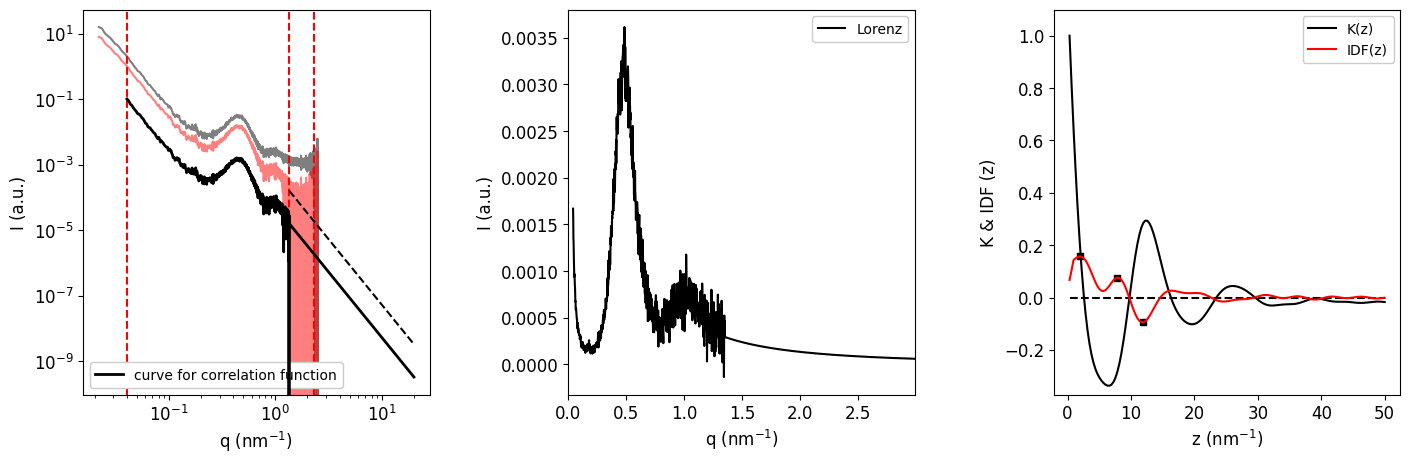

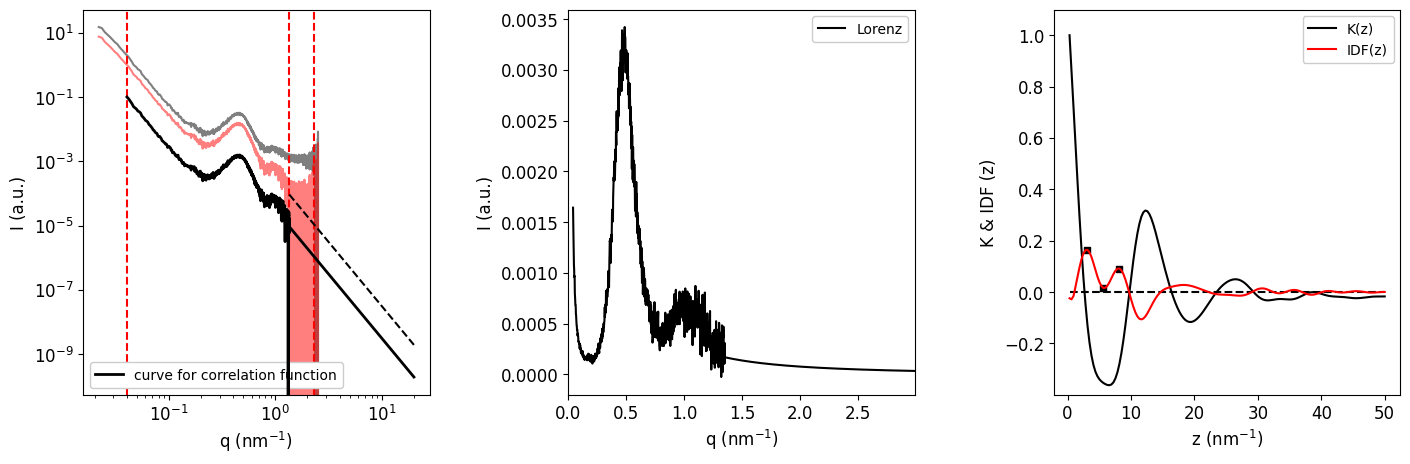

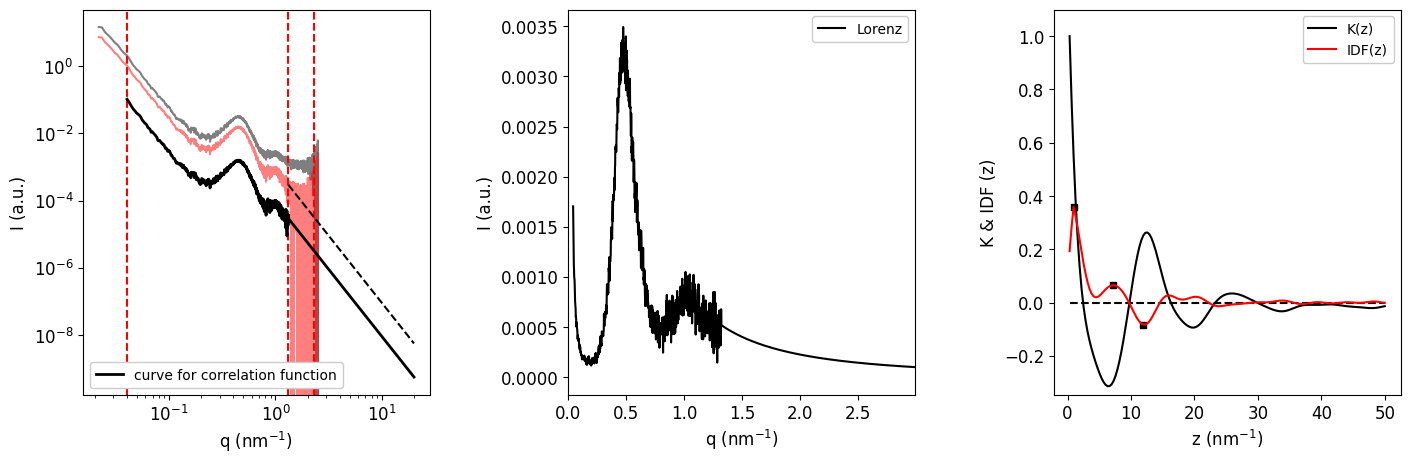

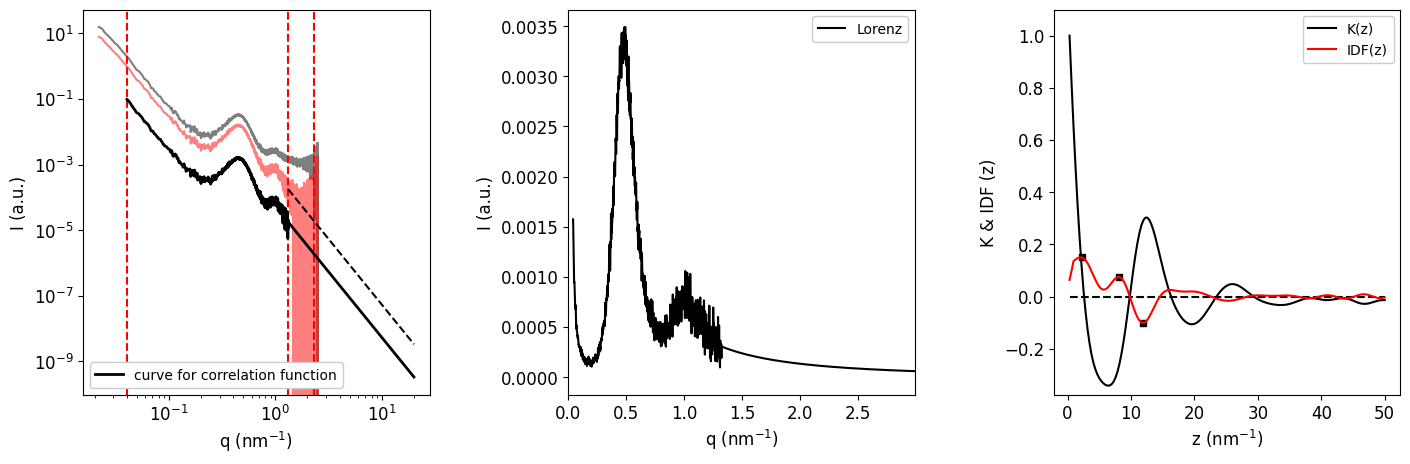

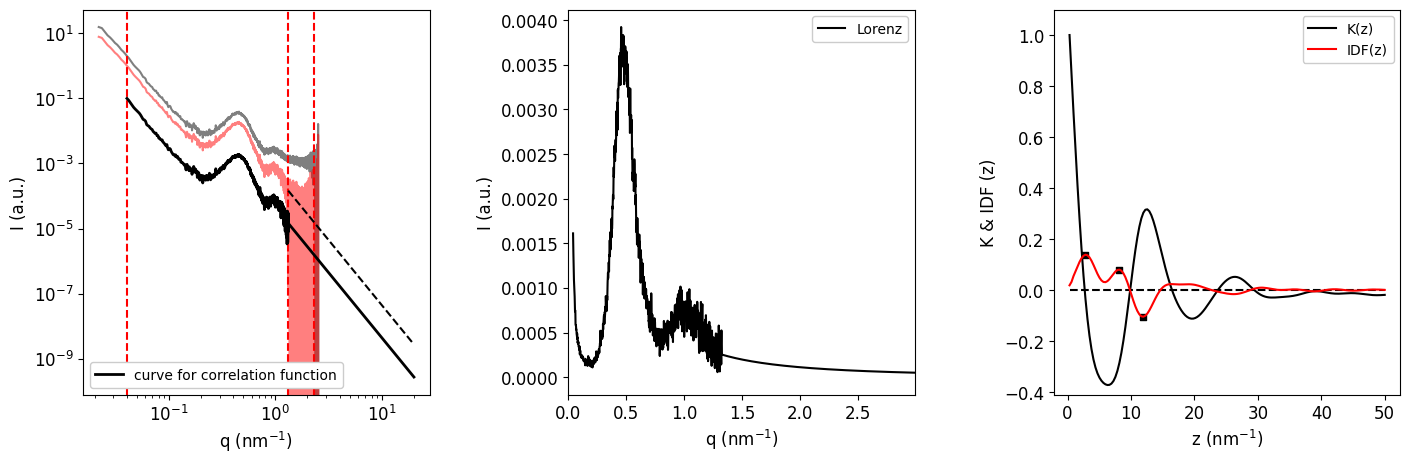

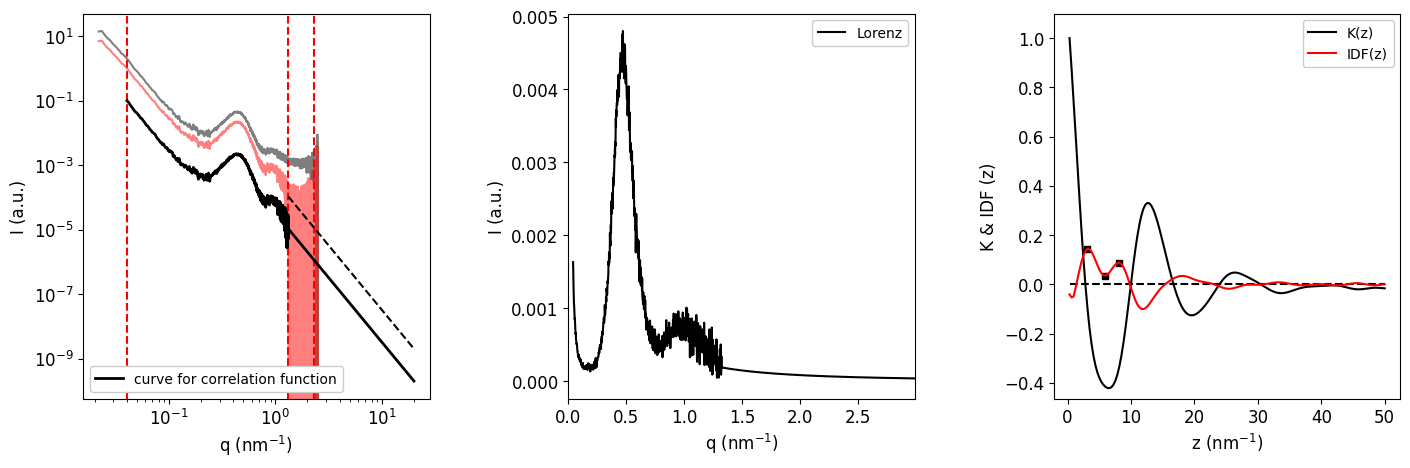

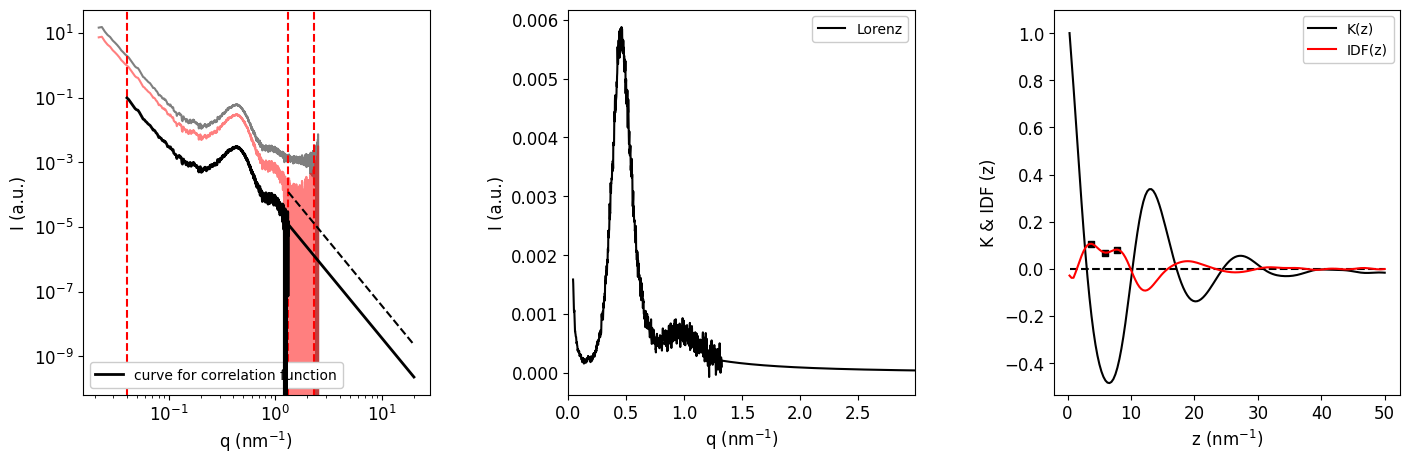

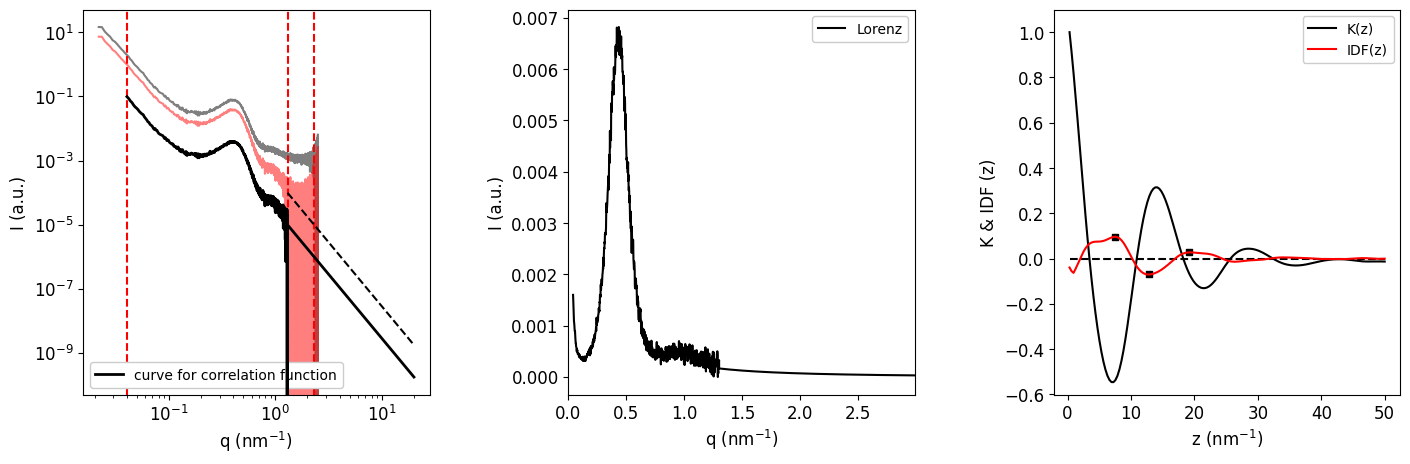

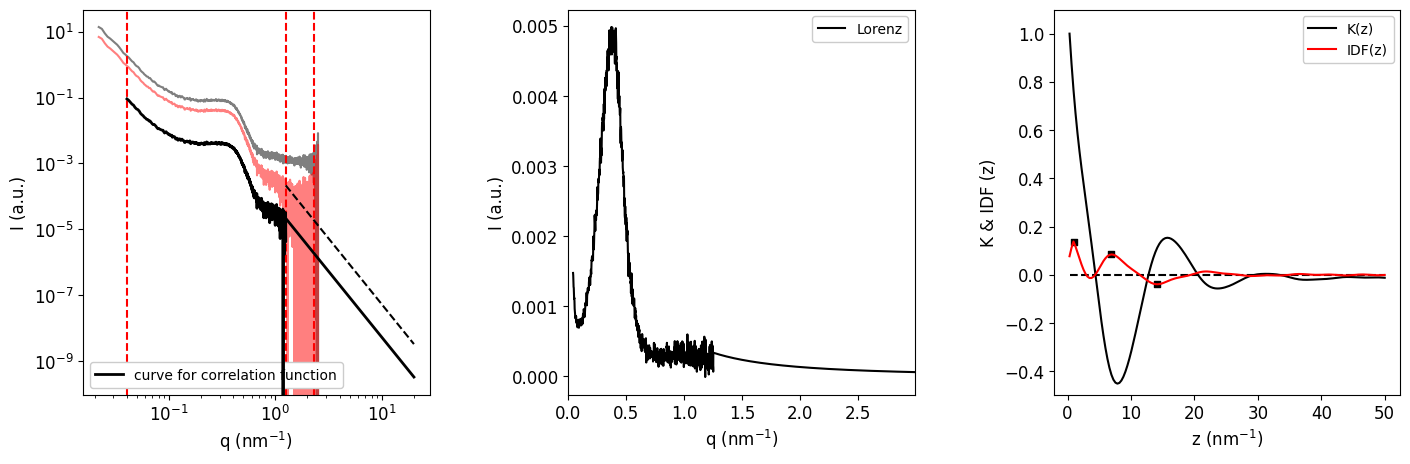

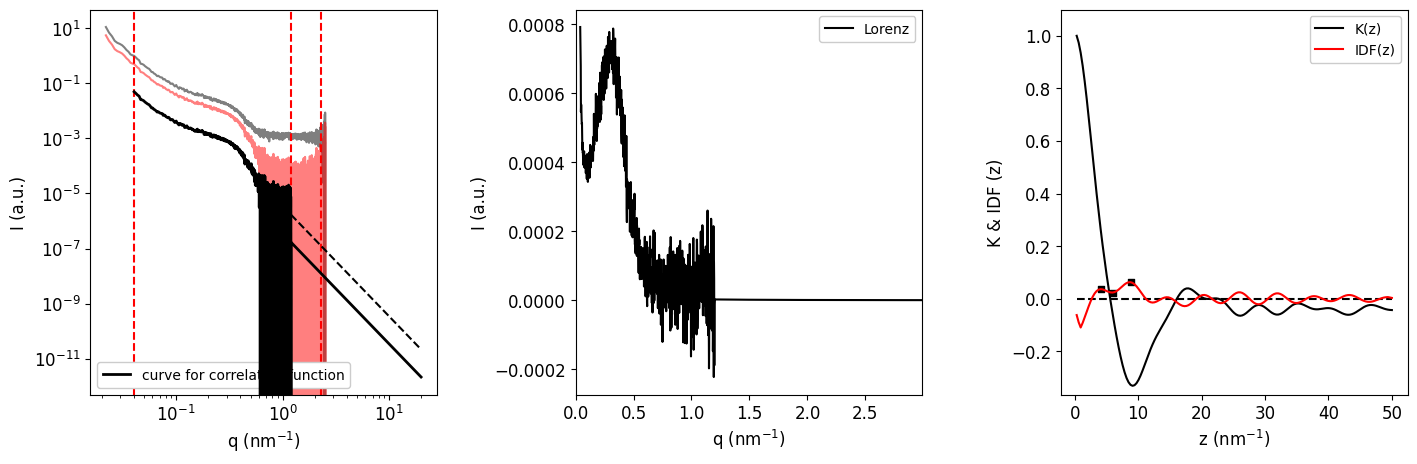

In [99]:
path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00294_00_00001_av.dat"
df = pd.read_csv(path, skiprows=2, names=['q', 'I', 'err'], sep='\t')
q, I = np.array(df['q']), np.array(df['I'])
# plt.plot(q, I, label='after quenching', linewidth=2, color='#6f1926')

path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00295_00_ave.h5"

Exp = ID02_experiment(path)
q, I_array = Exp.get_all_1d()

def average(I_array, indexes):
    I_0 = I_array[0] * 0
    for index in indexes:
        I_0 += I_array[index]
    I_0 /= len(indexes)
    return I_0

d_cryst = []
z, Korr, idf, d_amorph_idf, d_cryst_idf, sum_idf = corr_analysis(q, average(I_array, [i for i in range(10)]), limits=(0.04, 1.35, 2.3), 
                                                                plot=True, idf=True)
d_cryst.append(d_cryst_idf)

z, Korr, idf, d_amorph_idf, d_cryst_idf, sum_idf = corr_analysis(q, average(I_array, [i for i in range(10, 20)]), limits=(0.04, 1.35, 2.3), 
                                                                plot=True, idf=True)
d_cryst.append(d_cryst_idf)

z, Korr, idf, d_amorph_idf, d_cryst_idf, sum_idf = corr_analysis(q, average(I_array, [i for i in range(20, 30)]), limits=(0.04, 1.32, 2.3), 
                                                                plot=True, idf=True)
d_cryst.append(d_cryst_idf)

z, Korr, idf, d_amorph_idf, d_cryst_idf, sum_idf = corr_analysis(q, average(I_array, [i for i in range(30, 40)]), limits=(0.04, 1.32, 2.3), 
                                                                plot=True, idf=True)
d_cryst.append(d_cryst_idf)

z, Korr, idf, d_amorph_idf, d_cryst_idf, sum_idf = corr_analysis(q, average(I_array, [i for i in range(40, 50)]), limits=(0.04, 1.32, 2.3), 
                                                                plot=True, idf=True)
d_cryst.append(d_cryst_idf)

z, Korr, idf, d_amorph_idf, d_cryst_idf, sum_idf = corr_analysis(q, average(I_array, [i for i in range(50, 60)]), limits=(0.04, 1.32, 2.3), 
                                                                plot=True, idf=True)
d_cryst.append(d_cryst_idf)

z, Korr, idf, d_amorph_idf, d_cryst_idf, sum_idf = corr_analysis(q, average(I_array, [i for i in range(60, 70)]), limits=(0.04, 1.32, 2.3), 
                                                                plot=True, idf=True)
d_cryst.append(d_cryst_idf)
z, Korr, idf, d_amorph_idf, d_cryst_idf, sum_idf = corr_analysis(q, average(I_array, [i for i in range(70, 80)]), limits=(0.04, 1.3, 2.3), 
                                                                plot=True, idf=True)
d_cryst.append(d_amorph_idf)
z, Korr, idf, d_amorph_idf, d_cryst_idf, sum_idf = corr_analysis(q, average(I_array, [i for i in range(80, 90)]), limits=(0.04, 1.25, 2.3), 
                                                                plot=True, idf=True)
d_cryst.append(d_cryst_idf)
z, Korr, idf, d_amorph_idf, d_cryst_idf, sum_idf = corr_analysis(q, average(I_array, [i for i in range(90, 100)]), limits=(0.04, 1.2, 2.3), 
                                                                plot=True, idf=True)
d_cryst.append(d_cryst_idf)
# z, Korr, idf, d_amorph_idf, d_cryst_idf, sum_idf = corr_analysis(q, average(I_array, [i for i in range(70, 80)]), limits=(0.04, 1.3, 2.3), 
#                                                                 plot=True, idf=True)
# print(d_amorph_idf)

# z, Korr, idf, d_amorph_idf, d_cryst_idf, sum_idf = corr_analysis(q, average(I_array, [i for i in range(80, 90)]), limits=(0.04, 1.25, 2.3), 
#                                                                 plot=True, idf=True)
# print(48.8 / d_cryst_idf)

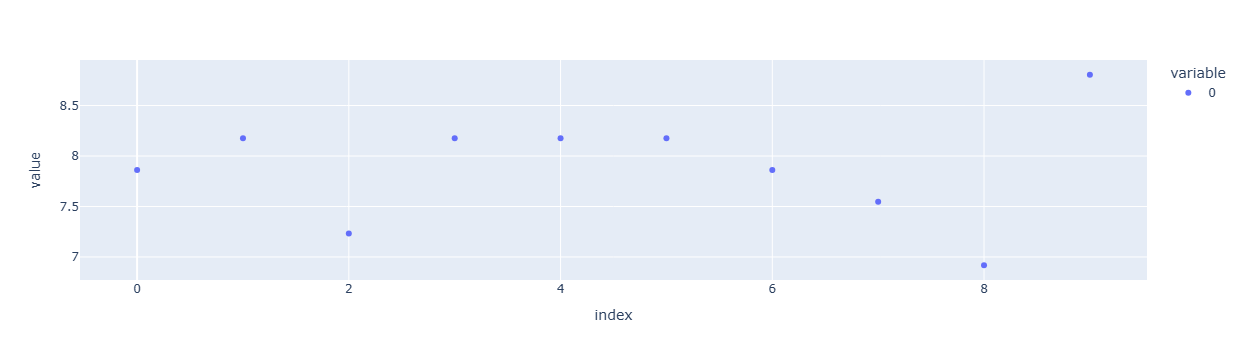

In [100]:
px.scatter(d_cryst)

In [ ]:
path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00294_00_00001_av.dat"
df = pd.read_csv(path, skiprows=2, names=['q', 'I', 'err'], sep='\t')
q, I = np.array(df['q']), np.array(df['I'])
z, Korr, idf, d_amorph_idf, d_cryst_idf, sum_idf = corr_analysis(q, average(I_array, [i for i in range(10)]), limits=(0.04, 1.35, 2.3), 
                                                                plot=True, idf=True)

path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00290_00_00001_av.dat"
df = pd.read_csv(path, skiprows=2, names=['q', 'I', 'err'], sep='\t')
q, I = np.array(df['q']), np.array(df['I'])

path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00299_00_00001_av.dat"
df = pd.read_csv(path, skiprows=2, names=['q', 'I', 'err'], sep='\t')
q, I = np.array(df['q']), np.array(df['I'])

path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00302_00_00001_av.dat"
df = pd.read_csv(path, skiprows=2, names=['q', 'I', 'err'], sep='\t')
q, I = np.array(df['q']), np.array(df['I'])

path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00305_00_00001_av.dat"
df = pd.read_csv(path, skiprows=2, names=['q', 'I', 'err'], sep='\t')
q, I = np.array(df['q']), np.array(df['I'])

path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00301_00_00001_av.dat"
df = pd.read_csv(path, skiprows=2, names=['q', 'I', 'err'], sep='\t')
q, I = np.array(df['q']), np.array(df['I'])

path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00291_00_00001_av.dat"
df = pd.read_csv(path, skiprows=2, names=['q', 'I', 'err'], sep='\t')
q, I = np.array(df['q']), np.array(df['I'])

path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00296_00_00001_av.dat"
df = pd.read_csv(path, skiprows=2, names=['q', 'I', 'err'], sep='\t')
q, I = np.array(df['q']), np.array(df['I'])



In [38]:
for i in range(19):
    X, I = q, average(I_array, [i for i in range(i, 10 * i)])
    z, K, idf, d_amorph_idf, d_cryst_idf, sum_idf = corr_analysis(x, y, limits=(0.04, 1.35, 2.3), 
                                                                plot=True, idf=True)
    

C:\Users\LabPCA\AppData\Local\Temp\ipykernel_14544\3833089308.py:15: RuntimeWarning: invalid value encountered in divide
  I_0 /= len(indexes)


ValueError: array must not contain infs or NaNs

3.4747421123807607
12.263918429386566
2.829898036733208
7.861375579481665
10.691273616214874
5.660104154529216


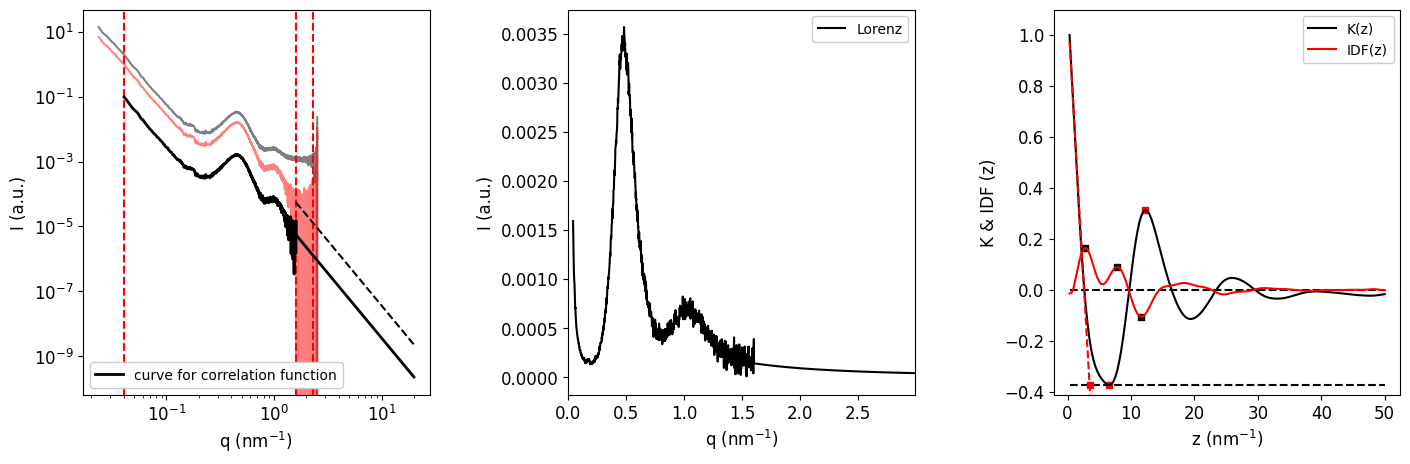

In [62]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(17,5))
plt.subplots_adjust(wspace=0.4)
ax1.loglog(q, I * 2, color='black', alpha=0.5) 

left_lim = 0.04
middle_lim = 1.6
right_lim = 2.3

left = np.argmin(np.abs(q - left_lim))
middle = np.argmin(np.abs(q - middle_lim))
right = np.argmin(np.abs(q - right_lim))

ax1.axvline(x=q[left], color='red', linestyle='--', zorder=2)
ax1.axvline(x=q[middle], color='red', linestyle='--', zorder=2)
ax1.axvline(x=q[right], color='red', linestyle='--', zorder=2)

mask_1 = (q < left_lim)
mask_2 = (q >= left_lim) & (q < middle_lim)  # Исправлено: & вместо *
mask_3 = (q >= middle_lim) & (q < right_lim)  # Исправлено: & вместо *
x_3 = q[mask_3]
y_3 = I[mask_3]

const, p = find_porod_A(x_3, y_3)
ax1.plot(q, I - const, alpha = 0.5, color='red')
x_porod = np.linspace(middle_lim, 20, 2000)
y_porod = porod(x_porod, *p)  # Исправлено: распаковка p
ax1.plot(x_porod, y_porod, color='black', linestyle='--')

# ИСПРАВЛЕНО: объединение массивов
res_q = np.concatenate([q[mask_2], x_porod])  # список массивов
res_I = np.concatenate([I[mask_2] - const, y_porod])  # список массивов

ax1.loglog(res_q, res_I / 10, color='black', linewidth=2, zorder=100, label = 'curve for correlation function')

ax1.set_xlabel('q (nm$^{-1}$)')
ax1.set_ylabel('I (a.u.)')
ax1.legend(loc=3, fontsize=(10), framealpha=1)

X, Y = Lorenz(res_q, res_I, 2.) 
ax2.plot(X, Y, color='black', label='Lorenz')
ax2.set_xlim(0, right_lim * 1.3)
ax2.legend(fontsize=(10), framealpha=1)
ax2.set_xlabel('q (nm$^{-1}$)')
ax2.set_ylabel('I (a.u.)')

dz = 2 * np.pi / max(X)
z = np.linspace(dz, 50, int(50 / dz))
Corr = K(X,Y, z)
Corr /= max(Corr)
idf = IDF(dz, Corr)

ax3.plot(z, Corr, color='black', label='K(z)')
ax3.plot(z, np.zeros(len(z)), linestyle='--', color='black')
ax3.plot(z, idf, color='red', label='IDF(z)')
ax3.set_xlabel('z (nm$^{-1}$)')
ax3.set_ylabel('K & IDF (z)')

Corr_peaks, properties = find_peaks(Corr)
Corr_mins, properties = find_peaks(-Corr)
ax3.scatter(z[Corr_peaks[0]], Corr[Corr_peaks[0]], color='red', marker='s', zorder=0, s=20)
ax3.scatter(z[Corr_mins[0]], Corr[Corr_mins[0]], color='red', marker='s', zorder=0, s=20)

p, cov = curve_fit(linear, z[z < 3], Corr[z < 3])

d_amorph_Corr = (Corr[Corr_mins[0]] - p[1]) / p[0]
Lp_cryst_Corr = z[Corr_peaks[0]]
ax3.plot(z, linear(z, *p), color='red', linestyle='--' )
ax3.plot(z, Corr[Corr_mins[0]] * np.ones(len(z)), color='black', linestyle='--' )
ax3.scatter(d_amorph_Corr, linear(d_amorph_Corr, *p), zorder=10, color='red', marker='s', s=20)

idf_peaks, properties = find_peaks(idf)
idf_mins, properties = find_peaks(-idf)
ax3.scatter(z[idf_peaks[:2]], idf[idf_peaks[:2]], color='black', marker='s', zorder=0, s=20)
ax3.scatter(z[idf_mins[1:2]], idf[idf_mins[1:2]], color='black', marker='s', zorder=0, s=20)

ax3.legend(fontsize=(10), framealpha=1)
ax3.set_ylim((min(Corr) * 1.1), (max(Corr) * 1.1))

d_amorph_idf = z[idf_peaks[0]]
d_cryst_idf = z[idf_peaks[1]]
Lp_idf = z[idf_mins[0]]

print(d_amorph_Corr)
print(Lp_cryst_Corr)
print(d_amorph_idf)
print(d_cryst_idf)
print(d_cryst_idf + d_amorph_idf)
print(Lp_idf)

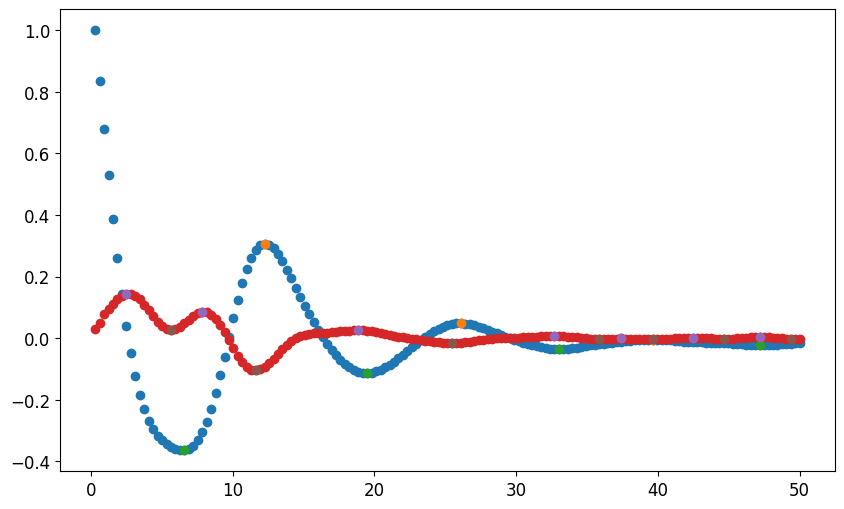

In [291]:
from scipy.signal import find_peaks

plt.scatter(z, Corr)
peaks, properties = find_peaks(Corr)
mins, properties = find_peaks(-Corr)

plt.scatter(z[peaks], Corr[peaks])
plt.scatter(z[mins], Corr[mins])


plt.scatter(z, idf)
peaks, properties = find_peaks(idf)
mins, properties = find_peaks(-idf)

plt.scatter(z[peaks], idf[peaks])
plt.scatter(z[mins], idf[mins])

In [131]:
def gamma1(q, I, r):
    """Корреляционная функция γ₁(r) без нормировки: ∫ I(q) q² cos(qr) dq"""
    return np.array([np.trapz(I * q**2 * np.cos(q * ri), q) for ri in r])

def Gamma(q, I, z):
    K = np.trapezoid(I[:, None] * np.cos(q[:, None] * z[None, :]), q, axis=0)
    return K

In [121]:
def power(x, k, b):
    return b * x ** k
from scipy.interpolate import CubicSpline
from scipy.interpolate import interp1d

def sub_const(ax, q, I, lim):
    ax.plot(q, I, color='black', alpha=0.5)
    ax.axvline(x = lim, linewidth=0.5, linestyle='--', color='red')
    mask = q < lim

    x, y = q[mask], (I[mask] - 0.85 * I[mask][-1])
    ax.plot(x,y, color='black', alpha=1)
    return x, y

def sub_power(ax, q, I, lim, A):
    mask = q < lim

    p, cov = curve_fit(power, q[mask], I[mask])

    ax.plot(q[mask],  A * power(q[mask], *p), linestyle='--', color='red')
    x, y = q, I - A * power(q, *p)
    ax.axvline(x = lim, linewidth=0.5, linestyle='--', color='red')
    
    return x, y 
    
def add_porod(ax, x, y, lim, A):
    x_porod = np.linspace(lim, 10, 1000)
    y_porod = x_porod ** -4
    y_porod /= y_porod[0]
    y_porod *= np.mean(y[-10:-1]) / A

    ax.plot(x_porod, y_porod,  alpha = 1, color='black')

    q_full = np.concatenate([x, x_porod])
    I_full = np.concatenate([y, y_porod])

    return q_full, I_full 

def Lorenz(x, y, p = 2):
    return x, y * x ** p

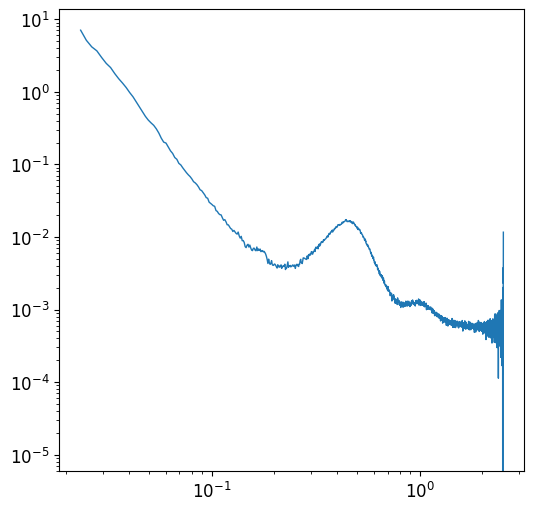

In [61]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00294_00_00001_av.dat"
df = pd.read_csv(path, skiprows=2, names=['q', 'I', 'err'], sep='\t')
q, I = np.array(df['q']), np.array(df['I'])
ax.plot(q, I, label='after quenching', linewidth=1)
ax.set_xscale('log')
ax.set_yscale('log')


L_p =  12.315043202071989
d =  8.919301749747085
Cr =  0.7242606951022652


(-1.1, 1.1)

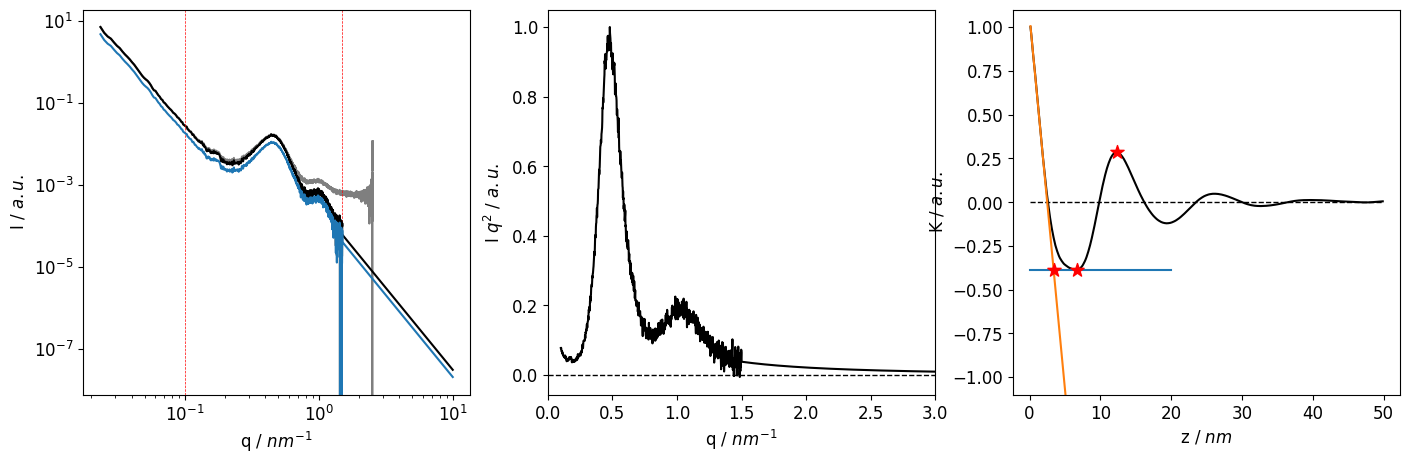

In [150]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(17,5))

size= 100
right = 1.5
left = 0.1
lorenz_power = 2

x, y = sub_const(ax1, q, I, right)
x, y = sub_power(ax1, x, y, left, 0.)
x_full, y_full = add_porod(ax1, x, y, right, 1)
ax1.plot(x_full, y_full / 1.5)

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('q / $nm^{-1}$')
ax1.set_ylabel('I / $a. u.$')

mask = (x_full > left) 
X, Y = Lorenz(x_full[mask], y_full[mask], p = lorenz_power)

ax2.plot(X, Y / max(Y), label='Lorenz', color='black')
ax2.set_xlim(0, 3)
lnsp = np.linspace(0, max(X))
ax2.plot(lnsp, lnsp * 0, color='black', linewidth=1, linestyle='--')
ax2.set_xlabel('q / $nm^{-1}$')
ax2.set_ylabel('I $q^2$ / $a. u.$')

z, K = corr_func(X, Y, res = 5, zmax=50)
K /= max(K)
ax3.plot(z, K, color='black')
ax3.plot(z, z * 0, color='black', linewidth=1, linestyle='--')
ax3.set_xlabel('z / $nm$')
ax3.set_ylabel('K / $a. u.$')

mask_max = (z > 7) & (z < 40)
i_max = np.argmax(K[mask_max])
z_max = z[mask_max][i_max]
K_max = K[mask_max][i_max]
ax3.scatter(z_max, K_max, zorder=10, color='red', marker='*', s=size)
print('L_p = ', z_max)

mask_min = (z > 0) & (z < 20)
i_min = np.argmin(K[mask_min])
z_min = z[mask_min][i_min]
K_min = K[mask_min][i_min]
ax3.scatter(z_min, K_min, zorder=10, color='red', marker='*', s=size)

ax3.plot(z[mask_min], K_min * np.ones(len(z[mask_min])))

mask_linear = z < 2
p, cov = curve_fit(linear, z[mask_linear], K[mask_linear])

ax3.plot(z[mask_min], linear(z[mask_min], *p))


z_d = (K_min - p[1]) / p[0]
ax3.scatter(z_d, linear(z_d, *p), zorder=10, color='red', marker='*', s=size)
print('d = ', z_max - z_d)
print('Cr = ', 1 - z_d / z_max)

ax3.set_ylim(-1.1, 1.1)

Text(0, 0.5, 'I (a.u.)')

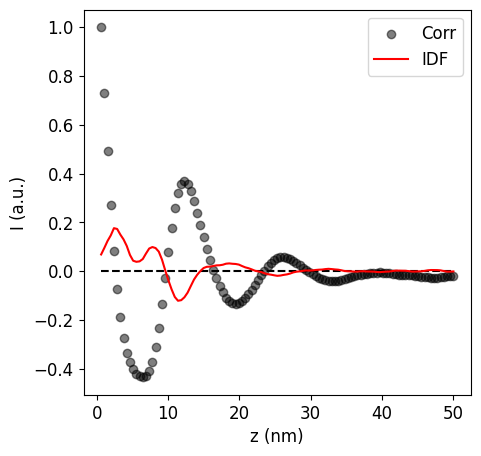

In [259]:
plt.figure(figsize=(5,5))

dz = 2 * pi / max(X)
z = np.linspace(dz, 50, int(70 / dz))
Corr = Gamma(X,Y,z) 
Corr /= Corr[0]
plt.scatter(z, Corr, color='black', alpha=0.5, label='Corr')


d1 = np.gradient(Corr, z)
d2 = np.gradient(d1, z)
IDF = np.gradient(np.gradient(Corr, z), z)
plt.plot(z, IDF, label='IDF', zorder=20, color='red')

plt.plot(z, np.zeros(len(z)), linestyle='--', color='black')

plt.legend()
plt.xlabel('z (nm)')
plt.ylabel('I (a.u.)')

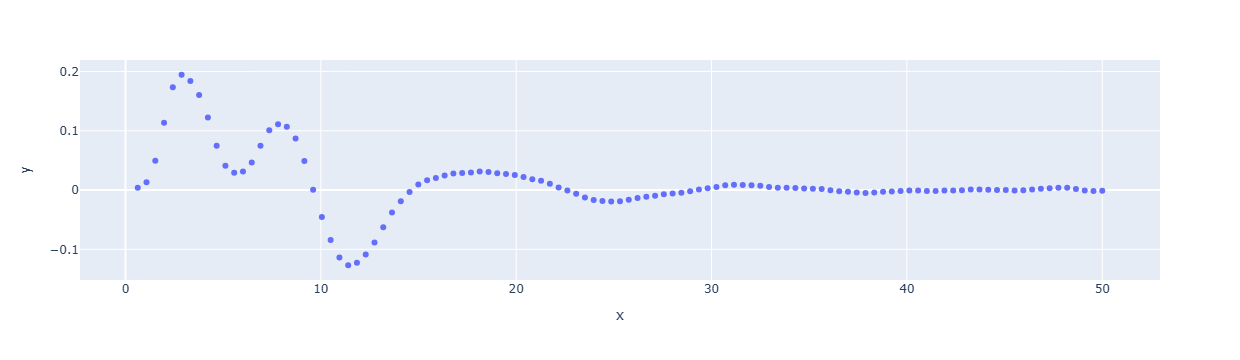

In [145]:
px.scatter(x = z, y = IDF)

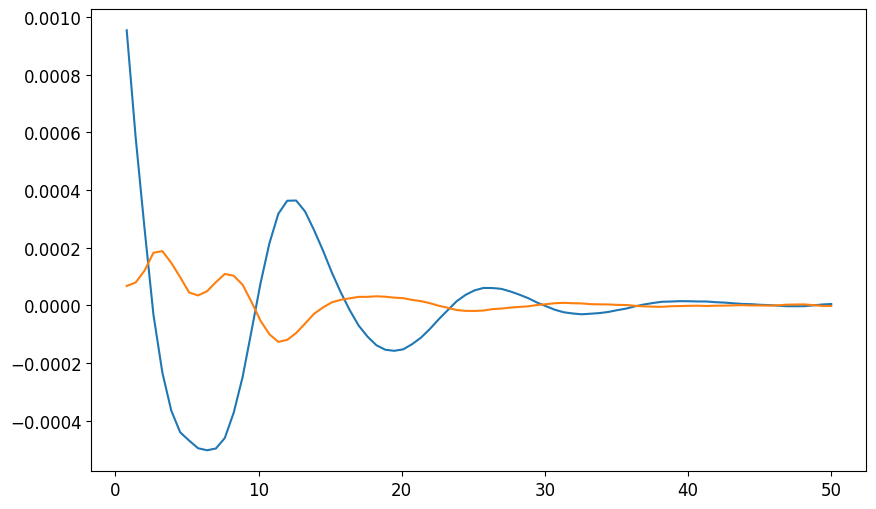

In [102]:
dz = 2 * np.pi / max(X) 

# Ваши данные
z = np.linspace(0.5 * dz, 50, 80)
Corr = Gamma(X,Y, z)

plt.plot(z, Corr)


# Вторая производная от сглаженной
d2 = np.gradient(np.gradient(Corr, z), z)

plt.plot(z, d2, label=f'sigma={sigma}')